# Integrated Experiment Runner — Recent Dataset, Final Project B Features (2-year walk-forward)

This notebook merges the **training-only EDA** (final Project B feature set) with the
**benchmarking experiment runner**, reorganised into one runnable workflow.

**What changed vs the originals**
1. Front EDA section added, run on the **training split only**, using the **final Project B feature set** (`final_feature_B.txt`). The same feature list (`FINAL_FEATURE_B`, constants dropped) is then used for **all** modelling.
2. Standard **train / validation / test** flow: fit on train, **tune the classification threshold on validation**, predict on **test**. Hyper-parameters are held at documented defaults (large grid search intentionally avoided).
3. Walk-forward **expanding** and **rolling** both start from a **2-year** minimum training window, rotating yearly (`rolling_2y`).
4. A dependence-robust **inference layer** is added (block-bootstrap / Newey-West CIs for the ranking metrics, and block-bootstrap CIs for the classification metrics), plus **paired model comparisons**.
5. Boosting model = **LightGBM only** (no XGBoost). **Dummy baselines** are always included (mean / most-frequent).
6. Targets covered: **`rl_long_current_pnl`** (primary, regression) + secondary **`rl_long_action_binary`** (binary), **`pi_hindsight_entry_original`** (binary, score ≥ 0.4), **`pi_hindsight_entry_long`** (continuous hindsight score).

**Before running:** put the JSONL data files and `final_feature_B.txt` in the notebook folder and set `NORMALISATION_STATUS` in Section 0. (The agreed plan recommends the raw `pre_normalisation_all` files; the default below keeps the value the source notebooks used — change the single constant to switch.)


## 0. Environment setup

Single install cell + single import/config cell (no duplicate installs or imports elsewhere).

In [1]:
# One-time installs (run once). Comment out if the environment already has these.
%pip install -q numpy pandas scikit-learn lightgbm scipy statsmodels matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---- imports (single source) ----
import os, json, math, re, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             explained_variance_score, accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             average_precision_score, brier_score_loss, matthews_corrcoef,
                             cohen_kappa_score, log_loss, confusion_matrix)
warnings.filterwarnings('ignore')

# ---- reproducibility / parallelism ----
RANDOM_STATE = 42
N_JOBS = -1

# ---- canonical column names (shared by EDA and the runner) ----
INDEX_COL = 'IndexReference'
DATE_COL = 'attr__timestamp'
TICKER_COL = 'attr__ticker'
SIC2_COL = 'attr__sic2'
YEAR_COL = 'year'
SPLIT_COL = 'split'
TRUE_COL = 'y_true'
PRED_COL = 'y_pred'
SCORE_COL = 'prediction_score'
SIGNAL_SCORE_COL = 'signal_score'
DIRECTION_COL = 'direction'
CONFIDENCE_COL = 'confidence'
RL_TRAINABLE_COL = 'label__rl.trainable'

# ---- dataset selection (single knob) ----
UNIVERSE = 'universe_100'
TIME_HORIZON = 'recent'
# NOTE: the agreed plan recommends the raw files 'pre_normalisation_all'.
# Change ONLY this constant to switch the whole notebook; file names follow
# f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}_{split}.jsonl".
NORMALISATION_STATUS = 'post_normalisation'

PROJECT_ROOT = Path.cwd()
DATASET_NAME = f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}"
# Final Project B feature inventory (used by both the EDA and modelling sections).
PROJECT_B_FEATURE_FILE = PROJECT_ROOT / 'final_feature_B.txt'

# ---- output folders ----
RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_DIR = PROJECT_ROOT / 'integrated_experiment_outputs_recent_final_feature_b'
TABLE_DIR = OUTPUT_DIR / 'tables'
PREDICTION_DIR = OUTPUT_DIR / 'predictions'
MODEL_DIR = OUTPUT_DIR / 'models'
FIGURE_DIR = OUTPUT_DIR / 'figures'
INVENTORY_DIR = OUTPUT_DIR / 'inventories'
for d in [OUTPUT_DIR, TABLE_DIR, PREDICTION_DIR, MODEL_DIR, FIGURE_DIR, INVENTORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ---- EDA display constants ----
MISSING_THRESHOLD = 0.50
CORR_THRESHOLD = 0.95
TOP_MISSING_FEATURES_TO_PLOT = 30
TOP_VARIABLE_FEATURES_TO_PLOT = 20
TOP_CORRELATION_FEATURES = 30
HISTOGRAM_BINS = 50
FIGURE_DPI = 180
SELECTED_TARGETS = None

print('Output directory:', OUTPUT_DIR.resolve())

Output directory: C:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\integrated_experiment_outputs_recent_final_feature_b


## 1. Dataset configuration and loading

Defines the train/validation/test file paths and the final Project B feature file, then loads all three splits into `frames` and the pooled `all_data`.

*Applicable to:* all targets and all downstream sections.

In [3]:
# This section defines where the train, validation, and test files are located. 
# When switching between universe, time horizon, or pre/post-normalisation versions, only need to change the value of UNIVERSE/ TIME_HORIZON/ NORMALISATION_STATUS
DATASET_CONFIG = {
    "dataset_name": f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}",
    "train_path": PROJECT_ROOT / f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}_train.jsonl",
    "valid_path": PROJECT_ROOT / f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}_validation.jsonl",
    "test_path":  PROJECT_ROOT / f"{UNIVERSE}_{TIME_HORIZON}_{NORMALISATION_STATUS}_test.jsonl",
    "project_b_feature_file": PROJECT_ROOT / "final_feature_B.txt",
    "universe": UNIVERSE,
    "time_horizon": TIME_HORIZON,
    "normalisation_setting": NORMALISATION_STATUS,
}
# Check whether all configured files exist
for key in ["train_path", "valid_path", "test_path", "project_b_feature_file"]:
    path = Path(DATASET_CONFIG[key])
    print(f"{key}: {path}")
    print("Exists:", path.exists())
    print("-" * 80)

train_path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\universe_100_recent_post_normalisation_train.jsonl
Exists: True
--------------------------------------------------------------------------------
valid_path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\universe_100_recent_post_normalisation_validation.jsonl
Exists: True
--------------------------------------------------------------------------------
test_path: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\universe_100_recent_post_normalisation_test.jsonl
Exists: True
--------------------------------------------------------------------------------
project_b_feature_file: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\final_feature_B.txt
Exists: True
--------------------------------------------------------------------------------


In [4]:
def load_flatten_jsonl(path):
    """
    Load and flatten an Adaptive Swarm model-ready JSONL file.

    Supported record structures:
    1. Official model-ready format:
       {"section": "data", "data": {"IndexReference": ..., "Attributes": {}, "Features": {}, "Labels": {}}}
    2. Already-flattened or earlier lower-case format:
       {"IndexReference": ..., "attributes": {}, "features": {}, "labels": {}}

    Output convention:
    - Attributes -> attr__*
    - Features   -> feature__*
    - Labels     -> label__*
    - IndexReference is preserved as the primary row join key for downstream prediction submission.
    """
    rows = []
    path = Path(path)

    def _open_text_file(p):
        if p.suffix.lower() == '.gz':
            import gzip
            return gzip.open(p, 'rt', encoding='utf-8')
        return p.open('r', encoding='utf-8')

    with _open_text_file(path) as f:
        for line in f:
            if not line.strip():
                continue

            raw_record = json.loads(line)

            # Skip header rows in official model-ready JSONL files.
            if raw_record.get('section') == 'header':
                continue

            # Official structure stores the useful row inside raw_record['data'].
            if raw_record.get('section') == 'data':
                record = raw_record.get('data', {}) or {}
            else:
                record = raw_record

            if not isinstance(record, dict):
                continue

            attrs = (
                record.get('Attributes')
                or record.get('attributes')
                or record.get('attrs')
                or {}
            )
            feats = record.get('Features') or record.get('features') or {}
            labs = record.get('Labels') or record.get('labels') or {}

            row = {INDEX_COL: record.get('IndexReference', raw_record.get('IndexReference'))}

            for k, v in attrs.items():
                row[k if str(k).startswith('attr__') else f'attr__{k}'] = v

            for k, v in feats.items():
                row[k if str(k).startswith('feature__') else f'feature__{k}'] = v

            for k, v in labs.items():
                row[k if str(k).startswith('label__') else f'label__{k}'] = v

            # Preserve simple scalar fields from the row for auditability.
            for k, v in record.items():
                if (
                    k not in ['Attributes', 'attributes', 'attrs', 'Features', 'features', 'Labels', 'labels']
                    and not isinstance(v, (dict, list))
                ):
                    row.setdefault(k, v)

            rows.append(row)

    df = pd.DataFrame(rows)
    print(f'Flattened JSONL shape: {df.shape}')
    return df


def load_jsonl_zip(path):
    """
    Load a .jsonl.zip file where the archive contains one JSONL file.
    This matches the project documentation's recommended model-ready data format.
    """
    import zipfile
    path = Path(path)
    rows = []

    with zipfile.ZipFile(path, 'r') as zf:
        jsonl_names = [name for name in zf.namelist() if name.lower().endswith('.jsonl')]
        if not jsonl_names:
            raise ValueError(f'No .jsonl file found inside zip archive: {path}')

        with zf.open(jsonl_names[0], 'r') as f:
            for raw_line in f:
                line = raw_line.decode('utf-8')
                if not line.strip():
                    continue
                raw_record = json.loads(line)
                if raw_record.get('section') == 'header':
                    continue
                record = raw_record.get('data', {}) if raw_record.get('section') == 'data' else raw_record
                if not isinstance(record, dict):
                    continue

                attrs = record.get('Attributes') or record.get('attributes') or record.get('attrs') or {}
                feats = record.get('Features') or record.get('features') or {}
                labs = record.get('Labels') or record.get('labels') or {}

                row = {INDEX_COL: record.get('IndexReference', raw_record.get('IndexReference'))}
                for k, v in attrs.items():
                    row[k if str(k).startswith('attr__') else f'attr__{k}'] = v
                for k, v in feats.items():
                    row[k if str(k).startswith('feature__') else f'feature__{k}'] = v
                for k, v in labs.items():
                    row[k if str(k).startswith('label__') else f'label__{k}'] = v
                for k, v in record.items():
                    if (
                        k not in ['Attributes', 'attributes', 'attrs', 'Features', 'features', 'Labels', 'labels']
                        and not isinstance(v, (dict, list))
                    ):
                        row.setdefault(k, v)
                rows.append(row)

    df = pd.DataFrame(rows)
    print(f'Flattened zipped JSONL shape: {df.shape}')
    return df


def load_table(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')

    name = path.name.lower()
    suffix = path.suffix.lower()

    if suffix == '.parquet':
        return pd.read_parquet(path)
    if suffix == '.csv':
        return pd.read_csv(path)
    if suffix == '.jsonl' or name.endswith('.jsonl.gz'):
        return load_flatten_jsonl(path)
    if name.endswith('.jsonl.zip'):
        return load_jsonl_zip(path)
    if suffix == '.json':
        try:
            return pd.read_json(path, lines=True)
        except ValueError:
            return pd.read_json(path)

    raise ValueError(f'Unsupported file format: {path}')


def standardise_frame(df, split_name):
    df = df.copy()
    df[SPLIT_COL] = split_name

    if INDEX_COL not in df.columns:
        # Fallback only for older flattened datasets without IndexReference.
        # Official simulator submission requires the source IndexReference, so this should be audited.
        df[INDEX_COL] = np.arange(len(df))
        print(f'Warning: {INDEX_COL} missing in {split_name}; generated sequential fallback index.')

    if DATE_COL in df.columns:
        df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
        df[YEAR_COL] = df[DATE_COL].dt.year

    for col in [TICKER_COL, SIC2_COL]:
        if col not in df.columns:
            df[col] = np.nan

    return df


def load_dataset_from_config(config):
    frames = {}
    for split_name in ['train', 'valid', 'test']:
        df = load_table(config[f'{split_name}_path'])
        frames[split_name] = standardise_frame(df, split_name)
        print(f'{split_name}: {frames[split_name].shape}')
    all_data = pd.concat(frames.values(), ignore_index=True, sort=False)
    return frames, all_data

frames, all_data = load_dataset_from_config(DATASET_CONFIG)

Flattened JSONL shape: (98419, 747)
train: (98419, 749)
Flattened JSONL shape: (24469, 747)
valid: (24469, 749)
Flattened JSONL shape: (32142, 747)
test: (32142, 749)


### Export manager

Single table registry (`register_table` / `EXPORTED_TABLES`) used by every section; one Excel workbook is written at the end.

In [5]:
if 'EXPORTED_TABLES' not in globals():
    EXPORTED_TABLES = {}


def safe_table_name(name, max_len=120):
    name = re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name))
    name = re.sub(r'_+', '_', name).strip('_')
    return name[:max_len] or 'table'


def safe_sheet_name(name):
    name = re.sub(r'[\[\]\:\*\?\/\\]', '_', str(name))[:31]
    return name or 'Sheet'


def safe_file_name(name, max_len=120):
    name = str(name)
    for ch in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        name = name.replace(ch, '_')
    return name[:max_len] or 'file'


def make_excel_safe(df):
    """
    Convert DataFrame values into Excel-safe formats.
    The main fix is removing timezone information from datetime columns before Excel export.
    """
    df = df.copy()

    for col in df.columns:
        if pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_convert(None)
        elif df[col].dtype == 'object':
            df[col] = df[col].apply(
                lambda x: x.tz_convert(None)
                if isinstance(x, pd.Timestamp) and x.tzinfo is not None
                else x
            )

    return df


def register_table(name, df, export_immediately=False):
    if df is None:
        return None
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    key = safe_table_name(name)
    EXPORTED_TABLES[key] = df.copy()

    if export_immediately:
        TABLE_DIR.mkdir(parents=True, exist_ok=True)
        path = TABLE_DIR / f'{key}.xlsx'
        make_excel_safe(df).to_excel(path, index=False)
        print('Exported:', path)

    return df


def export_registered_tables(workbook_name=None, export_individual_files=True, max_sheet_rows=1_000_000):
    if workbook_name is None:
        workbook_name = f'integrated_experiment_tables_{RUN_TIMESTAMP}.xlsx'

    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    workbook_path = TABLE_DIR / workbook_name

    used = set()
    n_written = 0
    skipped_rows = []

    with pd.ExcelWriter(workbook_path, engine='openpyxl') as writer:
        for name, df in EXPORTED_TABLES.items():
            if df is None:
                skipped_rows.append({'table_name': name, 'reason': 'df_is_none'})
                continue
            if not isinstance(df, pd.DataFrame):
                skipped_rows.append({'table_name': name, 'reason': f'not_dataframe_{type(df)}'})
                continue
            if len(df) == 0:
                skipped_rows.append({'table_name': name, 'reason': 'empty_dataframe'})
                continue

            sheet = safe_sheet_name(name)
            base = sheet
            i = 1
            while sheet in used:
                suffix = f'_{i}'
                sheet = safe_sheet_name(base[:31 - len(suffix)] + suffix)
                i += 1
            used.add(sheet)

            excel_df = make_excel_safe(df)
            excel_df.head(max_sheet_rows).to_excel(writer, sheet_name=sheet, index=False)
            n_written += 1

        # Excel workbooks must contain at least one visible sheet.
        if n_written == 0:
            readme = pd.DataFrame([
                {
                    'message': 'No non-empty registered tables were available for export.',
                    'possible_reason_1': 'EXPORTED_TABLES is empty.',
                    'possible_reason_2': 'The workflow cells that call register_table() have not been run.',
                    'possible_reason_3': 'All registered tables were empty.',
                    'next_step': 'Run EDA/model/diagnostic cells, then export again.',
                }
            ])
            readme.to_excel(writer, sheet_name='README', index=False)

    if export_individual_files:
        for name, df in EXPORTED_TABLES.items():
            if df is None or not isinstance(df, pd.DataFrame) or len(df) == 0:
                continue
            excel_df = make_excel_safe(df)
            excel_df.head(max_sheet_rows).to_excel(TABLE_DIR / f'{safe_file_name(name)}.xlsx', index=False)

    print('Integrated workbook exported to:', workbook_path.resolve())
    print('Number of registered tables:', len(EXPORTED_TABLES))
    print('Number of non-empty tables written:', n_written)

    if skipped_rows:
        display(pd.DataFrame(skipped_rows))

    return workbook_path

In [6]:
# EDA-compatibility shims: route the EDA cells' helpers to the single registry above.
def export_table(name, df, display_table=True):
    """EDA helper -> stores in the shared EXPORTED_TABLES registry."""
    register_table(name, df)
    if display_table:
        try:
            display(df)
        except Exception:
            pass
    return df

def save_current_figure(name, close=False):
    """Save the current matplotlib figure into FIGURE_DIR."""
    path = FIGURE_DIR / f"{name}.png"
    plt.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if close:
        plt.close()
    return path

## 2. Label construction and target registry

Builds the `target__*` columns and the `TARGET_CONFIGS` registry (task type per target).

*Applicable labels:* perfect-hindsight (`pi_hindsight_entry_*`), RL long action/quality/reward, and `rl_long_current_pnl`.

In [7]:
def first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def make_pi_hindsight_entry_long_6bins(series):
    s = pd.to_numeric(series, errors='coerce')
    out = pd.Series(np.nan, index=s.index)
    out[s == 0] = 0
    out[(s > 0) & (s < 0.1)] = 1
    out[(s >= 0.1) & (s < 0.2)] = 2
    out[(s >= 0.2) & (s < 0.3)] = 3
    out[(s >= 0.3) & (s < 0.4)] = 4
    out[s >= 0.4] = 5
    return out.astype('Int64')


def add_derived_targets(df):
    df = df.copy()

    pi_col = first_existing_column(df, ['label__pi_hindsight_entry_long', 'label__pi_long_entry', 'pi_hindsight_entry_long'])
    if pi_col is not None:
        df['target__pi_hindsight_entry_long'] = pd.to_numeric(df[pi_col], errors='coerce')
        df['target__pi_hindsight_entry_positive'] = (df['target__pi_hindsight_entry_long'] > 0).astype('Int64')
        df['target__pi_hindsight_entry_original'] = (df['target__pi_hindsight_entry_long'] >= 0.4).astype('Int64')
        df['target__pi_hindsight_entry_6bins'] = make_pi_hindsight_entry_long_6bins(df['target__pi_hindsight_entry_long'])

    col = first_existing_column(df, ['label__rl.expert_action', 'label__rl_expert_action'])
    if col is not None:
        df['target__rl_expert_action'] = df[col]

    col = first_existing_column(df, ['label__rl.long_is_best', 'label__rl_long_is_best'])
    if col is not None:
        df['target__rl_long_is_best'] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    col = first_existing_column(df, ['label__rl.long.action_quality', 'label__rl_long_action_quality'])
    if col is not None:
        df['target__rl_long_action_quality'] = pd.to_numeric(df[col], errors='coerce')
    col = first_existing_column(df, ['label__rl.long.action_label'])
    if col is not None:
        df['target__rl_long_action_binary'] = pd.to_numeric(df[col], errors='coerce')        

    col = first_existing_column(df, ['label__rl.reward.long', 'label__rl_reward_long', 'label__rl.long.reward'])
    if col is not None:
        df['target__rl_long_reward'] = pd.to_numeric(df[col], errors='coerce')

    col = first_existing_column(df, ['label__rl.long.current_pnl', 'label__rl_long_current_pnl', 'label__rl.long_current_pnl', 'label__current_pnl'])
    if col is not None:
        df['target__rl_long_current_pnl'] = pd.to_numeric(df[col], errors='coerce')

    reward_long = first_existing_column(df, ['label__rl.reward.long', 'target__rl_long_reward'])
    reward_short = first_existing_column(df, ['label__rl.reward.short', 'label__rl_reward_short'])
    reward_no_trade = first_existing_column(df, ['label__rl.reward.no_trade', 'label__rl_reward_no_trade', 'label__rl.reward.hold'])

    if reward_long and reward_short and reward_no_trade:
        r_long = pd.to_numeric(df[reward_long], errors='coerce')
        r_short = pd.to_numeric(df[reward_short], errors='coerce')
        r_no_trade = pd.to_numeric(df[reward_no_trade], errors='coerce')

        if 'target__rl_long_is_best' not in df.columns:
            df['target__rl_long_is_best'] = ((r_long > r_short) & (r_long > r_no_trade)).astype('Int64')

        best_non_long_reward = pd.concat([r_short, r_no_trade], axis=1).max(axis=1)
        df['target__rl_long_reward_margin'] = r_long - best_non_long_reward
        df['target__rl_long_high_confidence'] = (df['target__rl_long_reward_margin'] >= 0.05).astype('Int64')

    return df


TARGET_CONFIGS = {
    'pi_hindsight_entry_long': {'column': 'target__pi_hindsight_entry_long', 'task': 'regression', 'direction': 'higher_is_better', 'description': 'Continuous perfect-hindsight long-entry score.'},
    'pi_hindsight_entry_positive': {'column': 'target__pi_hindsight_entry_positive', 'task': 'binary', 'positive_label': 1, 'direction': 'higher_is_better', 'description': 'Binary target: pi score > 0.'},
    'pi_hindsight_entry_original': {'column': 'target__pi_hindsight_entry_original', 'task': 'binary', 'positive_label': 1, 'direction': 'higher_is_better', 'description': 'Binary target: pi score >= 0.4.'},
    'pi_hindsight_entry_6bins': {'column': 'target__pi_hindsight_entry_6bins', 'task': 'multiclass', 'direction': 'higher_is_better', 'description': 'Six-bin ordinal perfect-hindsight target.'},
    'rl_expert_action': {'column': 'target__rl_expert_action', 'task': 'multiclass', 'direction': 'action', 'description': 'RL evaluator expert action classification.'},
    'rl_long_action_binary': {'column': 'target__rl_long_action_binary', 'task': 'binary', 'positive_label': 1, 'description': 'RL evaluator long action classification.'},
    'rl_long_is_best': {'column': 'target__rl_long_is_best', 'task': 'binary', 'positive_label': 1, 'direction': 'higher_is_better', 'description': 'Binary long-side target: long is best action.'},
    'rl_long_high_confidence': {'column': 'target__rl_long_high_confidence', 'task': 'binary', 'positive_label': 1, 'direction': 'higher_is_better', 'description': 'Binary target: long reward exceeds the best non-long alternative by a margin.'},
    'rl_long_action_quality': {'column': 'target__rl_long_action_quality', 'task': 'regression', 'direction': 'higher_is_better', 'description': 'Continuous long action quality.'},
    'rl_long_reward': {'column': 'target__rl_long_reward', 'task': 'regression', 'direction': 'higher_is_better', 'description': 'Continuous long reward.'},
    'rl_long_reward_margin': {'column': 'target__rl_long_reward_margin', 'task': 'regression', 'direction': 'higher_is_better', 'description': 'Long reward minus the best non-long reward.'},
    'rl_long_current_pnl': {'column': 'target__rl_long_current_pnl', 'task': 'regression', 'direction': 'higher_is_better', 'description': 'Continuous long current PnL.'},
}


def apply_target_construction(frames):
    updated = {split: add_derived_targets(df) for split, df in frames.items()}
    all_data = pd.concat(updated.values(), ignore_index=True, sort=False)
    return updated, all_data

frames, all_data = apply_target_construction(frames)

In [8]:
def available_target_configs(df, target_configs=TARGET_CONFIGS):
    return {name: cfg for name, cfg in target_configs.items() if cfg['column'] in df.columns}


def label_overall_summary(all_data, target_configs=TARGET_CONFIGS):
    rows = []
    for target_name, cfg in available_target_configs(all_data, target_configs).items():
        col = cfg['column']
        y = all_data[col]
        row = {'target_name': target_name, 'column': col, 'task': cfg['task'], 'description': cfg.get('description', ''), 'n_rows': len(y), 'n_non_missing': int(y.notna().sum()), 'missing_rate': y.isna().mean(), 'n_unique': y.nunique(dropna=True)}
        if cfg['task'] == 'regression':
            yy = pd.to_numeric(y, errors='coerce')
            row.update({'mean': yy.mean(), 'std': yy.std(), 'min': yy.min(), 'p01': yy.quantile(0.01), 'p05': yy.quantile(0.05), 'median': yy.median(), 'p95': yy.quantile(0.95), 'p99': yy.quantile(0.99), 'max': yy.max(), 'zero_rate': (yy == 0).mean(), 'positive_rate': (yy > 0).mean(), 'negative_rate': (yy < 0).mean()})
        else:
            if cfg['task'] == 'binary':
                row['positive_rate'] = (y == cfg.get('positive_label', 1)).mean()
            counts = y.value_counts(dropna=False, normalize=True)
            for k, v in counts.head(20).items():
                row[f'class_rate_{k}'] = v
        rows.append(row)
    return register_table('label_eda_overall_summary', pd.DataFrame(rows))


def label_distribution_by_split(all_data, target_configs=TARGET_CONFIGS):
    rows = []
    for target_name, cfg in available_target_configs(all_data, target_configs).items():
        col = cfg['column']
        for split_name, g in all_data.groupby(SPLIT_COL, dropna=False):
            y = g[col]
            base = {'target_name': target_name, 'split': split_name, 'task': cfg['task'], 'n_rows': len(g), 'n_non_missing': int(y.notna().sum()), 'missing_rate': y.isna().mean()}
            if cfg['task'] == 'regression':
                yy = pd.to_numeric(y, errors='coerce')
                base.update({'mean': yy.mean(), 'std': yy.std(), 'median': yy.median(), 'zero_rate': (yy == 0).mean(), 'positive_rate': (yy > 0).mean(), 'negative_rate': (yy < 0).mean()})
                rows.append(base)
            else:
                for klass, rate in y.value_counts(dropna=False, normalize=True).items():
                    row = base.copy(); row['class'] = klass; row['class_rate'] = rate; row['class_count'] = int((y == klass).sum()) if pd.notna(klass) else int(y.isna().sum()); rows.append(row)
    return register_table('label_eda_by_split', pd.DataFrame(rows))


def label_distribution_by_group(all_data, group_col, target_configs=TARGET_CONFIGS, min_rows=30):
    if group_col not in all_data.columns:
        return register_table(f'label_eda_by_{group_col}', pd.DataFrame())
    rows = []
    for target_name, cfg in available_target_configs(all_data, target_configs).items():
        col = cfg['column']
        for group_value, g in all_data.groupby(group_col, dropna=False):
            if len(g) < min_rows:
                continue
            y = g[col]
            row = {'target_name': target_name, 'group_col': group_col, 'group_value': group_value, 'task': cfg['task'], 'n_rows': len(g), 'n_non_missing': int(y.notna().sum()), 'missing_rate': y.isna().mean()}
            if cfg['task'] == 'regression':
                yy = pd.to_numeric(y, errors='coerce')
                row.update({'mean': yy.mean(), 'std': yy.std(), 'median': yy.median(), 'zero_rate': (yy == 0).mean(), 'positive_rate': (yy > 0).mean(), 'negative_rate': (yy < 0).mean()})
            else:
                if cfg['task'] == 'binary':
                    row['positive_rate'] = (y == cfg.get('positive_label', 1)).mean()
                row['mode'] = y.mode(dropna=True).iloc[0] if y.notna().any() else np.nan
                row['mode_rate'] = y.value_counts(normalize=True, dropna=True).iloc[0] if y.notna().any() else np.nan
            rows.append(row)
    return register_table(f'label_eda_by_{safe_table_name(group_col)}', pd.DataFrame(rows))


def run_all_label_eda(all_data):
    return {
        'overall': label_overall_summary(all_data),
        'by_split': label_distribution_by_split(all_data),
        'by_year': label_distribution_by_group(all_data, YEAR_COL),
        'by_ticker': label_distribution_by_group(all_data, TICKER_COL),
        'by_sic2': label_distribution_by_group(all_data, SIC2_COL),
    }

label_eda_tables = run_all_label_eda(all_data)


print("all_data shape:", all_data.shape)
print("Number of columns:", len(all_data.columns))

print("\nAvailable target configs:")
available = available_target_configs(all_data)
print(available.keys())

print("\nTarget columns expected:")
for name, cfg in TARGET_CONFIGS.items():
    print(name, "->", cfg["column"], "exists:", cfg["column"] in all_data.columns)

all_data shape: (155030, 761)
Number of columns: 761

Available target configs:
dict_keys(['pi_hindsight_entry_long', 'pi_hindsight_entry_positive', 'pi_hindsight_entry_original', 'pi_hindsight_entry_6bins', 'rl_expert_action', 'rl_long_action_binary', 'rl_long_is_best', 'rl_long_high_confidence', 'rl_long_action_quality', 'rl_long_reward', 'rl_long_reward_margin', 'rl_long_current_pnl'])

Target columns expected:
pi_hindsight_entry_long -> target__pi_hindsight_entry_long exists: True
pi_hindsight_entry_positive -> target__pi_hindsight_entry_positive exists: True
pi_hindsight_entry_original -> target__pi_hindsight_entry_original exists: True
pi_hindsight_entry_6bins -> target__pi_hindsight_entry_6bins exists: True
rl_expert_action -> target__rl_expert_action exists: True
rl_long_action_binary -> target__rl_long_action_binary exists: True
rl_long_is_best -> target__rl_long_is_best exists: True
rl_long_high_confidence -> target__rl_long_high_confidence exists: True
rl_long_action_quality

## 3. Training-only EDA (final Project B feature set)

Descriptive EDA is computed on the **training split only** so validation/test outcomes never influence descriptive judgements. All feature diagnostics use the **final Project B** inventory (`final_feature_B.txt`); the sanity-checked list becomes `FINAL_FEATURE_B` and is reused for every model.

*Applicable to:* dataset coverage, feature quality, correlations, distributions, and target EDA for all targets.

In [9]:
# Bridge: expose the variables the EDA cells expect, from the loaded runner data.
df_train = frames['train'].copy()                                   # training split only
target_cols = sorted([c for c in df_train.columns if c.startswith('target__')])
print('Training rows:', len(df_train), '| target columns:', len(target_cols))

Training rows: 98419 | target columns: 12


## 4. Canonical column inventories

In [10]:
attribute_cols = sorted([c for c in df_train.columns if c.startswith("attr__")])
feature_cols = sorted([c for c in df_train.columns if c.startswith("feature__")])
label_cols = sorted([c for c in df_train.columns if c.startswith("label__")])

inventory_summary = pd.DataFrame({
    "column_family": ["attributes", "features", "labels", "other"],
    "n_columns": [
        len(attribute_cols),
        len(feature_cols),
        len(label_cols),
        len(df_train.columns) - len(attribute_cols) - len(feature_cols) - len(label_cols)
    ]
})

export_table("column_family_summary", inventory_summary)

for filename, columns in {
    "attribute_columns.txt": attribute_cols,
    "feature_columns.txt": feature_cols,
    "label_columns.txt": label_cols
}.items():
    path = INVENTORY_DIR / filename
    path.write_text("\n".join(columns), encoding="utf-8")
    print("Saved inventory:", path)

print("Attributes:", len(attribute_cols))
print("Features:", len(feature_cols))
print("Labels:", len(label_cols))

,column_family,n_columns
0,attributes,46
1,features,621
2,labels,78
3,other,16


Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\integrated_experiment_outputs_recent_final_feature_b\inventories\attribute_columns.txt
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\integrated_experiment_outputs_recent_final_feature_b\inventories\feature_columns.txt
Saved inventory: c:\Users\user\Downloads\universe_100_recent_post_normalisation_experiment2\integrated_experiment_outputs_recent_final_feature_b\inventories\label_columns.txt
Attributes: 46
Features: 621
Labels: 78


## 6. Dataset coverage and structural checks

In [11]:
dataset_overview = pd.DataFrame([{
    "dataset_name": DATASET_NAME,
    "n_rows": len(df_train),
    "n_columns": df_train.shape[1],
    "n_attributes": len(attribute_cols),
    "n_features": len(feature_cols),
    "n_raw_labels": len(label_cols),
    "n_derived_targets": len(target_cols),
    "n_tickers": df_train[TICKER_COL].nunique(dropna=True),
    "start_date": df_train[DATE_COL].min(),
    "end_date": df_train[DATE_COL].max(),
    "duplicate_index_references": df_train[INDEX_COL].duplicated().sum(),
    "missing_index_reference_rate": df_train[INDEX_COL].isna().mean(),
    "missing_timestamp_rate": df_train[DATE_COL].isna().mean(),
    "missing_ticker_rate": df_train[TICKER_COL].isna().mean()
}])

export_table("dataset_overview", dataset_overview)

ticker_coverage = (
    df_train.groupby(TICKER_COL, dropna=False)
    .agg(
        n_rows=(INDEX_COL, "size"),
        start_date=(DATE_COL, "min"),
        end_date=(DATE_COL, "max"),
        n_years=(YEAR_COL, "nunique")
    )
    .reset_index()
    .sort_values("n_rows", ascending=False)
)

export_table("ticker_coverage", ticker_coverage)

year_coverage = (
    df_train.groupby(YEAR_COL, dropna=False)
    .agg(
        n_rows=(INDEX_COL, "size"),
        n_tickers=(TICKER_COL, "nunique")
    )
    .reset_index()
    .sort_values(YEAR_COL)
)

export_table("year_coverage", year_coverage)

ticker_year_coverage = (
    df_train.groupby([TICKER_COL, YEAR_COL], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

export_table("ticker_year_coverage", ticker_year_coverage)

,dataset_name,n_rows,n_columns,n_attributes,n_features,n_raw_labels,n_derived_targets,n_tickers,start_date,end_date,duplicate_index_references,missing_index_reference_rate,missing_timestamp_rate,missing_ticker_rate
0,universe_100_recent_post_normalisation,98419,761,46,621,78,12,98,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,0,0.0,0.0,0.0


,attr__ticker,n_rows,start_date,end_date,n_years
0,AAPL,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
1,ABBV,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
2,ABT,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
3,ACN,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
4,ADBE,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
...,...,...,...,...,...
94,VZ,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
97,XOM,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
95,WFC,1006,2020-01-02 00:00:00+00:00,2023-12-29 00:00:00+00:00,4
92,UNP,981,2020-01-02 00:00:00+00:00,2023-11-22 00:00:00+00:00,4


,year,n_rows,n_tickers
0,2020,24650,98
1,2021,24696,98
2,2022,24598,98
3,2023,24475,98


,attr__ticker,year,n_rows
0,AAPL,2020,253
1,AAPL,2021,252
2,AAPL,2022,251
3,AAPL,2023,250
4,ABBV,2020,253
...,...,...,...
387,WMT,2023,250
388,XOM,2020,253
389,XOM,2021,252
390,XOM,2022,251


,attr__ticker,year,n_rows
0,AAPL,2020,253
1,AAPL,2021,252
2,AAPL,2022,251
3,AAPL,2023,250
4,ABBV,2020,253
...,...,...,...
387,WMT,2023,250
388,XOM,2020,253
389,XOM,2021,252
390,XOM,2022,251


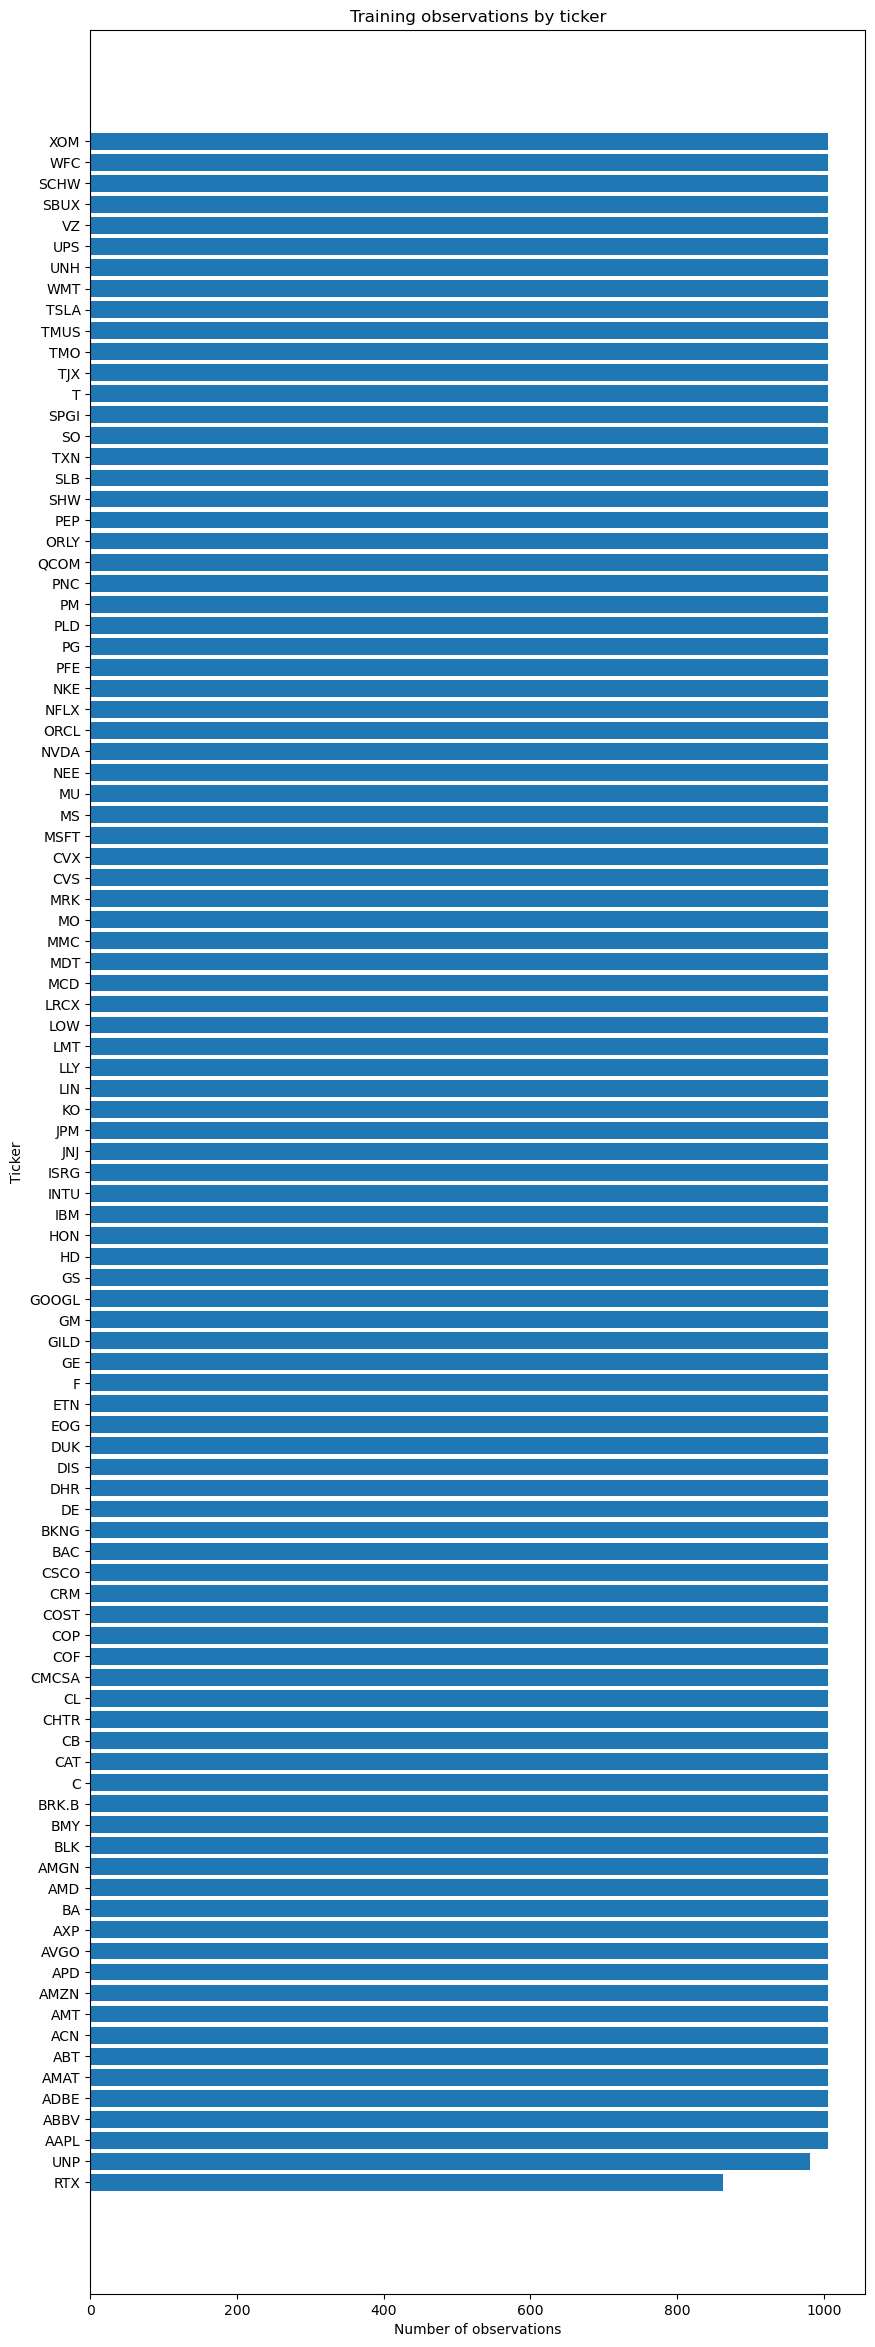

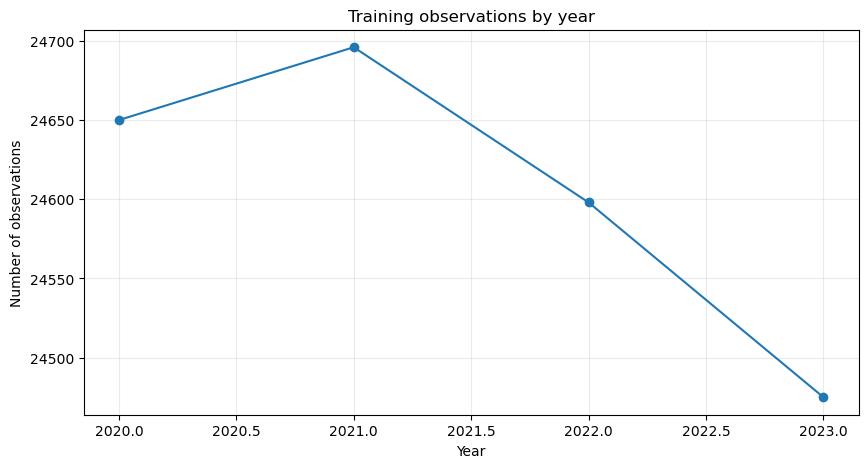

In [12]:
# Observations by ticker
plot_data = ticker_coverage.dropna(subset=[TICKER_COL]).sort_values("n_rows")

plt.figure(figsize=(10, max(5, 0.3 * len(plot_data))))
plt.barh(plot_data[TICKER_COL].astype(str), plot_data["n_rows"])
plt.title("Training observations by ticker")
plt.xlabel("Number of observations")
plt.ylabel("Ticker")
save_current_figure("training_observations_by_ticker")
plt.show()

# Observations by year
year_plot = year_coverage.dropna(subset=[YEAR_COL])

plt.figure(figsize=(10, 5))
plt.plot(year_plot[YEAR_COL], year_plot["n_rows"], marker="o")
plt.title("Training observations by year")
plt.xlabel("Year")
plt.ylabel("Number of observations")
plt.grid(alpha=0.25)
save_current_figure("training_observations_by_year")
plt.show()

## 7. Final Project B feature-set sanity checks

The Project B feature list is treated as the predefined modelling input. The following checks assess availability, missingness, degeneracy, invalid values, distribution shape, temporal/ticker coverage and residual correlation. They are quality-assurance diagnostics only and do not constitute a new feature-selection stage.


In [13]:
def normalise_feature_name(feature):
    """Match the unprefixed Project B inventory to flattened dataset columns."""
    feature = str(feature).strip()
    return feature if feature.startswith("feature__") else f"feature__{feature}"


if not PROJECT_B_FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"Final Project B feature list was not found: {PROJECT_B_FEATURE_FILE}"
    )

raw_final_feature_b = [
    line.strip()
    for line in PROJECT_B_FEATURE_FILE.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

final_feature_b_requested = [
    normalise_feature_name(feature)
    for feature in raw_final_feature_b
]

# Preserve the file order while removing accidental duplicates.
final_feature_b_requested = list(dict.fromkeys(final_feature_b_requested))

final_feature_b_available = [
    feature for feature in final_feature_b_requested
    if feature in df_train.columns
]

final_feature_b_missing = [
    feature for feature in final_feature_b_requested
    if feature not in df_train.columns
]

print("Features requested by final_feature_B:", len(final_feature_b_requested))
print("Available in training data:", len(final_feature_b_available))
print("Missing from training data:", len(final_feature_b_missing))

if final_feature_b_missing:
    display(pd.DataFrame({"missing_feature": final_feature_b_missing}))


def numeric_column_summary(data, columns):
    rows = []

    for column in columns:
        raw = data[column]
        values = pd.to_numeric(raw, errors="coerce")
        finite_mask = np.isfinite(values)

        rows.append({
            "column": column,
            "dtype": str(raw.dtype),
            "n_rows": len(raw),
            "count_numeric": int(values.notna().sum()),
            "missing_count": int(values.isna().sum()),
            "missing_rate": float(values.isna().mean()),
            "non_finite_count": int((values.notna() & ~finite_mask).sum()),
            "zero_count": int((values == 0).sum()),
            "zero_rate": float((values == 0).mean()),
            "n_unique": int(values.nunique(dropna=True)),
            "mean": values[finite_mask].mean(),
            "std": values[finite_mask].std(),
            "skewness": values[finite_mask].skew(),
            "min": values[finite_mask].min(),
            "p01": values[finite_mask].quantile(0.01),
            "p05": values[finite_mask].quantile(0.05),
            "p25": values[finite_mask].quantile(0.25),
            "median": values[finite_mask].quantile(0.50),
            "p75": values[finite_mask].quantile(0.75),
            "p95": values[finite_mask].quantile(0.95),
            "p99": values[finite_mask].quantile(0.99),
            "max": values[finite_mask].max()
        })

    return pd.DataFrame(rows)


final_feature_b_summary = numeric_column_summary(
    df_train,
    final_feature_b_available
)

final_feature_b_summary["is_constant"] = (
    final_feature_b_summary["n_unique"].fillna(0) <= 1
)

final_feature_b_summary["is_near_constant_99pct_zero"] = (
    final_feature_b_summary["zero_rate"].fillna(0) >= 0.99
)

final_feature_b_summary["high_missingness"] = (
    final_feature_b_summary["missing_rate"] > MISSING_THRESHOLD
)

final_feature_b_summary["extreme_skew_abs_gt_10"] = (
    final_feature_b_summary["skewness"].abs() > 10
)

final_feature_b_summary["passes_basic_sanity_check"] = (
    ~final_feature_b_summary["is_constant"]
    & ~final_feature_b_summary["high_missingness"]
    & (final_feature_b_summary["non_finite_count"] == 0)
)

export_table(
    "final_feature_b_summary",
    final_feature_b_summary,
    display_table=False
)

feature_sanity_overview = pd.DataFrame([{
    "requested_features": len(final_feature_b_requested),
    "available_features": len(final_feature_b_available),
    "missing_features": len(final_feature_b_missing),
    "constant_features": int(final_feature_b_summary["is_constant"].sum()),
    "near_constant_99pct_zero": int(
        final_feature_b_summary["is_near_constant_99pct_zero"].sum()
    ),
    "features_above_missingness_threshold": int(
        final_feature_b_summary["high_missingness"].sum()
    ),
    "features_with_non_finite_values": int(
        (final_feature_b_summary["non_finite_count"] > 0).sum()
    ),
    "features_with_extreme_skewness": int(
        final_feature_b_summary["extreme_skew_abs_gt_10"].sum()
    ),
    "features_passing_basic_sanity_check": int(
        final_feature_b_summary["passes_basic_sanity_check"].sum()
    )
}])

export_table("final_feature_b_sanity_overview", feature_sanity_overview)

# The final Project B set remains the canonical feature set.
# Features that fail a check are reported for review rather than silently removed.
final_feature_b_features = final_feature_b_available.copy()

pd.Series(final_feature_b_requested).to_csv(
    INVENTORY_DIR / "final_feature_b_requested.txt",
    index=False,
    header=False
)
pd.Series(final_feature_b_available).to_csv(
    INVENTORY_DIR / "final_feature_b_available.txt",
    index=False,
    header=False
)
pd.Series(final_feature_b_missing).to_csv(
    INVENTORY_DIR / "final_feature_b_missing.txt",
    index=False,
    header=False
)

display(feature_sanity_overview)

Features requested by final_feature_B: 270
Available in training data: 270
Missing from training data: 0


,requested_features,available_features,missing_features,constant_features,near_constant_99pct_zero,features_above_missingness_threshold,features_with_non_finite_values,features_with_extreme_skewness,features_passing_basic_sanity_check
0,270,270,0,2,11,0,0,41,268


,requested_features,available_features,missing_features,constant_features,near_constant_99pct_zero,features_above_missingness_threshold,features_with_non_finite_values,features_with_extreme_skewness,features_passing_basic_sanity_check
0,270,270,0,2,11,0,0,41,268


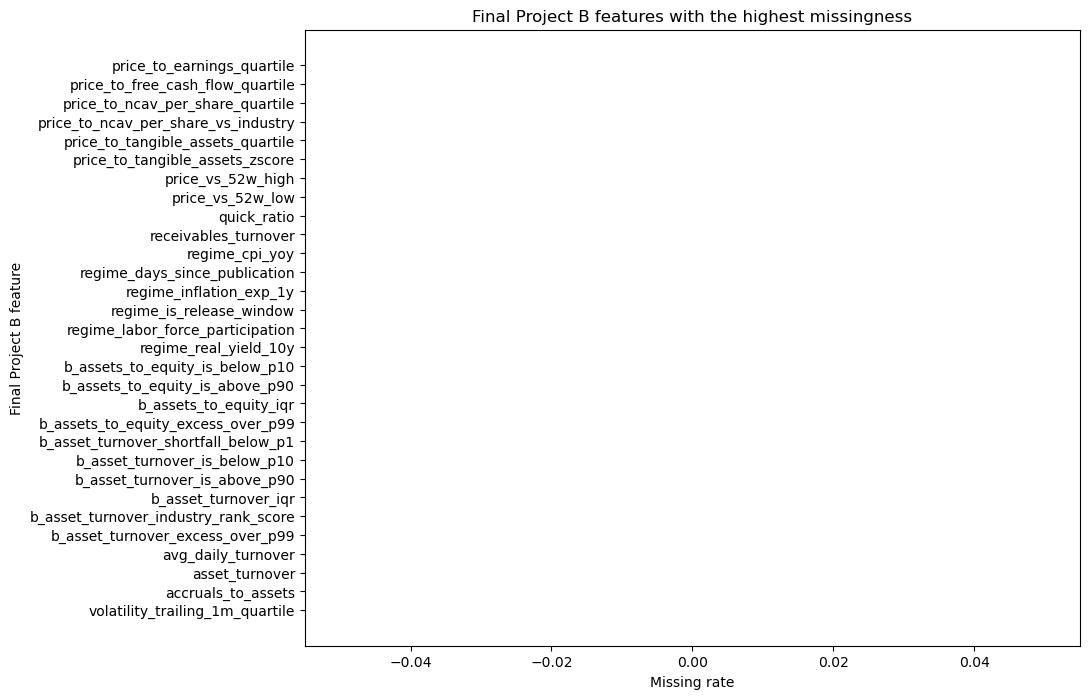

,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,median,p75,p95,p99,max,is_constant,is_near_constant_99pct_zero,high_missingness,extreme_skew_abs_gt_10,passes_basic_sanity_check
3,feature__b_asset_turnover_excess_over_p99,float64,98419,98419,0,0.0,0,96155,0.976996,39,...,0.000000,0.000000,0.000000,0.007012,0.049770,False,False,False,True,True
8,feature__b_asset_turnover_shortfall_below_p1,float64,98419,98419,0,0.0,0,97398,0.989626,18,...,0.000000,0.000000,0.000000,0.000142,0.062458,False,False,False,True,True
13,feature__b_assets_to_equity_shortfall_below_p1,float64,98419,98419,0,0.0,0,95343,0.968746,53,...,0.000000,0.000000,0.000000,1.282761,6.196217,False,False,False,True,True
14,feature__b_cash_conversion_cycle_excess_over_p99,float64,98419,98419,0,0.0,0,97279,0.988417,20,...,0.000000,0.000000,0.000000,0.729767,4.360508,False,False,False,True,True
20,feature__b_cfo_margin_excess_over_p99,float64,98419,98419,0,0.0,0,94873,0.963970,61,...,0.000000,0.000000,0.000000,0.027392,1.230524,False,False,False,True,True
23,feature__b_cfo_margin_pct_diff_to_p50,float64,98419,98419,0,0.0,0,1549,0.015739,1632,...,1.106714,2.833251,13.191308,53.044646,514.374164,False,False,False,True,True
25,feature__b_current_assets_to_total_liabilities...,int64,98419,98419,0,0.0,0,98419,1.000000,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,True,True,False,False,False
31,feature__b_current_ratio_excess_over_p99,float64,98419,98419,0,0.0,0,98175,0.997521,5,...,0.000000,0.000000,0.000000,0.000000,1.790391,False,True,False,True,True
35,feature__b_days_inventory_outstanding_excess_o...,float64,98419,98419,0,0.0,0,97732,0.993020,12,...,0.000000,0.000000,0.000000,0.000000,5.073327,False,True,False,True,True
40,feature__b_days_inventory_outstanding_shortfal...,float64,98419,98419,0,0.0,0,96952,0.985094,25,...,0.000000,0.000000,0.000000,0.124603,0.640187,False,False,False,True,True


,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,median,p75,p95,p99,max,is_constant,is_near_constant_99pct_zero,high_missingness,extreme_skew_abs_gt_10,passes_basic_sanity_check
3,feature__b_asset_turnover_excess_over_p99,float64,98419,98419,0,0.0,0,96155,0.976996,39,...,0.000000,0.000000,0.000000,0.007012,0.049770,False,False,False,True,True
8,feature__b_asset_turnover_shortfall_below_p1,float64,98419,98419,0,0.0,0,97398,0.989626,18,...,0.000000,0.000000,0.000000,0.000142,0.062458,False,False,False,True,True
13,feature__b_assets_to_equity_shortfall_below_p1,float64,98419,98419,0,0.0,0,95343,0.968746,53,...,0.000000,0.000000,0.000000,1.282761,6.196217,False,False,False,True,True
14,feature__b_cash_conversion_cycle_excess_over_p99,float64,98419,98419,0,0.0,0,97279,0.988417,20,...,0.000000,0.000000,0.000000,0.729767,4.360508,False,False,False,True,True
20,feature__b_cfo_margin_excess_over_p99,float64,98419,98419,0,0.0,0,94873,0.963970,61,...,0.000000,0.000000,0.000000,0.027392,1.230524,False,False,False,True,True
23,feature__b_cfo_margin_pct_diff_to_p50,float64,98419,98419,0,0.0,0,1549,0.015739,1632,...,1.106714,2.833251,13.191308,53.044646,514.374164,False,False,False,True,True
25,feature__b_current_assets_to_total_liabilities...,int64,98419,98419,0,0.0,0,98419,1.000000,1,...,0.000000,0.000000,0.000000,0.000000,0.000000,True,True,False,False,False
31,feature__b_current_ratio_excess_over_p99,float64,98419,98419,0,0.0,0,98175,0.997521,5,...,0.000000,0.000000,0.000000,0.000000,1.790391,False,True,False,True,True
35,feature__b_days_inventory_outstanding_excess_o...,float64,98419,98419,0,0.0,0,97732,0.993020,12,...,0.000000,0.000000,0.000000,0.000000,5.073327,False,True,False,True,True
40,feature__b_days_inventory_outstanding_shortfal...,float64,98419,98419,0,0.0,0,96952,0.985094,25,...,0.000000,0.000000,0.000000,0.124603,0.640187,False,False,False,True,True


In [14]:
missing_plot = (
    final_feature_b_summary
    .sort_values("missing_rate", ascending=False)
    .head(TOP_MISSING_FEATURES_TO_PLOT)
    .sort_values("missing_rate")
)

if not missing_plot.empty:
    plt.figure(figsize=(10, 8))
    plt.barh(
        missing_plot["column"].str.replace("feature__", "", regex=False),
        missing_plot["missing_rate"]
    )
    plt.xlabel("Missing rate")
    plt.ylabel("Final Project B feature")
    plt.title("Final Project B features with the highest missingness")
    save_current_figure("final_feature_b_missingness")
    plt.show()

flagged_feature_checks = final_feature_b_summary[
    final_feature_b_summary[
        [
            "is_constant",
            "is_near_constant_99pct_zero",
            "high_missingness",
            "extreme_skew_abs_gt_10"
        ]
    ].any(axis=1)
].copy()

export_table(
    "final_feature_b_flagged_sanity_checks",
    flagged_feature_checks
)

## 8. Residual correlation diagnostics for the final Project B set

Correlation is summarised to document remaining redundancy. No feature is automatically removed in this notebook because the Project B list is treated as predefined.


In [15]:
# Spearman correlation is suitable for non-normal and partly ordinal financial features.
if len(final_feature_b_features) >= 2:
    final_feature_b_corr = (
        df_train[final_feature_b_features]
        .apply(pd.to_numeric, errors="coerce")
        .corr(method="spearman")
    )

    upper_triangle = final_feature_b_corr.abs().where(
        np.triu(np.ones(final_feature_b_corr.shape), k=1).astype(bool)
    )

    highly_correlated_pairs = (
        upper_triangle.stack()
        .reset_index()
        .rename(columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
            0: "absolute_spearman"
        })
        .query("absolute_spearman > @CORR_THRESHOLD")
        .sort_values("absolute_spearman", ascending=False)
    )

    max_remaining_absolute_correlation = (
        upper_triangle.stack().max()
        if not upper_triangle.stack().empty
        else np.nan
    )
else:
    final_feature_b_corr = pd.DataFrame()
    highly_correlated_pairs = pd.DataFrame()
    max_remaining_absolute_correlation = np.nan

export_table(
    "final_feature_b_highly_correlated_pairs",
    highly_correlated_pairs,
    display_table=False
)

correlation_diagnostic_summary = pd.DataFrame([{
    "final_feature_b_count": len(final_feature_b_features),
    "correlation_threshold": CORR_THRESHOLD,
    "n_pairs_above_threshold": len(highly_correlated_pairs),
    "max_absolute_pairwise_spearman": max_remaining_absolute_correlation,
    "features_removed": 0,
    "interpretation": "Diagnostic only; no additional feature selection applied."
}])

export_table(
    "final_feature_b_correlation_diagnostic_summary",
    correlation_diagnostic_summary
)

display(correlation_diagnostic_summary)

,final_feature_b_count,correlation_threshold,n_pairs_above_threshold,max_absolute_pairwise_spearman,features_removed,interpretation
0,270,0.95,0,0.890071,0,Diagnostic only; no additional feature selecti...


,final_feature_b_count,correlation_threshold,n_pairs_above_threshold,max_absolute_pairwise_spearman,features_removed,interpretation
0,270,0.95,0,0.890071,0,Diagnostic only; no additional feature selecti...


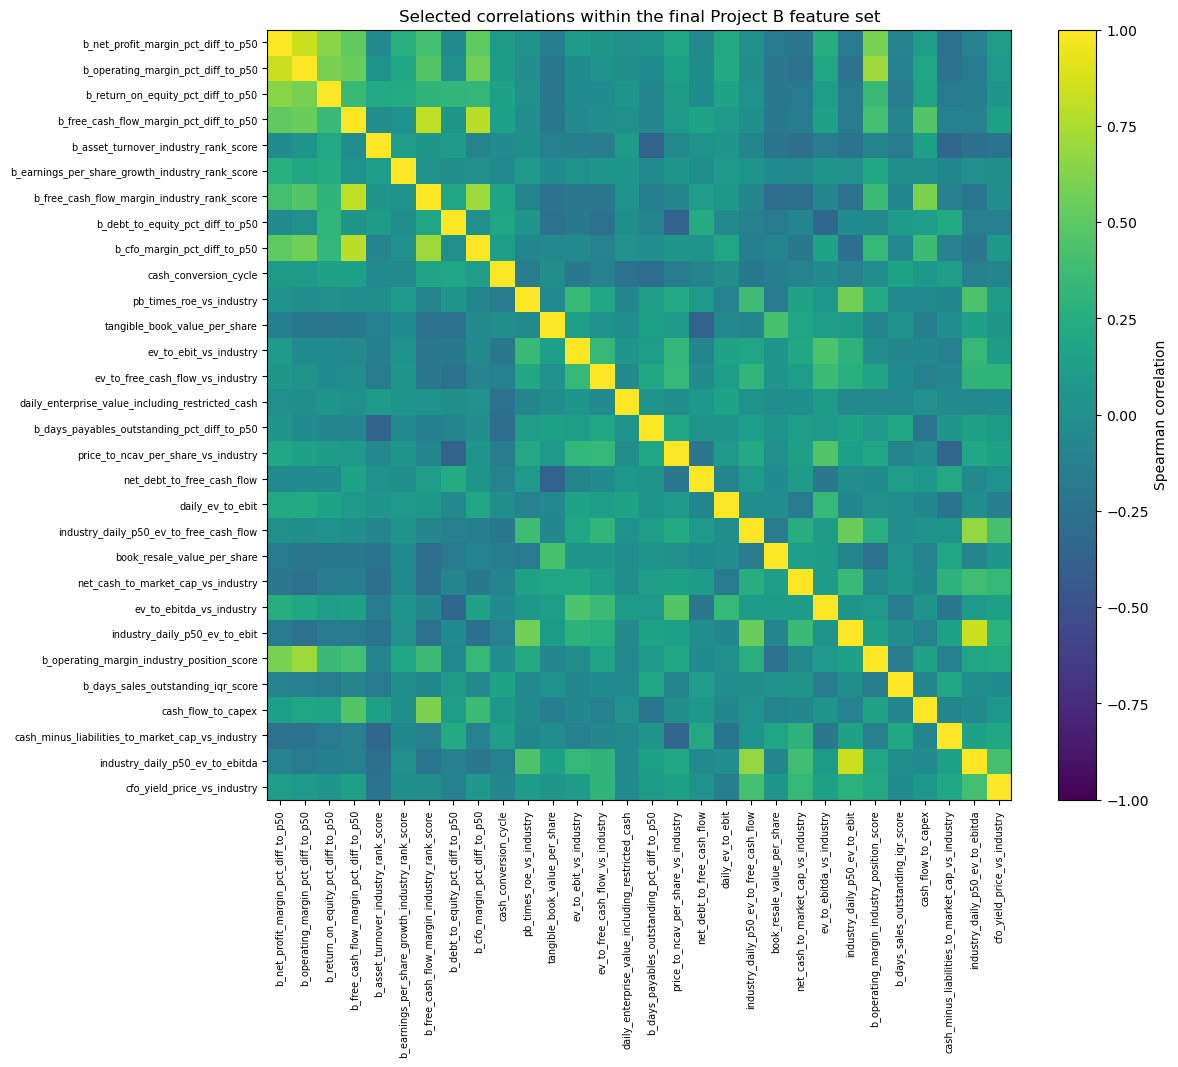

In [16]:
# Heatmap for a manageable high-variance subset of the final Project B features.
selected_corr_features = (
    final_feature_b_summary
    .query("column in @final_feature_b_features")
    .sort_values("std", ascending=False)
    .head(TOP_CORRELATION_FEATURES)["column"]
    .tolist()
)

if len(selected_corr_features) >= 2:
    selected_corr = (
        df_train[selected_corr_features]
        .apply(pd.to_numeric, errors="coerce")
        .corr(method="spearman")
    )

    plt.figure(figsize=(12, 10))
    image = plt.imshow(selected_corr, aspect="auto", vmin=-1, vmax=1)
    plt.colorbar(image, label="Spearman correlation")
    labels = [
        column.replace("feature__", "")
        for column in selected_corr_features
    ]
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=7)
    plt.yticks(range(len(labels)), labels, fontsize=7)
    plt.title("Selected correlations within the final Project B feature set")
    save_current_figure("final_feature_b_selected_correlation_heatmap")
    plt.show()

## 9. Selected distributions from the final Project B feature set

Only a small diagnostic subset is plotted. The complete numerical summary is exported as a table.


,feature
0,feature__b_net_profit_margin_pct_diff_to_p50
1,feature__b_operating_margin_pct_diff_to_p50
2,feature__b_return_on_equity_pct_diff_to_p50
3,feature__b_free_cash_flow_margin_pct_diff_to_p50
4,feature__b_asset_turnover_industry_rank_score
5,feature__b_earnings_per_share_growth_industry_...
6,feature__b_free_cash_flow_margin_industry_rank...
7,feature__b_debt_to_equity_pct_diff_to_p50
8,feature__b_cfo_margin_pct_diff_to_p50
9,feature__cash_conversion_cycle


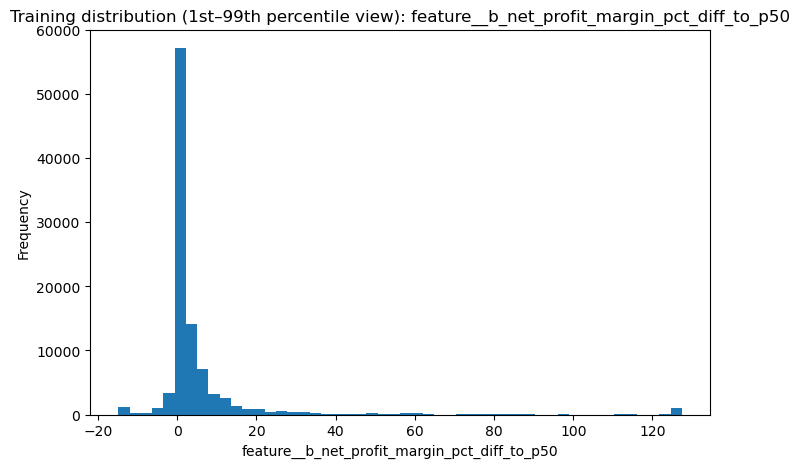

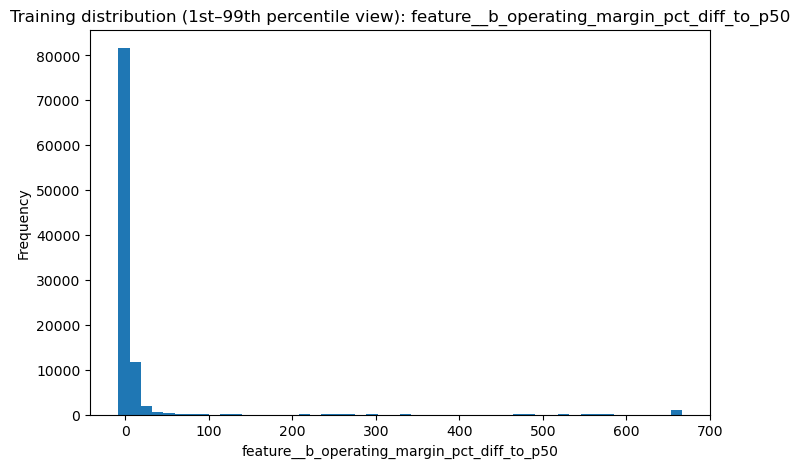

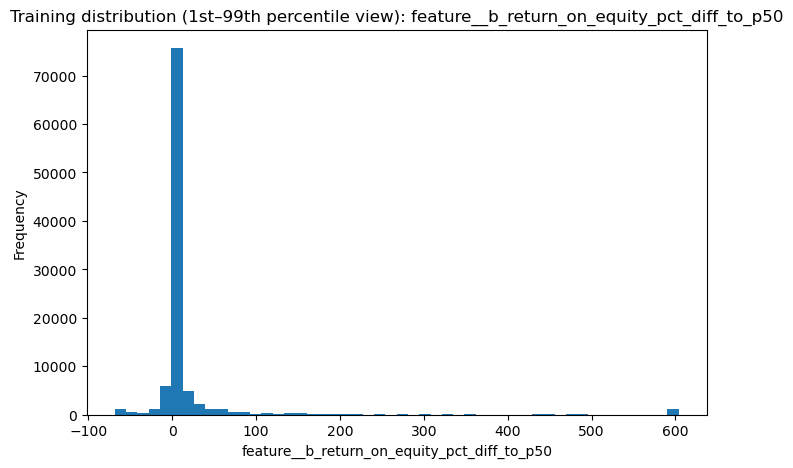

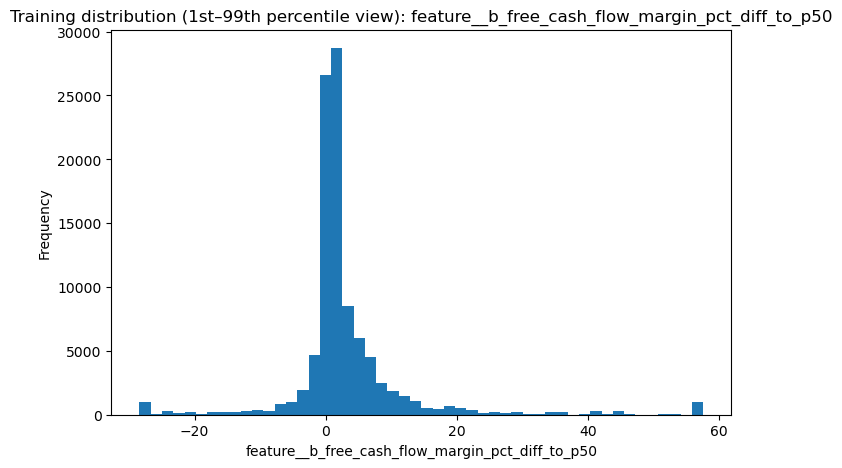

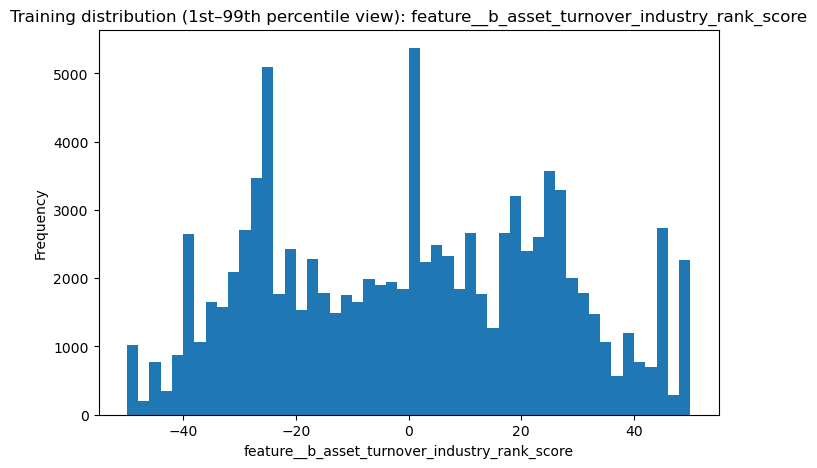

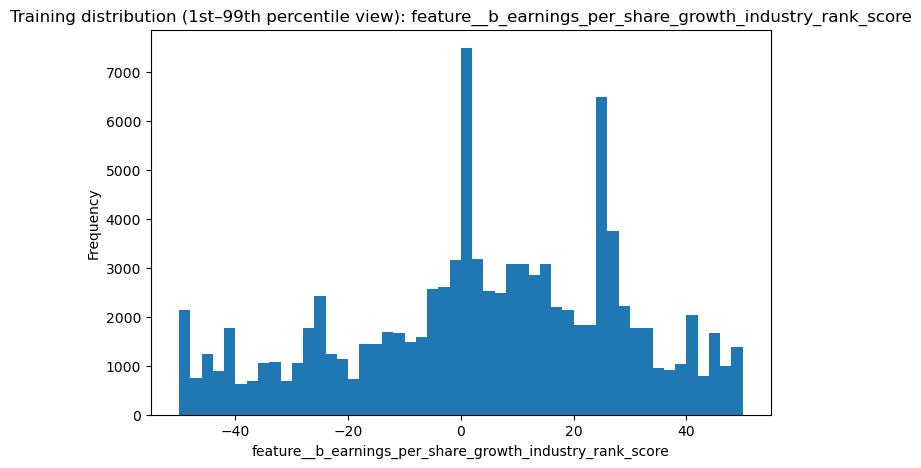

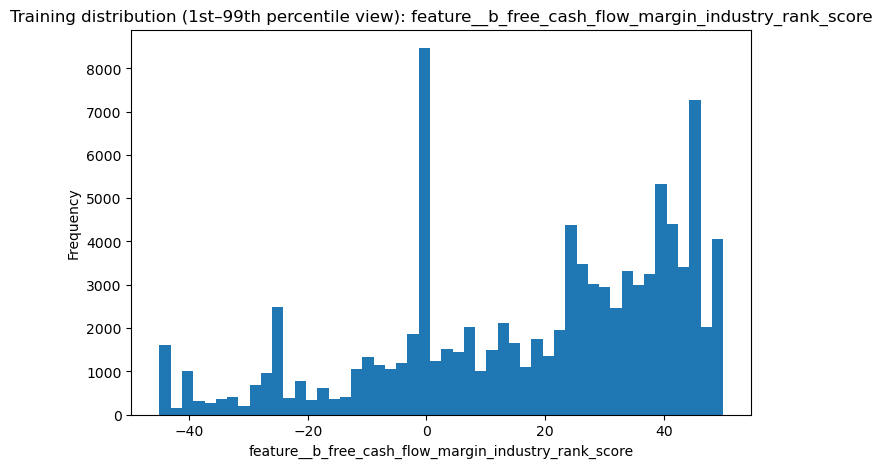

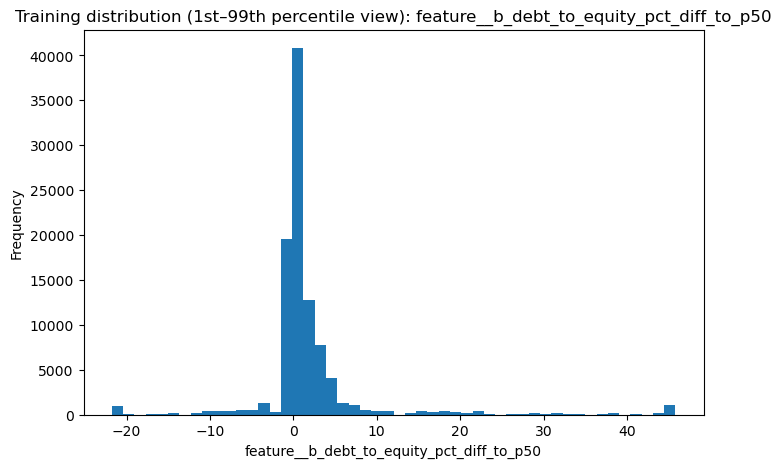

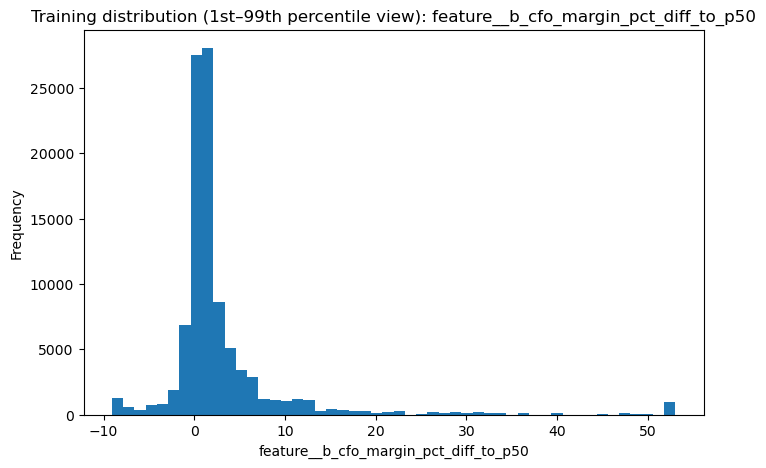

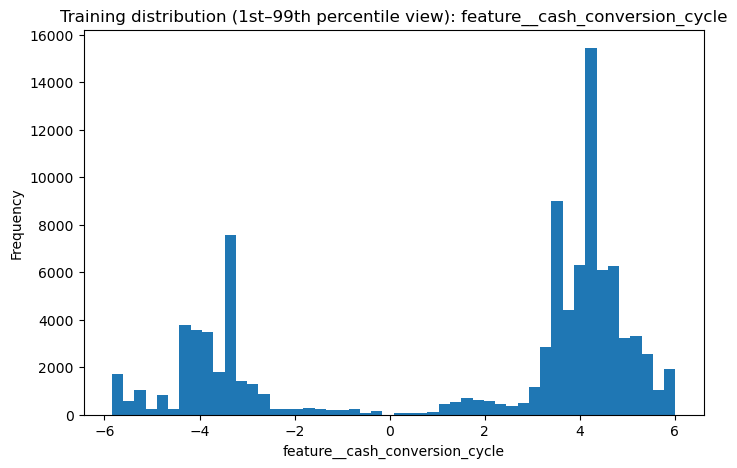

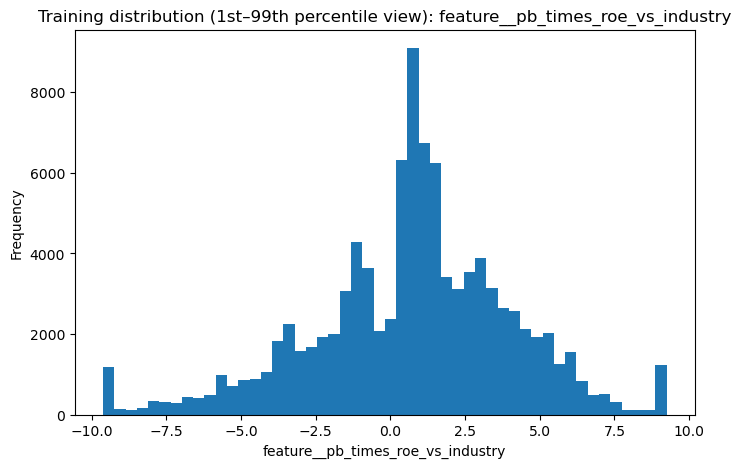

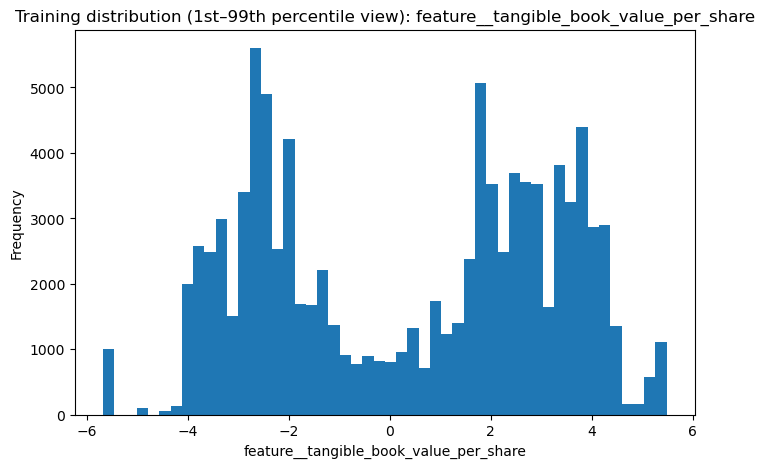

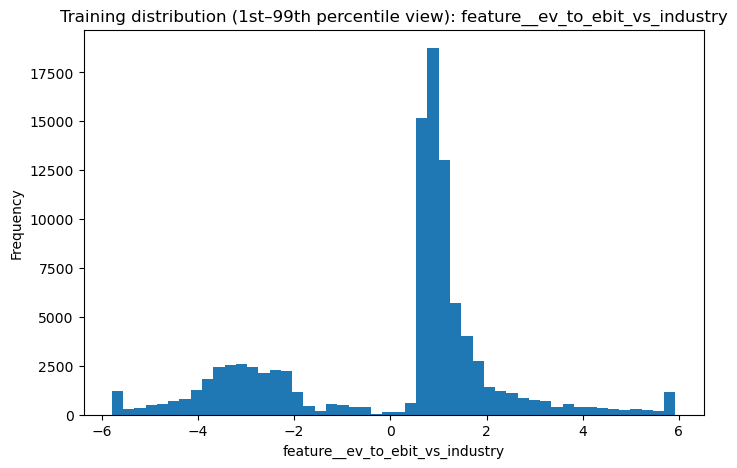

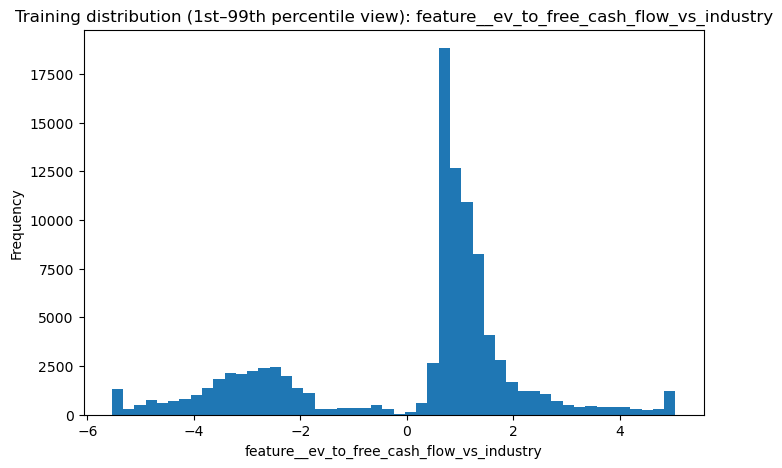

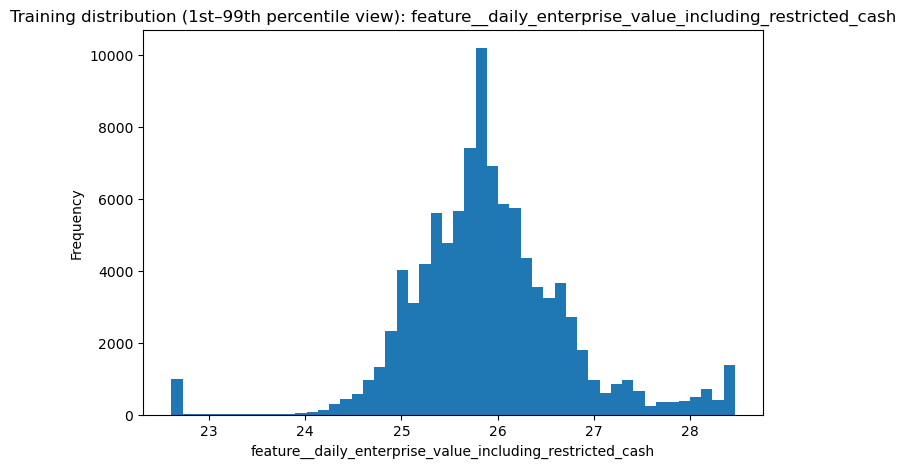

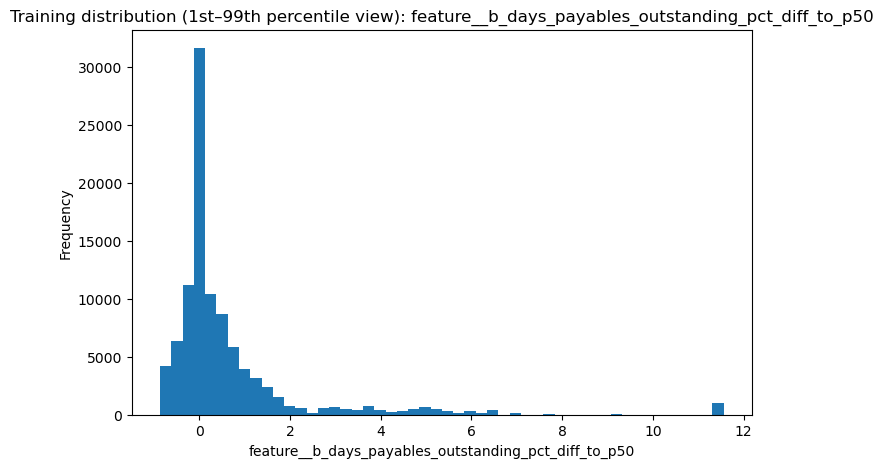

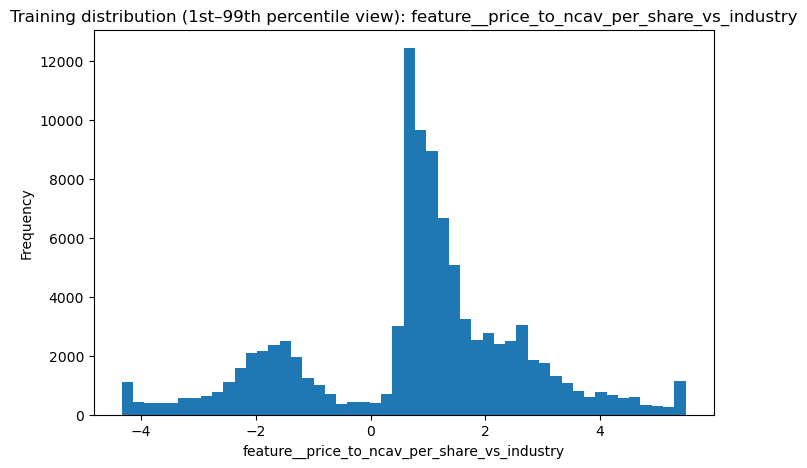

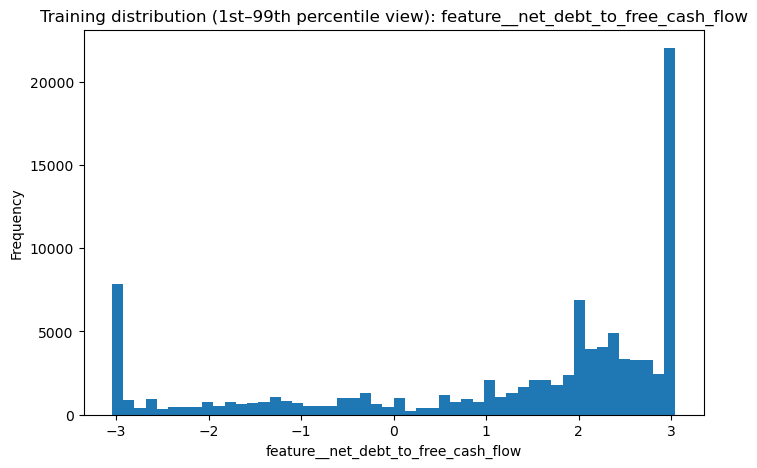

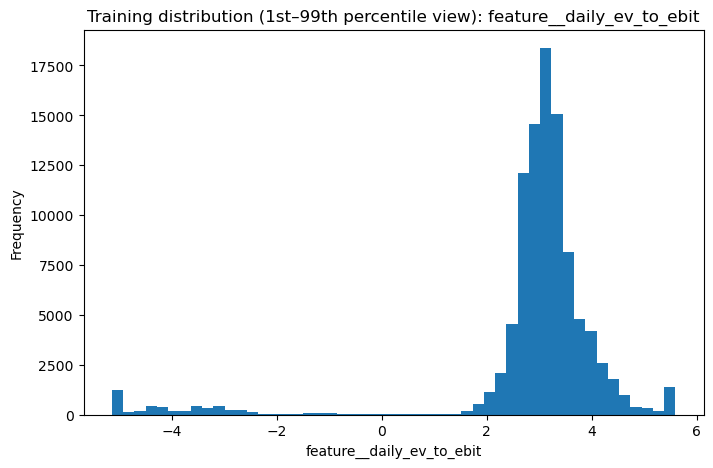

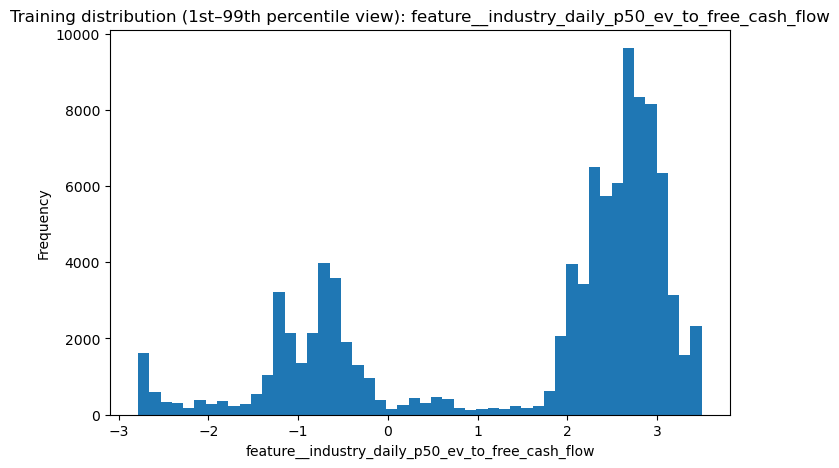

In [17]:
plot_features = (
    final_feature_b_summary[
        final_feature_b_summary["column"].isin(final_feature_b_features)
        & ~final_feature_b_summary["is_constant"]
    ]
    .sort_values(["missing_rate", "std"], ascending=[True, False])
    .head(TOP_VARIABLE_FEATURES_TO_PLOT)["column"]
    .tolist()
)

export_table(
    "final_feature_b_features_selected_for_distribution_plots",
    pd.DataFrame({"feature": plot_features})
)

for column in plot_features:
    values = pd.to_numeric(df_train[column], errors="coerce")
    values = values[np.isfinite(values)].dropna()

    if values.empty:
        continue

    # Clip plots only, not the data used in modelling.
    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    plotted_values = values.clip(lower=lower, upper=upper)

    plt.figure(figsize=(8, 5))
    plt.hist(plotted_values, bins=HISTOGRAM_BINS)
    plt.title(f"Training distribution (1st–99th percentile view): {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    save_current_figure(f"final_feature_b_histogram_{column}")
    plt.show()

## 10. Final Project B coverage across tickers and years

These checks identify features that are unavailable for particular securities or periods, and distinguish daily-changing from slow-moving or nearly static inputs.


In [18]:
coverage_rows = []

for feature in final_feature_b_features:
    numeric_values = pd.to_numeric(df_train[feature], errors="coerce")

    ticker_missing = (
        pd.DataFrame({
            "ticker": df_train[TICKER_COL],
            "is_missing": numeric_values.isna()
        })
        .groupby("ticker", dropna=False)["is_missing"]
        .mean()
    )

    year_missing = (
        pd.DataFrame({
            "year": df_train[YEAR_COL],
            "is_missing": numeric_values.isna()
        })
        .groupby("year", dropna=False)["is_missing"]
        .mean()
    )

    # Estimate within-ticker update frequency after chronological sorting.
    temp = pd.DataFrame({
        "ticker": df_train[TICKER_COL],
        "date": df_train[DATE_COL],
        "value": numeric_values
    }).sort_values(["ticker", "date"])

    previous = temp.groupby("ticker")["value"].shift(1)
    comparable = temp["value"].notna() & previous.notna()
    changed = comparable & temp["value"].ne(previous)

    change_rate = (
        changed.sum() / comparable.sum()
        if comparable.sum() > 0
        else np.nan
    )

    unique_per_ticker = (
        temp.groupby("ticker")["value"]
        .nunique(dropna=True)
    )

    coverage_rows.append({
        "feature": feature,
        "overall_missing_rate": numeric_values.isna().mean(),
        "max_ticker_missing_rate": ticker_missing.max(),
        "max_year_missing_rate": year_missing.max(),
        "tickers_fully_missing": int((ticker_missing == 1).sum()),
        "years_fully_missing": int((year_missing == 1).sum()),
        "median_unique_values_per_ticker": unique_per_ticker.median(),
        "mean_unique_values_per_ticker": unique_per_ticker.mean(),
        "within_ticker_change_rate": change_rate
    })

final_feature_b_coverage = pd.DataFrame(coverage_rows)

def assign_update_frequency(change_rate):
    if pd.isna(change_rate):
        return "unknown"
    if change_rate < 0.001:
        return "almost static"
    if change_rate < 0.05:
        return "slow-moving"
    return "frequently changing"

final_feature_b_coverage["update_frequency_group"] = (
    final_feature_b_coverage["within_ticker_change_rate"]
    .map(assign_update_frequency)
)

export_table(
    "final_feature_b_ticker_year_coverage_and_change_rate",
    final_feature_b_coverage,
    display_table=False
)

update_frequency_summary = (
    final_feature_b_coverage["update_frequency_group"]
    .value_counts(dropna=False)
    .rename_axis("update_frequency_group")
    .reset_index(name="n_features")
)

export_table(
    "final_feature_b_update_frequency_summary",
    update_frequency_summary
)

display(update_frequency_summary)

display(
    final_feature_b_coverage
    .sort_values(
        ["tickers_fully_missing", "max_ticker_missing_rate"],
        ascending=False
    )
    .head(20)
)

,update_frequency_group,n_features
0,slow-moving,128
1,almost static,75
2,frequently changing,67


,update_frequency_group,n_features
0,slow-moving,128
1,almost static,75
2,frequently changing,67


,feature,overall_missing_rate,max_ticker_missing_rate,max_year_missing_rate,tickers_fully_missing,years_fully_missing,median_unique_values_per_ticker,mean_unique_values_per_ticker,within_ticker_change_rate,update_frequency_group
0,feature__accruals_to_assets,0.0,0.0,0.0,0,0,17.0,16.836735,0.015795,slow-moving
1,feature__asset_turnover,0.0,0.0,0.0,0,0,17.0,16.836735,0.015795,slow-moving
2,feature__avg_daily_turnover,0.0,0.0,0.0,0,0,17.0,16.918367,0.015887,slow-moving
3,feature__b_asset_turnover_excess_over_p99,0.0,0.0,0.0,0,0,1.0,1.377551,0.000498,almost static
4,feature__b_asset_turnover_industry_rank_score,0.0,0.0,0.0,0,0,17.0,15.724490,0.015144,slow-moving
5,feature__b_asset_turnover_iqr,0.0,0.0,0.0,0,0,17.0,16.653061,0.015653,slow-moving
6,feature__b_asset_turnover_is_above_p90,0.0,0.0,0.0,0,0,1.0,1.132653,0.000529,almost static
7,feature__b_asset_turnover_is_below_p10,0.0,0.0,0.0,0,0,1.0,1.163265,0.000549,almost static
8,feature__b_asset_turnover_shortfall_below_p1,0.0,0.0,0.0,0,0,1.0,1.173469,0.000224,almost static
9,feature__b_assets_to_equity_excess_over_p99,0.0,0.0,0.0,0,0,1.0,1.724490,0.000865,almost static


## 11. Target EDA — training data only

In [19]:
available_target_columns = target_cols.copy()

# Raw label fallback: include selected raw labels when no derived targets exist.
if not available_target_columns:
    available_target_columns = label_cols.copy()

if SELECTED_TARGETS is not None:
    available_target_columns = [
        column for column in SELECTED_TARGETS
        if column in df_train.columns
    ]

print("Targets included in EDA:")
for column in available_target_columns:
    print(" -", column)

target_summary = numeric_column_summary(
    df_train,
    available_target_columns
)

target_summary["positive_rate"] = [
    (
        pd.to_numeric(df_train[column], errors="coerce") > 0
    ).mean()
    for column in target_summary["column"]
]

target_summary["negative_rate"] = [
    (
        pd.to_numeric(df_train[column], errors="coerce") < 0
    ).mean()
    for column in target_summary["column"]
]

export_table("target_summary_overall", target_summary)

Targets included in EDA:
 - target__pi_hindsight_entry_6bins
 - target__pi_hindsight_entry_long
 - target__pi_hindsight_entry_original
 - target__pi_hindsight_entry_positive
 - target__rl_expert_action
 - target__rl_long_action_binary
 - target__rl_long_action_quality
 - target__rl_long_current_pnl
 - target__rl_long_high_confidence
 - target__rl_long_is_best
 - target__rl_long_reward
 - target__rl_long_reward_margin


,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,p01,p05,p25,median,p75,p95,p99,max,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,Int64,98419,98419,0,0.0,0,77569,0.788151,6,...,0.000000,0.00000,0.00000,0.000000,0.000000,5.000000,5.000000,5.000000,0.211849,0.000000
1,target__pi_hindsight_entry_long,float64,98419,98419,0,0.0,0,77569,0.788151,13337,...,0.000000,0.00000,0.00000,0.000000,0.000000,0.573514,1.000000,1.000000,0.211849,0.000000
2,target__pi_hindsight_entry_original,Int64,98419,98419,0,0.0,0,86494,0.878834,2,...,0.000000,0.00000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.121166,0.000000
3,target__pi_hindsight_entry_positive,Int64,98419,98419,0,0.0,0,77569,0.788151,2,...,0.000000,0.00000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.211849,0.000000
4,target__rl_expert_action,int64,98419,98419,0,0.0,0,45132,0.458570,3,...,0.000000,0.00000,0.00000,1.000000,1.000000,2.000000,2.000000,2.000000,0.541430,0.000000
5,target__rl_long_action_binary,int64,98419,98419,0,0.0,0,50579,0.513915,2,...,0.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.486085,0.000000
6,target__rl_long_action_quality,float64,98419,98419,0,0.0,0,0,0.000000,8156,...,-2.534800,-2.53480,-2.40195,-2.172100,1.959500,3.349300,3.349700,3.349800,0.486085,0.513915
7,target__rl_long_current_pnl,float64,98419,98419,0,0.0,0,0,0.000000,63592,...,-1598.287691,-896.69580,-430.78035,-252.627375,408.157475,3281.647079,6057.164814,54391.837500,0.486085,0.513915
8,target__rl_long_high_confidence,Int64,98419,98419,0,0.0,0,53638,0.544996,2,...,0.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.455004,0.000000
9,target__rl_long_is_best,Int64,98419,98419,0,0.0,0,53272,0.541278,2,...,0.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.458722,0.000000


,column,dtype,n_rows,count_numeric,missing_count,missing_rate,non_finite_count,zero_count,zero_rate,n_unique,...,p01,p05,p25,median,p75,p95,p99,max,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,Int64,98419,98419,0,0.0,0,77569,0.788151,6,...,0.000000,0.00000,0.00000,0.000000,0.000000,5.000000,5.000000,5.000000,0.211849,0.000000
1,target__pi_hindsight_entry_long,float64,98419,98419,0,0.0,0,77569,0.788151,13337,...,0.000000,0.00000,0.00000,0.000000,0.000000,0.573514,1.000000,1.000000,0.211849,0.000000
2,target__pi_hindsight_entry_original,Int64,98419,98419,0,0.0,0,86494,0.878834,2,...,0.000000,0.00000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.121166,0.000000
3,target__pi_hindsight_entry_positive,Int64,98419,98419,0,0.0,0,77569,0.788151,2,...,0.000000,0.00000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.211849,0.000000
4,target__rl_expert_action,int64,98419,98419,0,0.0,0,45132,0.458570,3,...,0.000000,0.00000,0.00000,1.000000,1.000000,2.000000,2.000000,2.000000,0.541430,0.000000
5,target__rl_long_action_binary,int64,98419,98419,0,0.0,0,50579,0.513915,2,...,0.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.486085,0.000000
6,target__rl_long_action_quality,float64,98419,98419,0,0.0,0,0,0.000000,8156,...,-2.534800,-2.53480,-2.40195,-2.172100,1.959500,3.349300,3.349700,3.349800,0.486085,0.513915
7,target__rl_long_current_pnl,float64,98419,98419,0,0.0,0,0,0.000000,63592,...,-1598.287691,-896.69580,-430.78035,-252.627375,408.157475,3281.647079,6057.164814,54391.837500,0.486085,0.513915
8,target__rl_long_high_confidence,Int64,98419,98419,0,0.0,0,53638,0.544996,2,...,0.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.455004,0.000000
9,target__rl_long_is_best,Int64,98419,98419,0,0.0,0,53272,0.541278,2,...,0.000000,0.00000,0.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.458722,0.000000


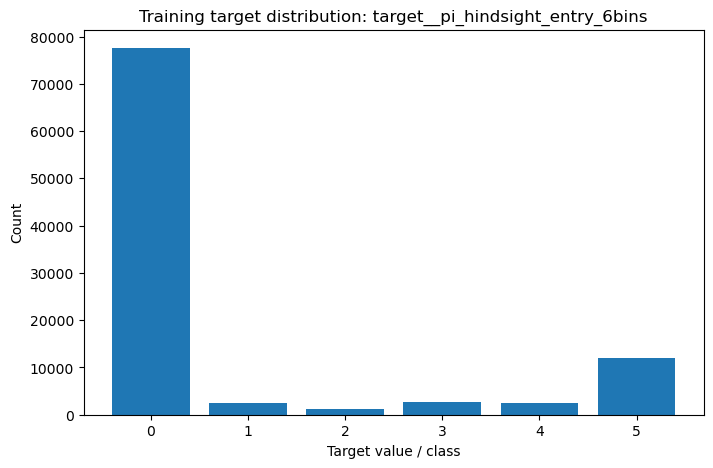

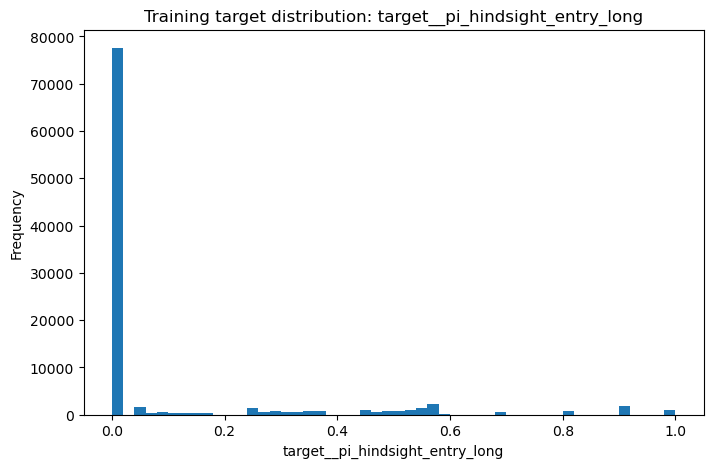

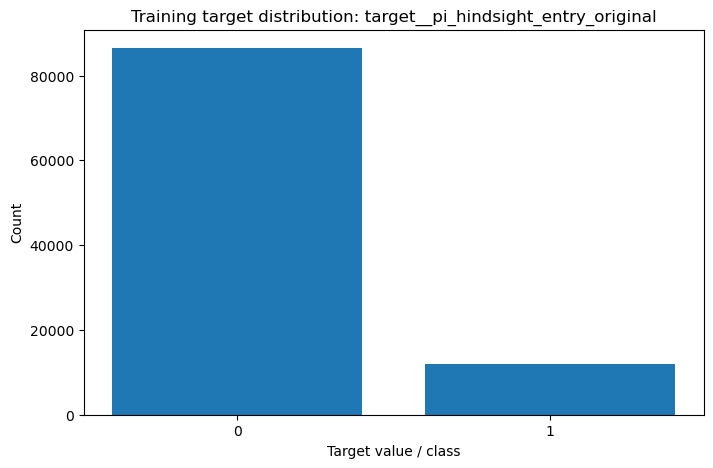

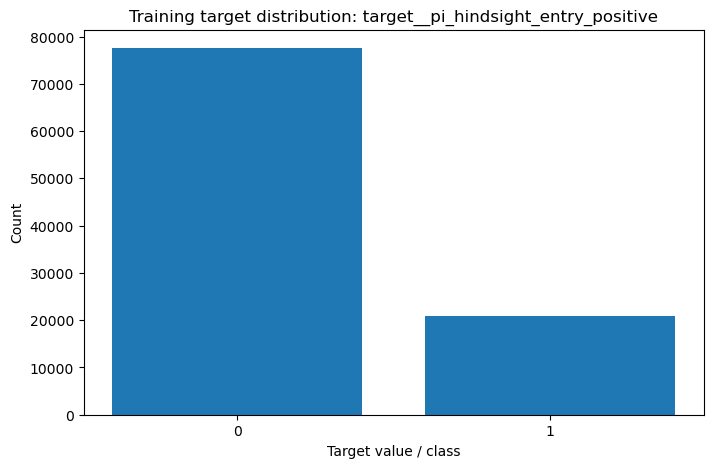

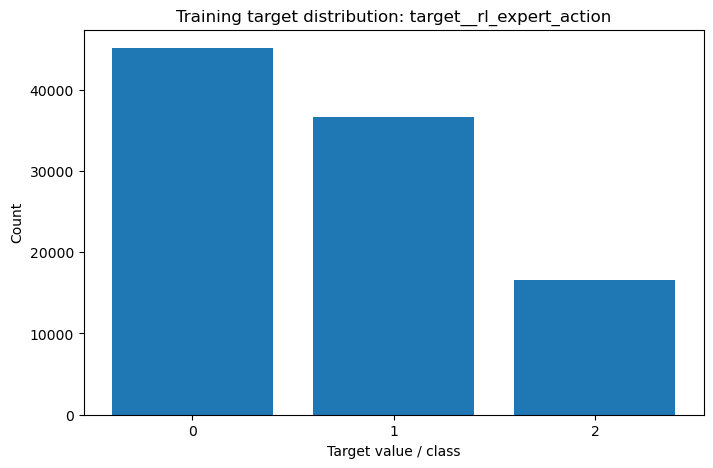

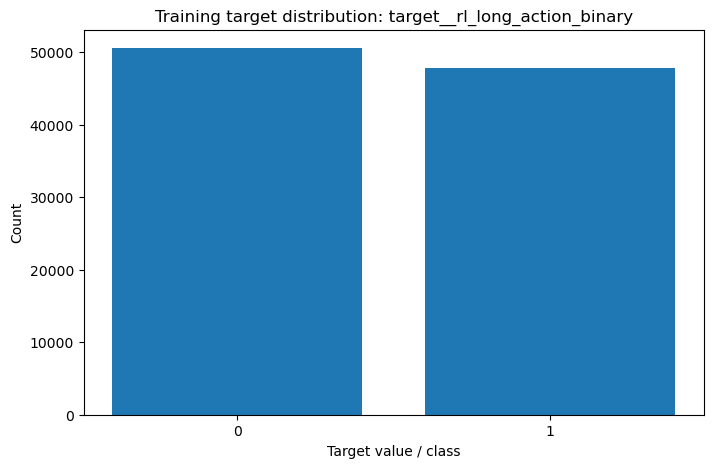

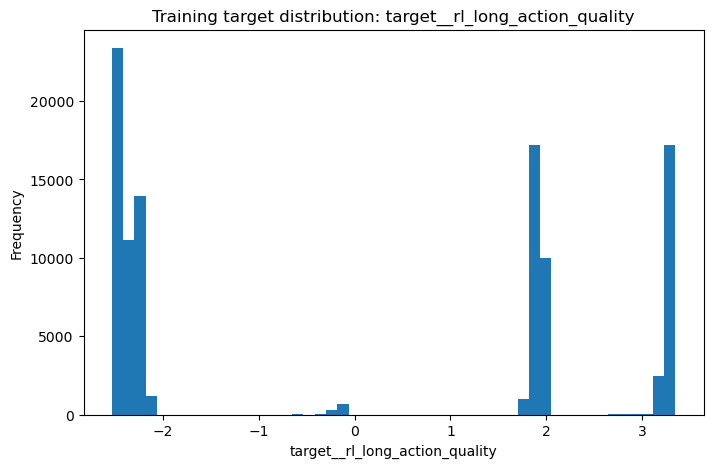

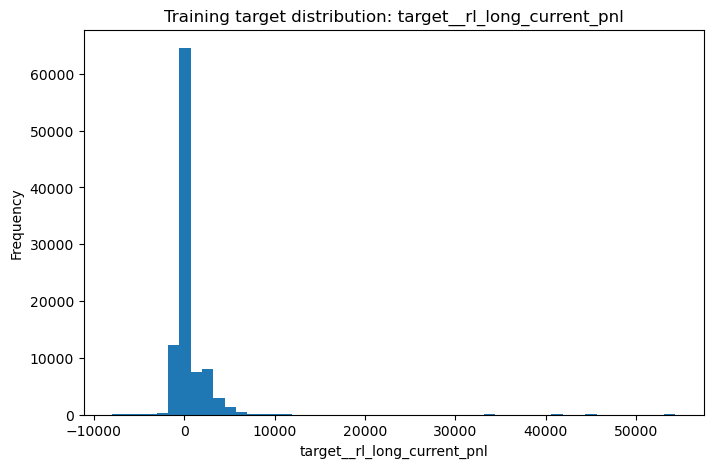

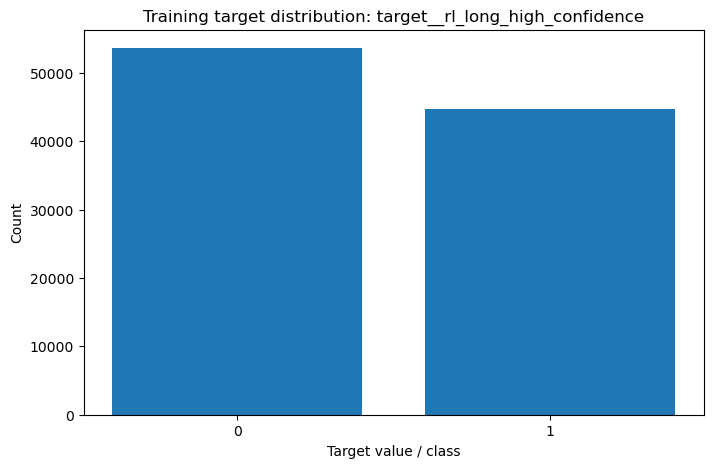

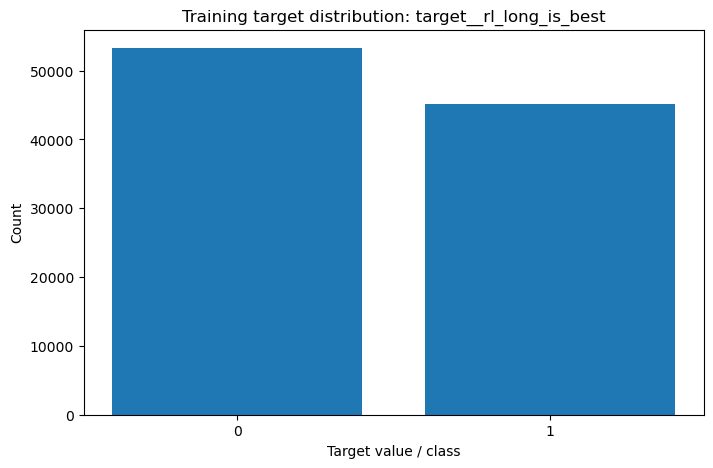

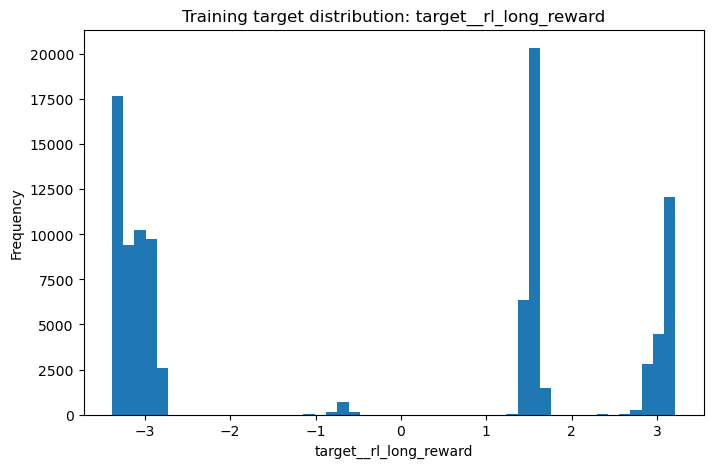

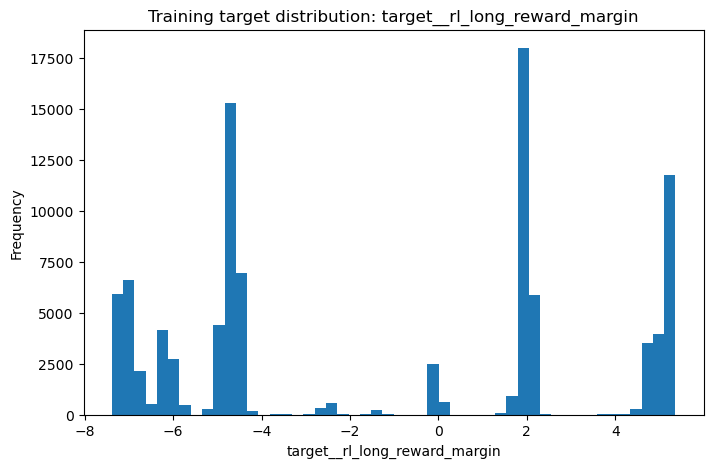

In [20]:
for column in available_target_columns:
    values = pd.to_numeric(df_train[column], errors="coerce").dropna()

    if values.empty:
        continue

    plt.figure(figsize=(8, 5))

    n_unique = values.nunique()
    if n_unique <= 20:
        counts = values.value_counts().sort_index()
        plt.bar(counts.index.astype(str), counts.values)
        plt.xlabel("Target value / class")
        plt.ylabel("Count")
    else:
        plt.hist(values, bins=HISTOGRAM_BINS)
        plt.xlabel(column)
        plt.ylabel("Frequency")

    plt.title(f"Training target distribution: {column}")
    save_current_figure(f"target_distribution_{column}")
    plt.show()

## 12. Target distribution by year

,target,year,n_obs,mean,std,min,median,max,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,2020,24650,1.03931,1.886995,0.0,0.0,5.0,0.735132,0.264868,0.000000
1,target__pi_hindsight_entry_6bins,2021,24696,0.853782,1.768902,0.0,0.0,5.0,0.790614,0.209386,0.000000
2,target__pi_hindsight_entry_6bins,2022,24598,0.665826,1.578213,0.0,0.0,5.0,0.826205,0.173795,0.000000
3,target__pi_hindsight_entry_6bins,2023,24475,0.801185,1.720911,0.0,0.0,5.0,0.800817,0.199183,0.000000
4,target__pi_hindsight_entry_long,2020,24650,0.12308,0.252567,0.0,0.0,1.0,0.735132,0.264868,0.000000
5,target__pi_hindsight_entry_long,2021,24696,0.099532,0.224878,0.0,0.0,1.0,0.790614,0.209386,0.000000
6,target__pi_hindsight_entry_long,2022,24598,0.075652,0.198147,0.0,0.0,1.0,0.826205,0.173795,0.000000
7,target__pi_hindsight_entry_long,2023,24475,0.092712,0.217228,0.0,0.0,1.0,0.800817,0.199183,0.000000
8,target__pi_hindsight_entry_original,2020,24650,0.150629,0.357694,0.0,0.0,1.0,0.849371,0.150629,0.000000
9,target__pi_hindsight_entry_original,2021,24696,0.124312,0.329943,0.0,0.0,1.0,0.875688,0.124312,0.000000


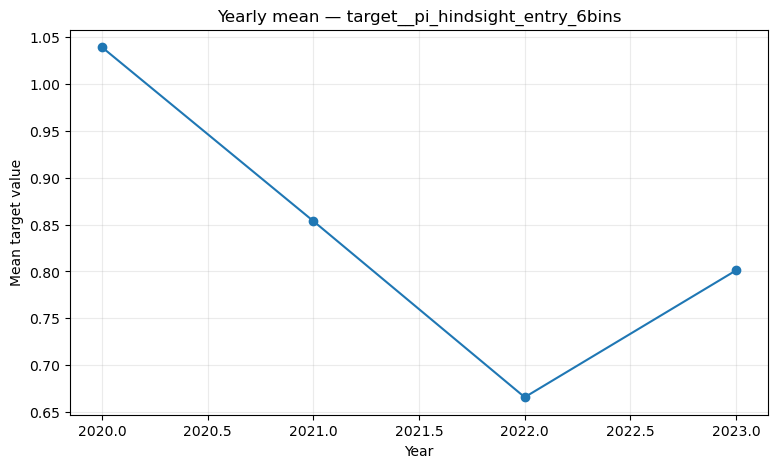

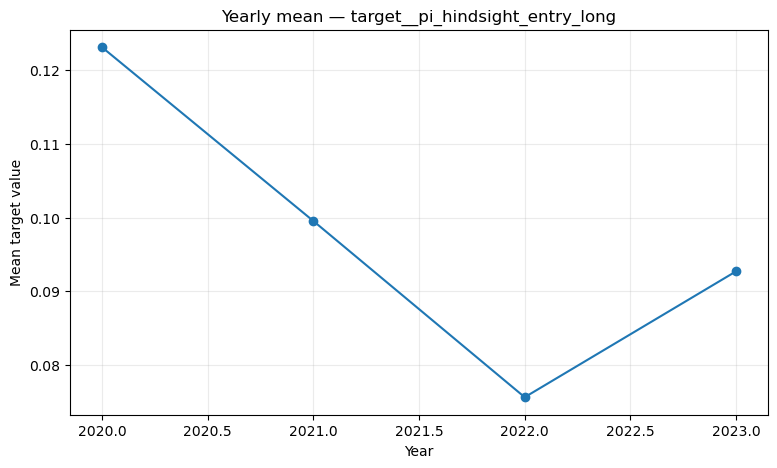

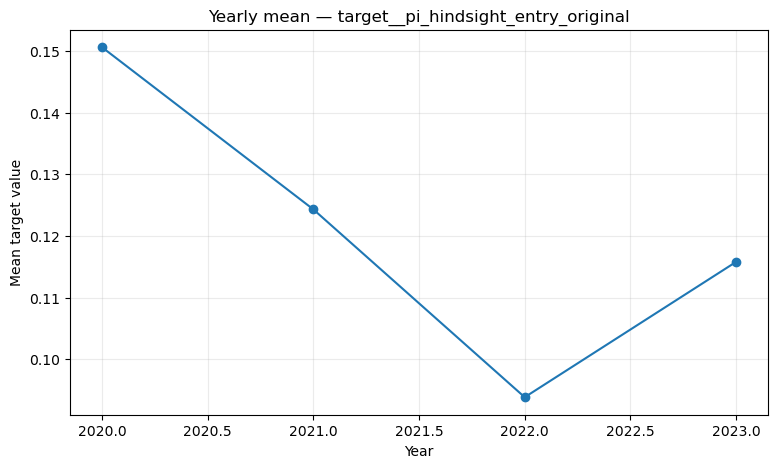

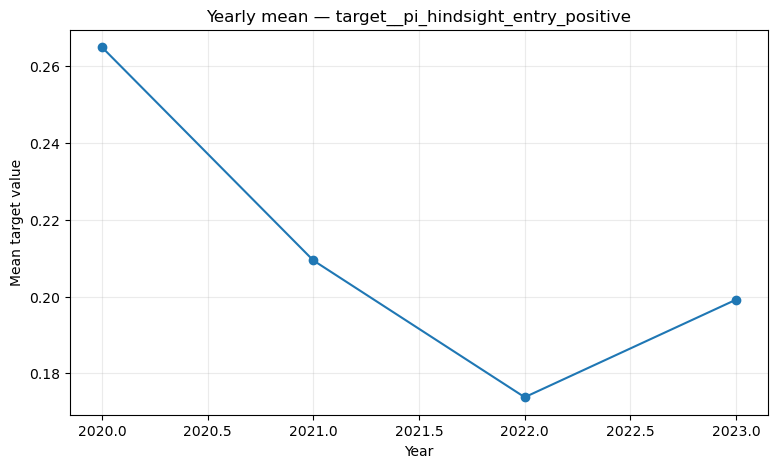

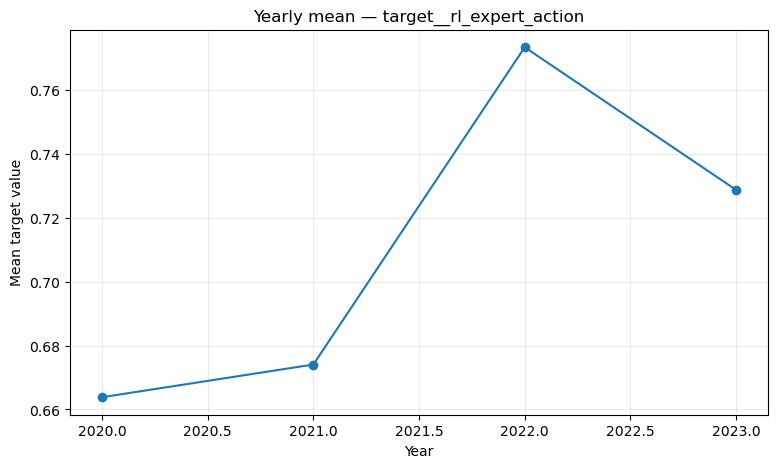

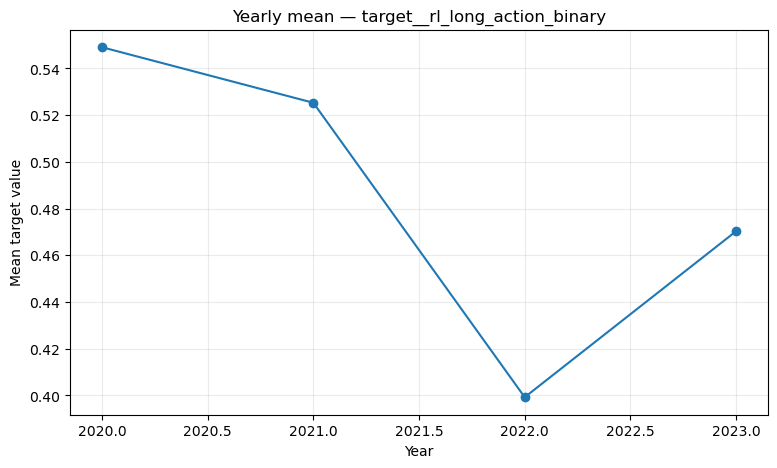

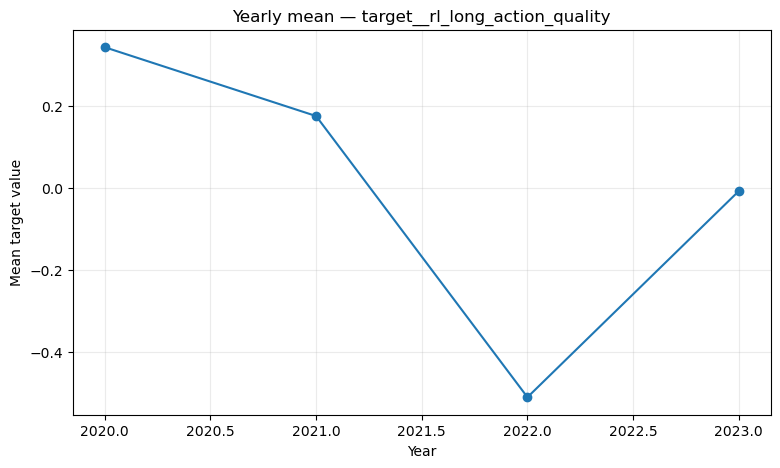

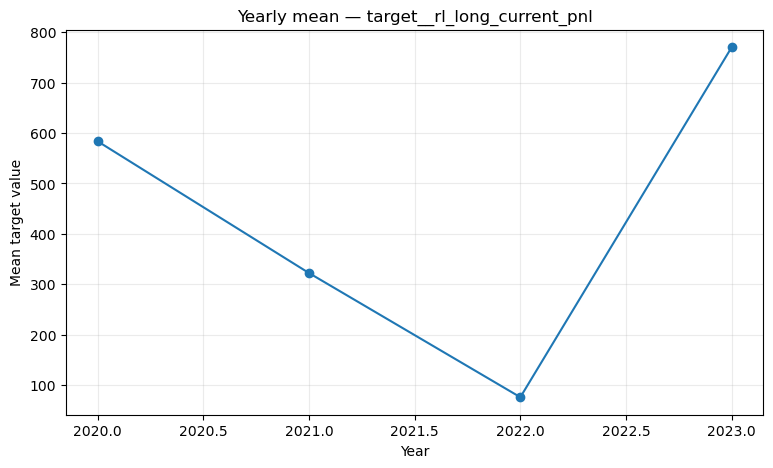

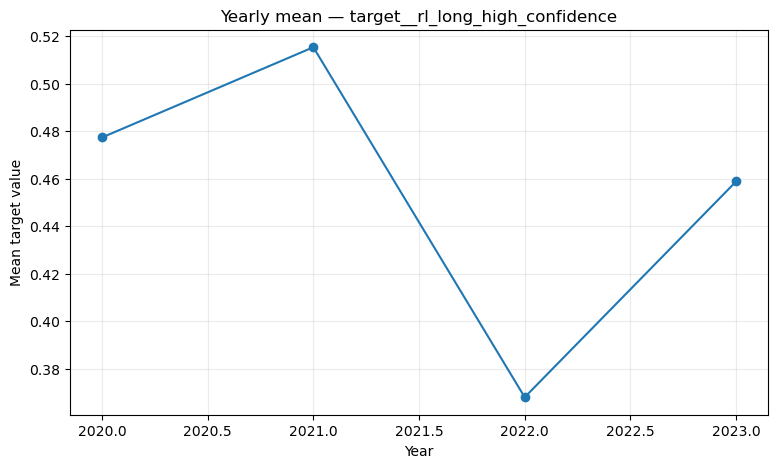

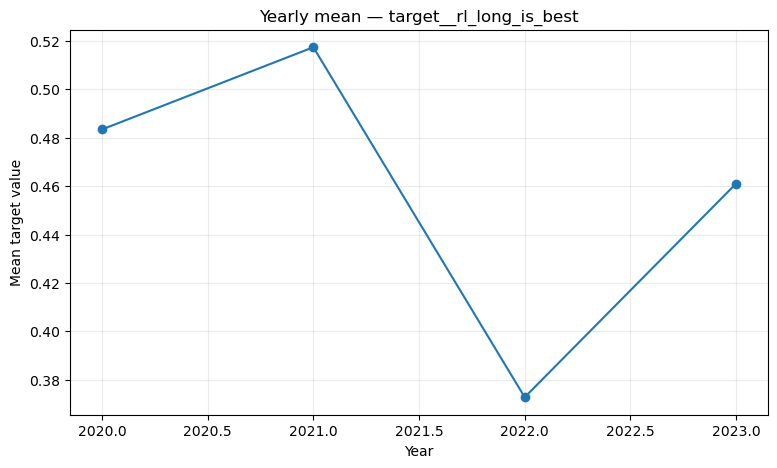

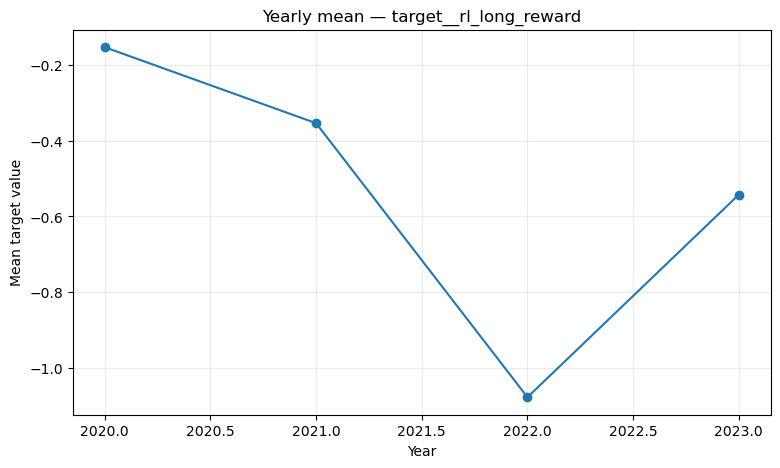

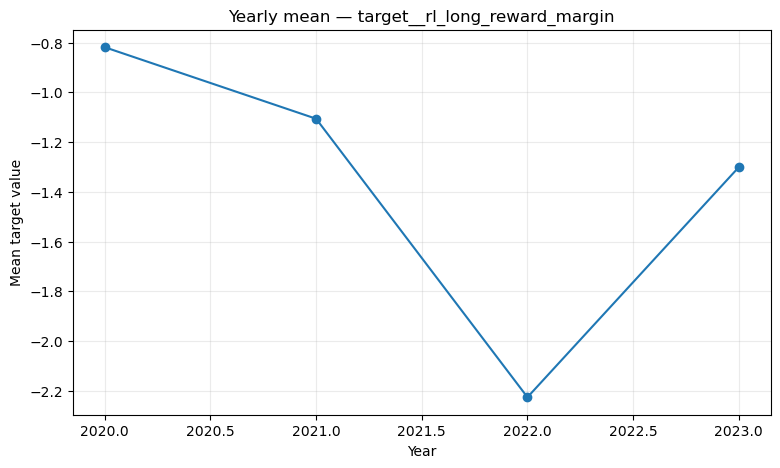

In [21]:
target_year_rows = []

for column in available_target_columns:
    temporary = df_train[[YEAR_COL, column]].copy()
    temporary[column] = pd.to_numeric(
        temporary[column],
        errors="coerce"
    )
    temporary = temporary.dropna(subset=[YEAR_COL, column])

    yearly = (
        temporary.groupby(YEAR_COL)[column]
        .agg(
            n_obs="size",
            mean="mean",
            std="std",
            min="min",
            median="median",
            max="max"
        )
        .reset_index()
    )

    rates = (
        temporary.groupby(YEAR_COL)[column]
        .apply(
            lambda values: pd.Series({
                "zero_rate": (values == 0).mean(),
                "positive_rate": (values > 0).mean(),
                "negative_rate": (values < 0).mean()
            })
        )
        .unstack()
        .reset_index()
    )

    yearly = yearly.merge(rates, on=YEAR_COL, how="left")
    yearly.insert(0, "target", column)
    target_year_rows.append(yearly)

target_by_year = (
    pd.concat(target_year_rows, ignore_index=True)
    if target_year_rows
    else pd.DataFrame()
)

export_table("target_summary_by_year", target_by_year)

for column in available_target_columns:
    plot_data = target_by_year[
        target_by_year["target"] == column
    ].sort_values(YEAR_COL)

    if plot_data.empty:
        continue

    plt.figure(figsize=(9, 5))
    plt.plot(
        plot_data[YEAR_COL],
        plot_data["mean"],
        marker="o"
    )
    plt.title(f"Yearly mean — {column}")
    plt.xlabel("Year")
    plt.ylabel("Mean target value")
    plt.grid(alpha=0.25)
    save_current_figure(f"target_yearly_mean_{column}")
    plt.show()

## 13. Target distribution by ticker

,target,attr__ticker,n_obs,mean,std,min,median,max,zero_rate,positive_rate,negative_rate
0,target__pi_hindsight_entry_6bins,AAPL,1006,1.244533,2.030083,0.0,0.0,5.0,0.697813,0.302187,0.000000
1,target__pi_hindsight_entry_6bins,ABBV,1006,0.799205,1.731028,0.0,0.0,5.0,0.805169,0.194831,0.000000
2,target__pi_hindsight_entry_6bins,ABT,1006,0.708748,1.634109,0.0,0.0,5.0,0.823062,0.176938,0.000000
3,target__pi_hindsight_entry_6bins,ACN,1006,1.007952,1.886305,0.0,0.0,5.0,0.753479,0.246521,0.000000
4,target__pi_hindsight_entry_6bins,ADBE,1006,1.093439,1.926308,0.0,0.0,5.0,0.726640,0.273360,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
1171,target__rl_long_reward_margin,UPS,1006,-2.104021,4.482829,-7.2848,-4.6615,5.256313,0.000000,0.409543,0.590457
1172,target__rl_long_reward_margin,VZ,1006,-4.3416,3.371569,-7.2848,-6.1231,4.269313,0.000000,0.191849,0.808151
1173,target__rl_long_reward_margin,WFC,1006,-1.414846,4.525503,-7.2848,-4.42265,5.237972,0.000000,0.436382,0.563618
1174,target__rl_long_reward_margin,WMT,1006,-1.109017,4.831329,-7.2848,-0.0623,5.179001,0.000000,0.493042,0.506958


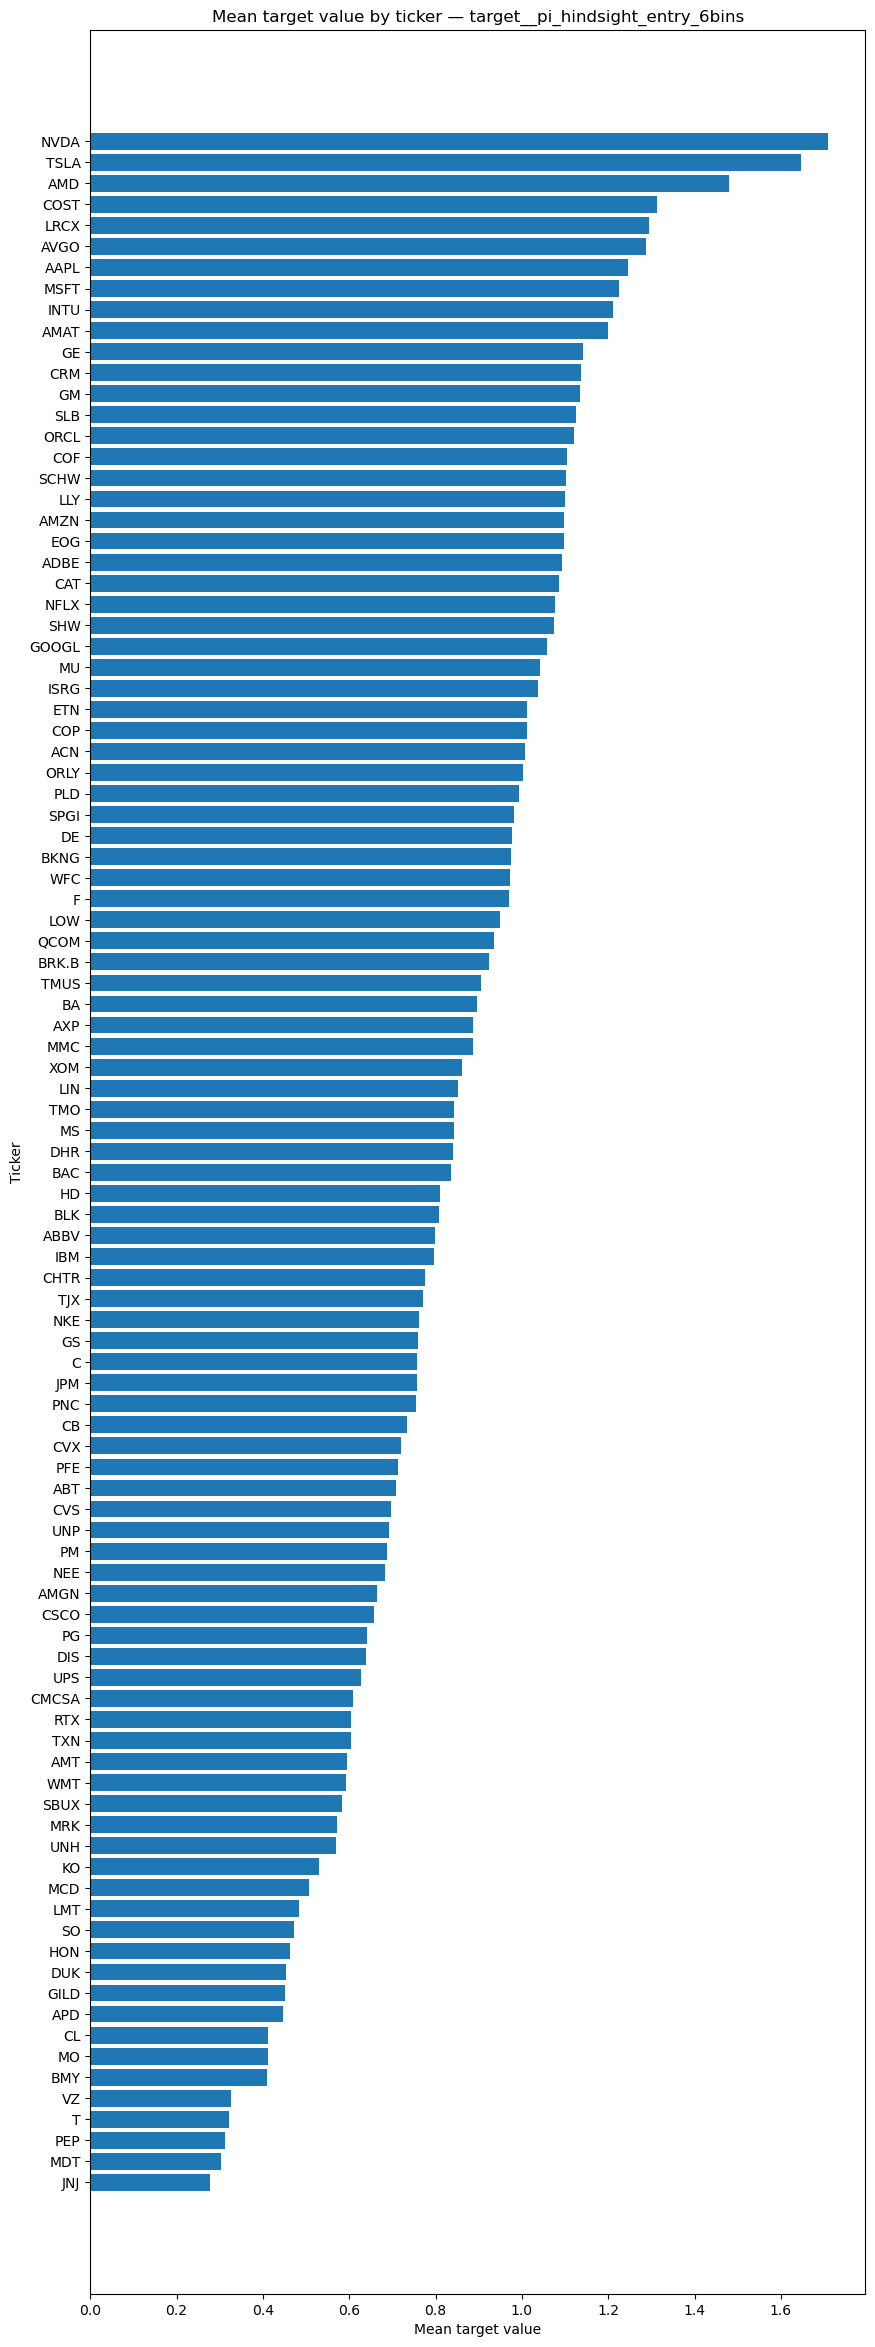

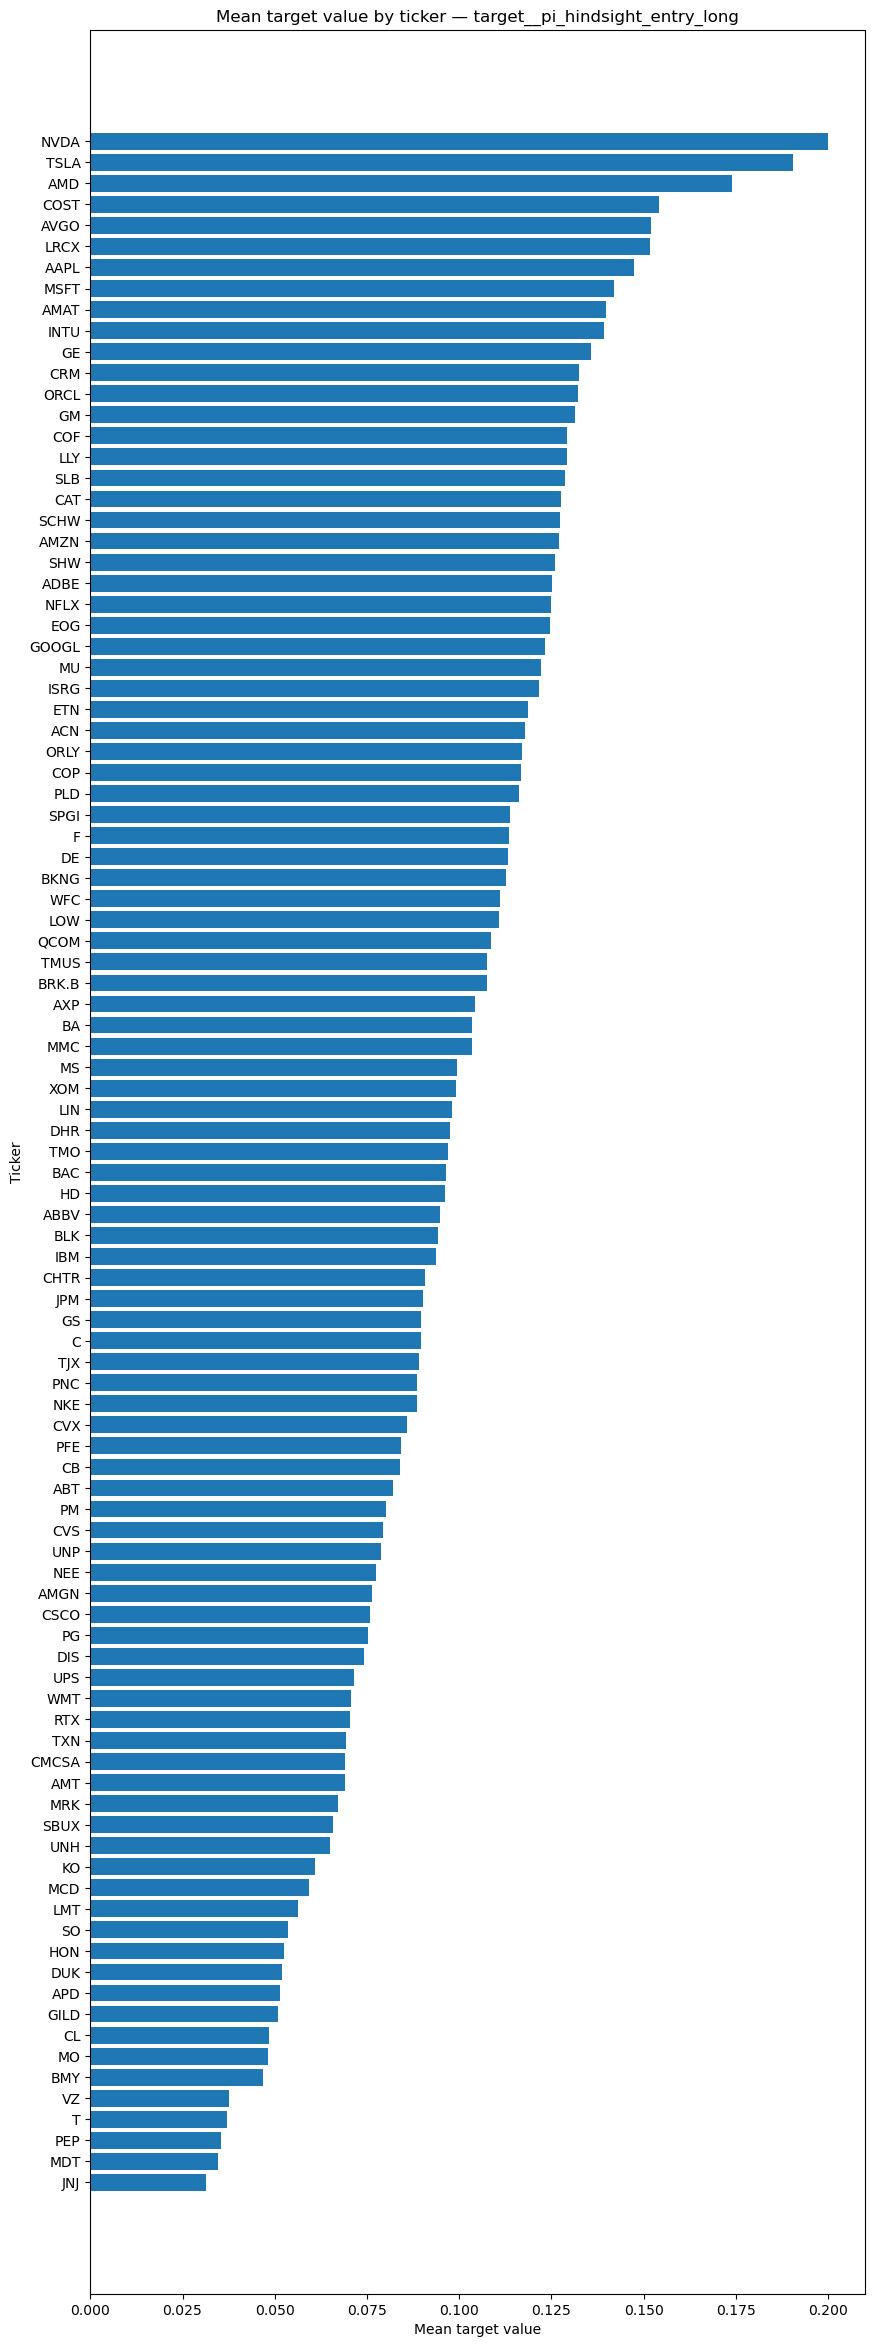

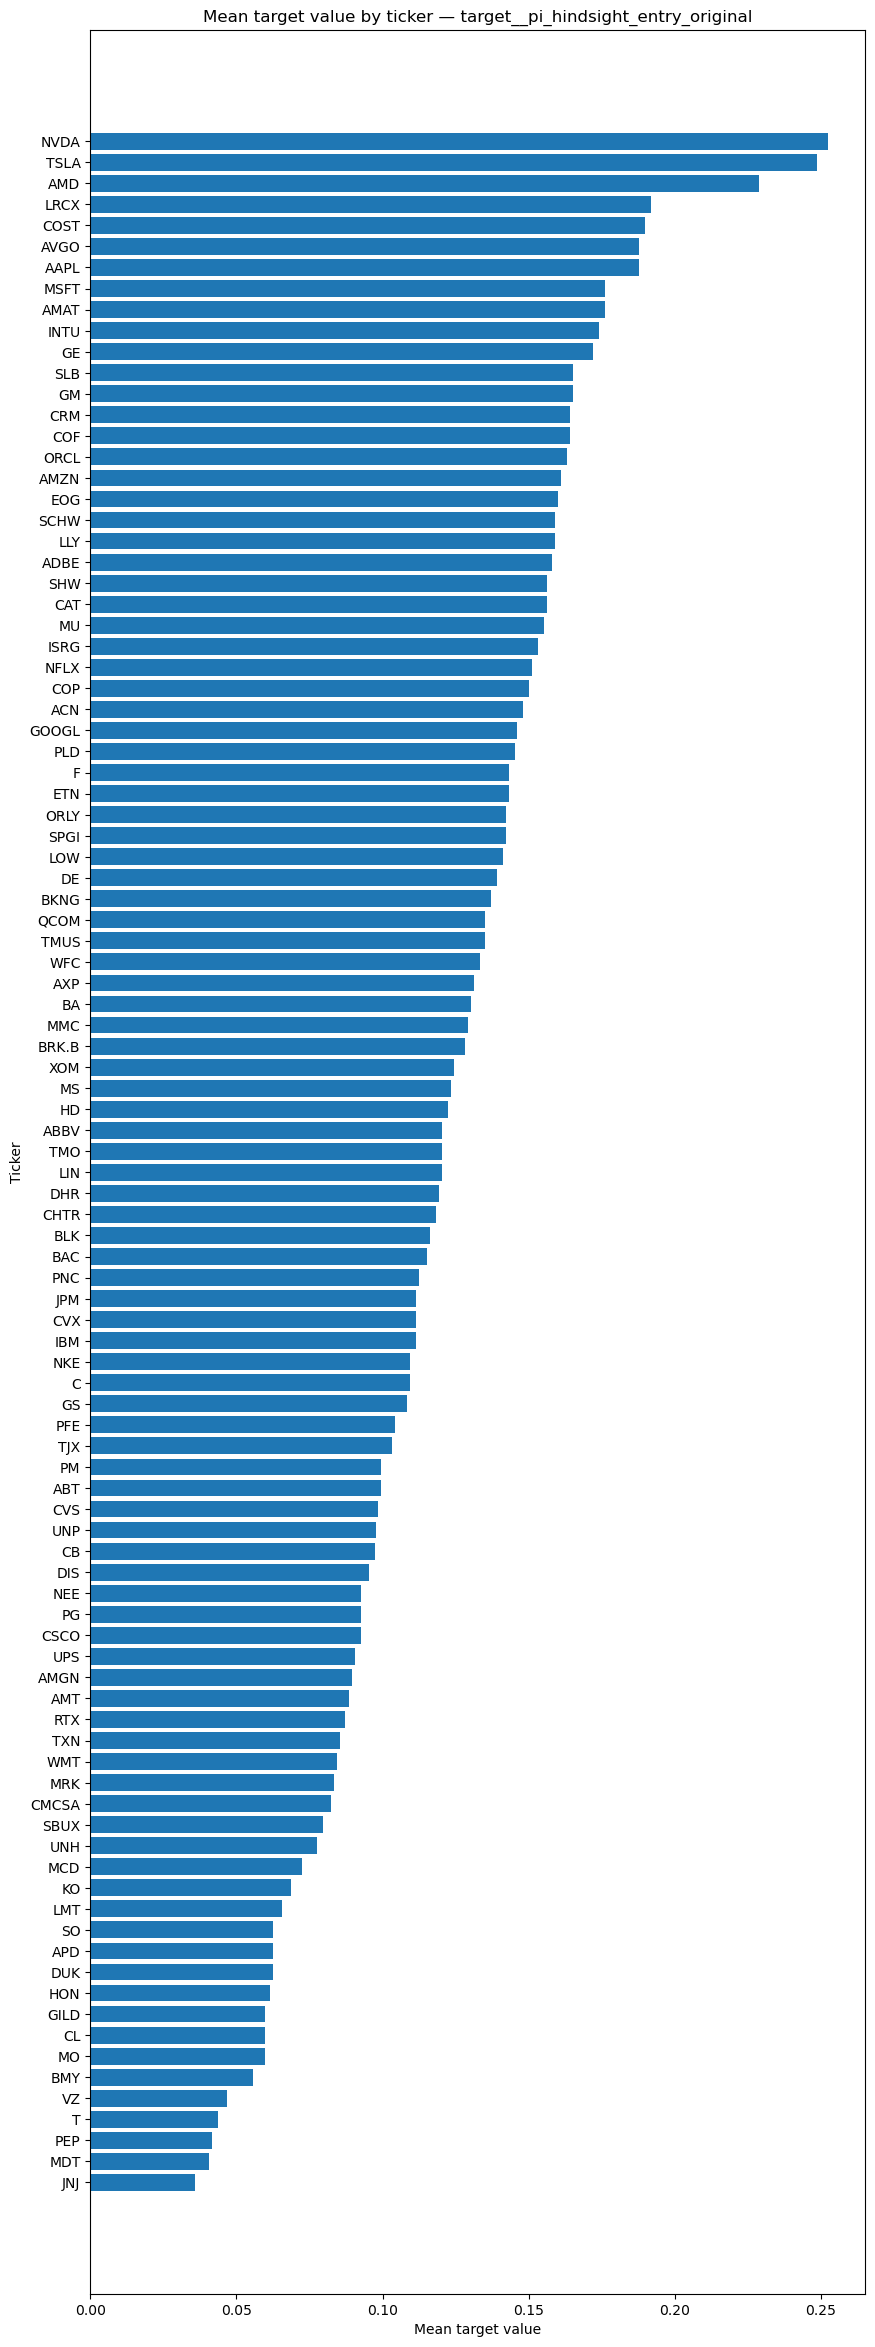

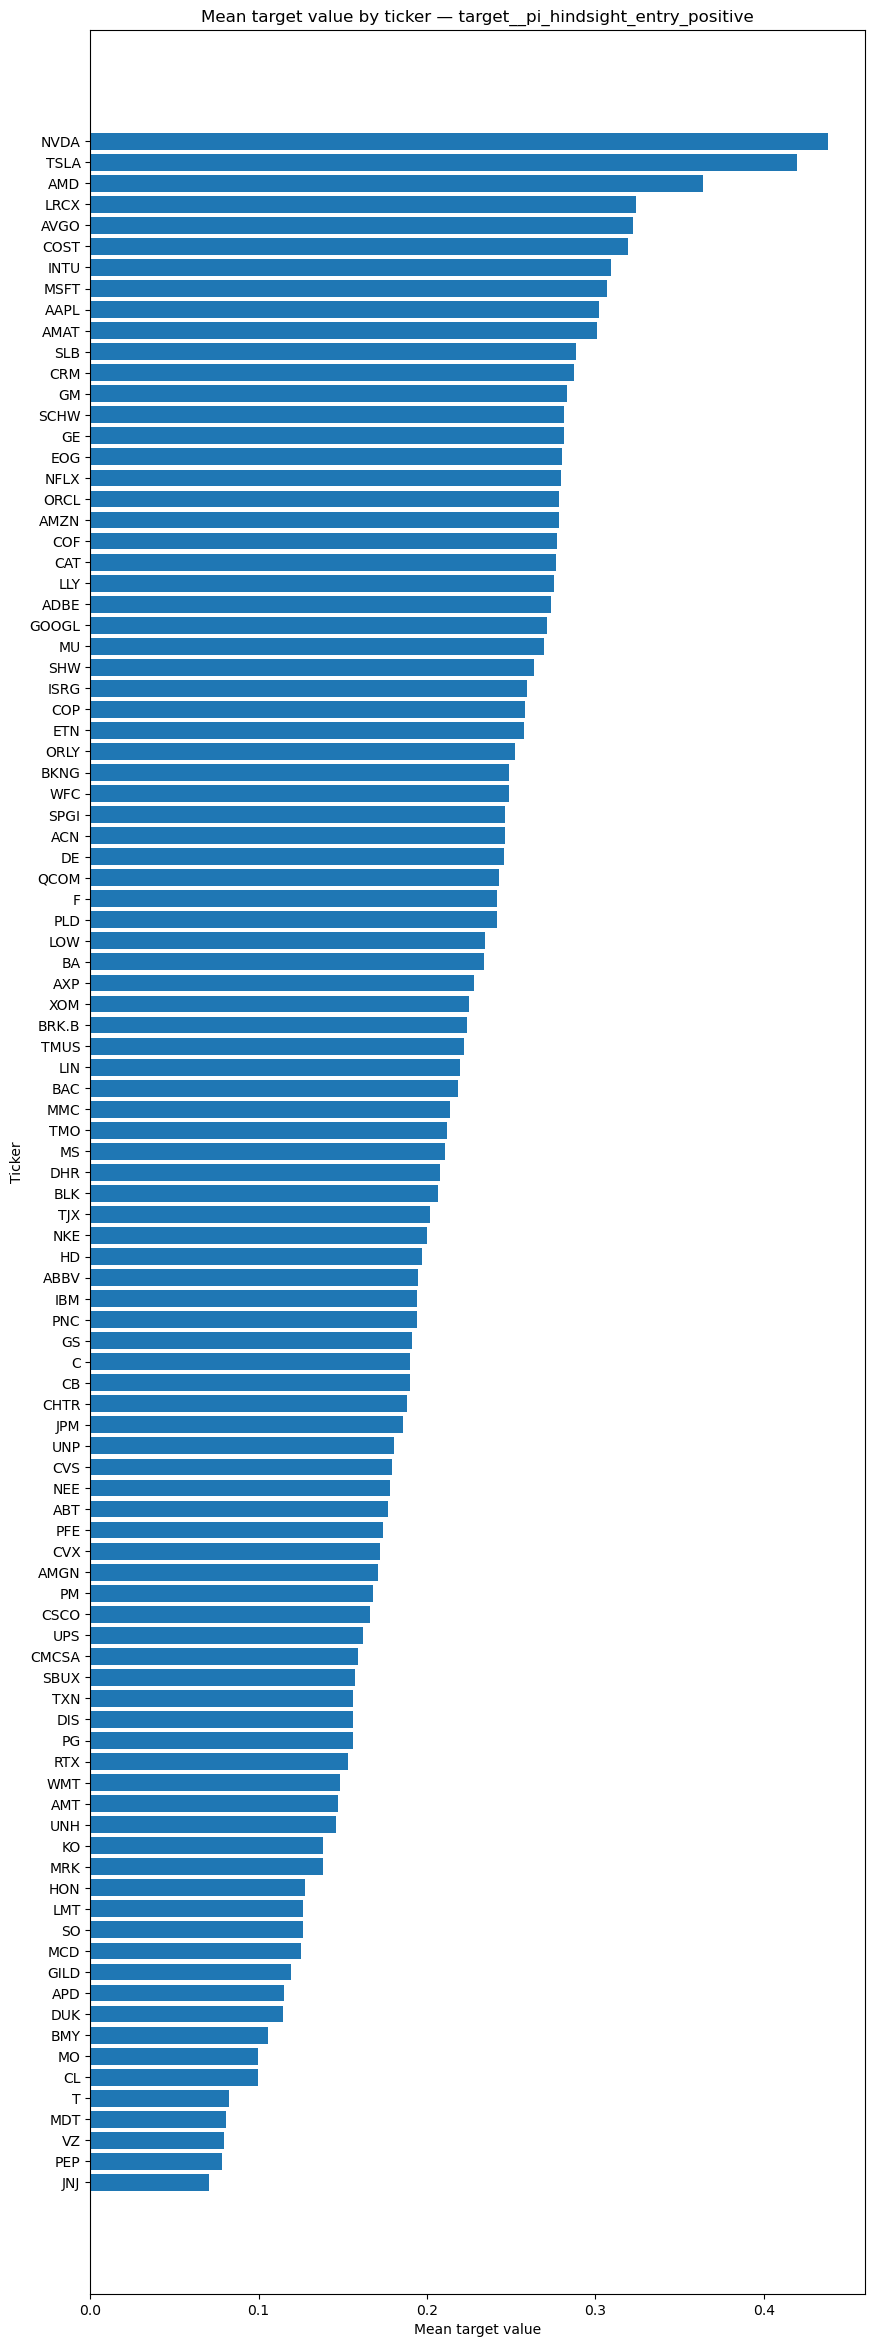

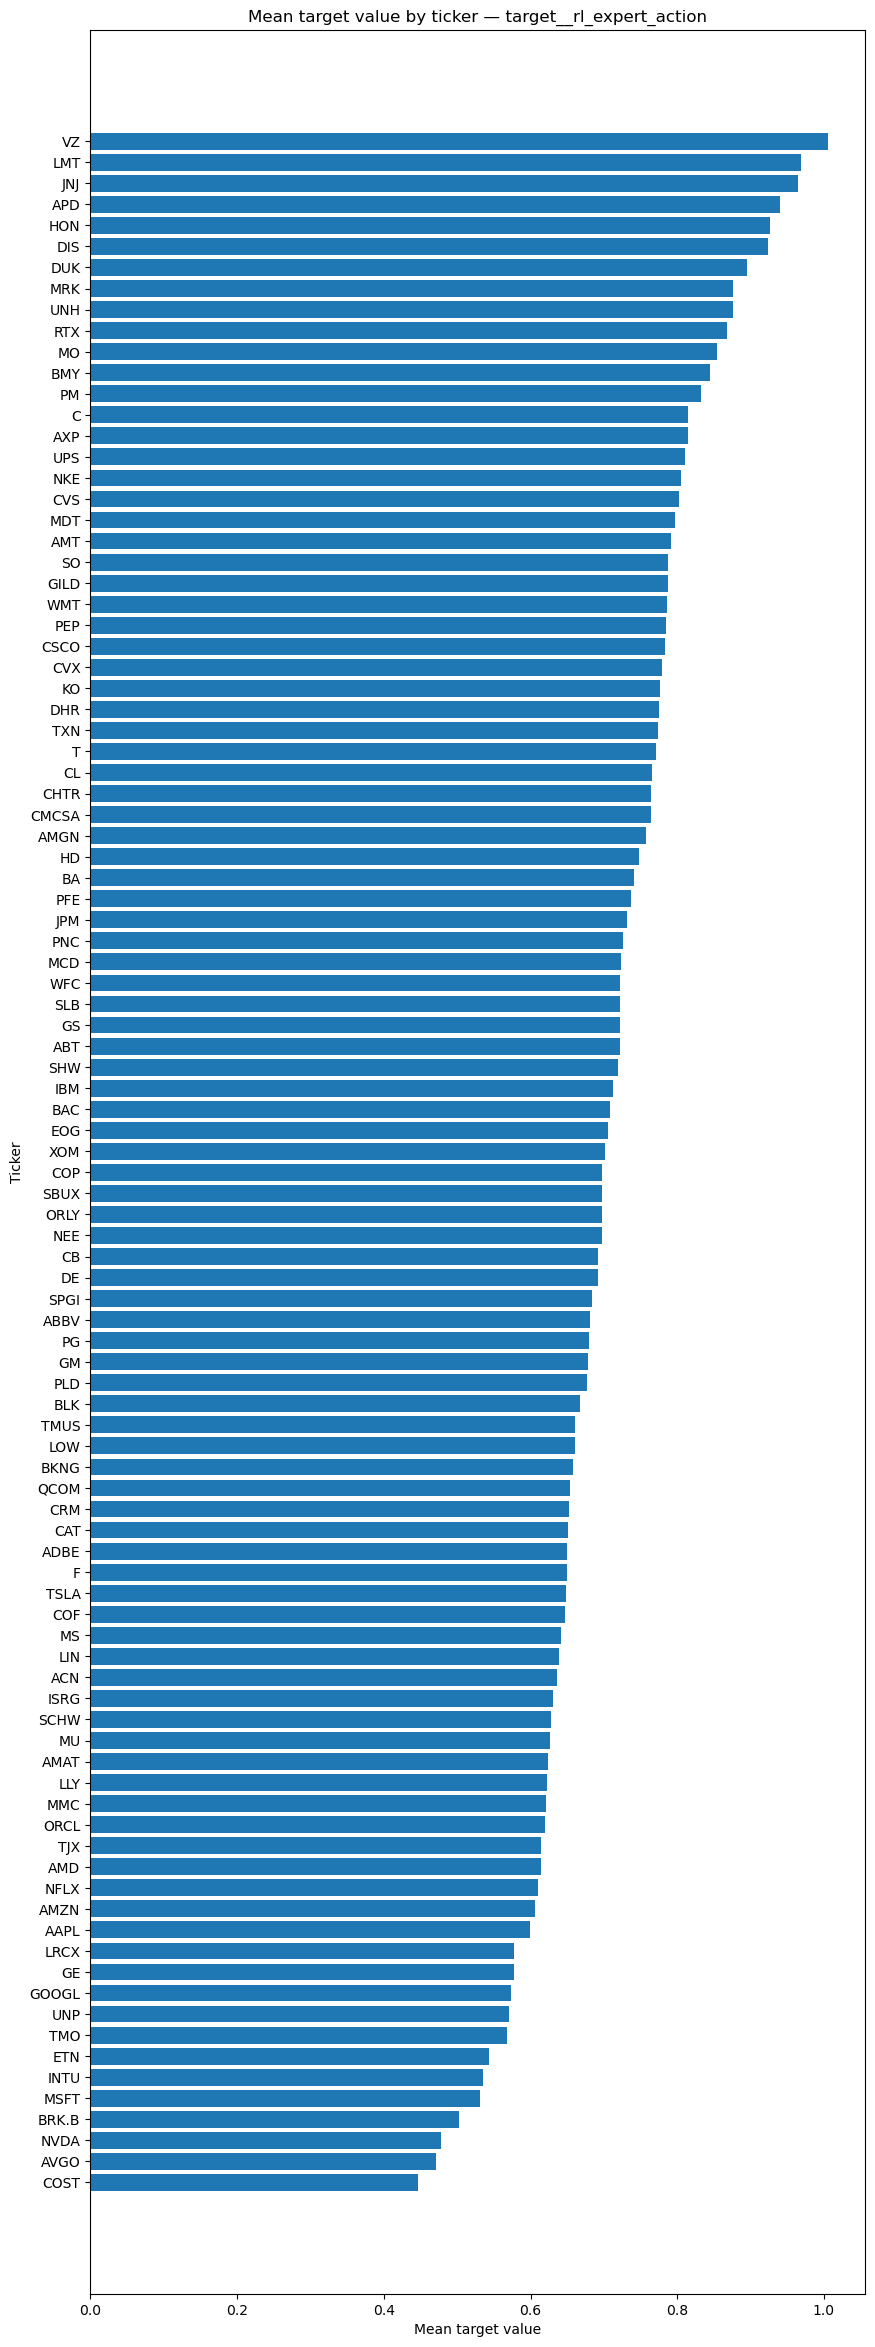

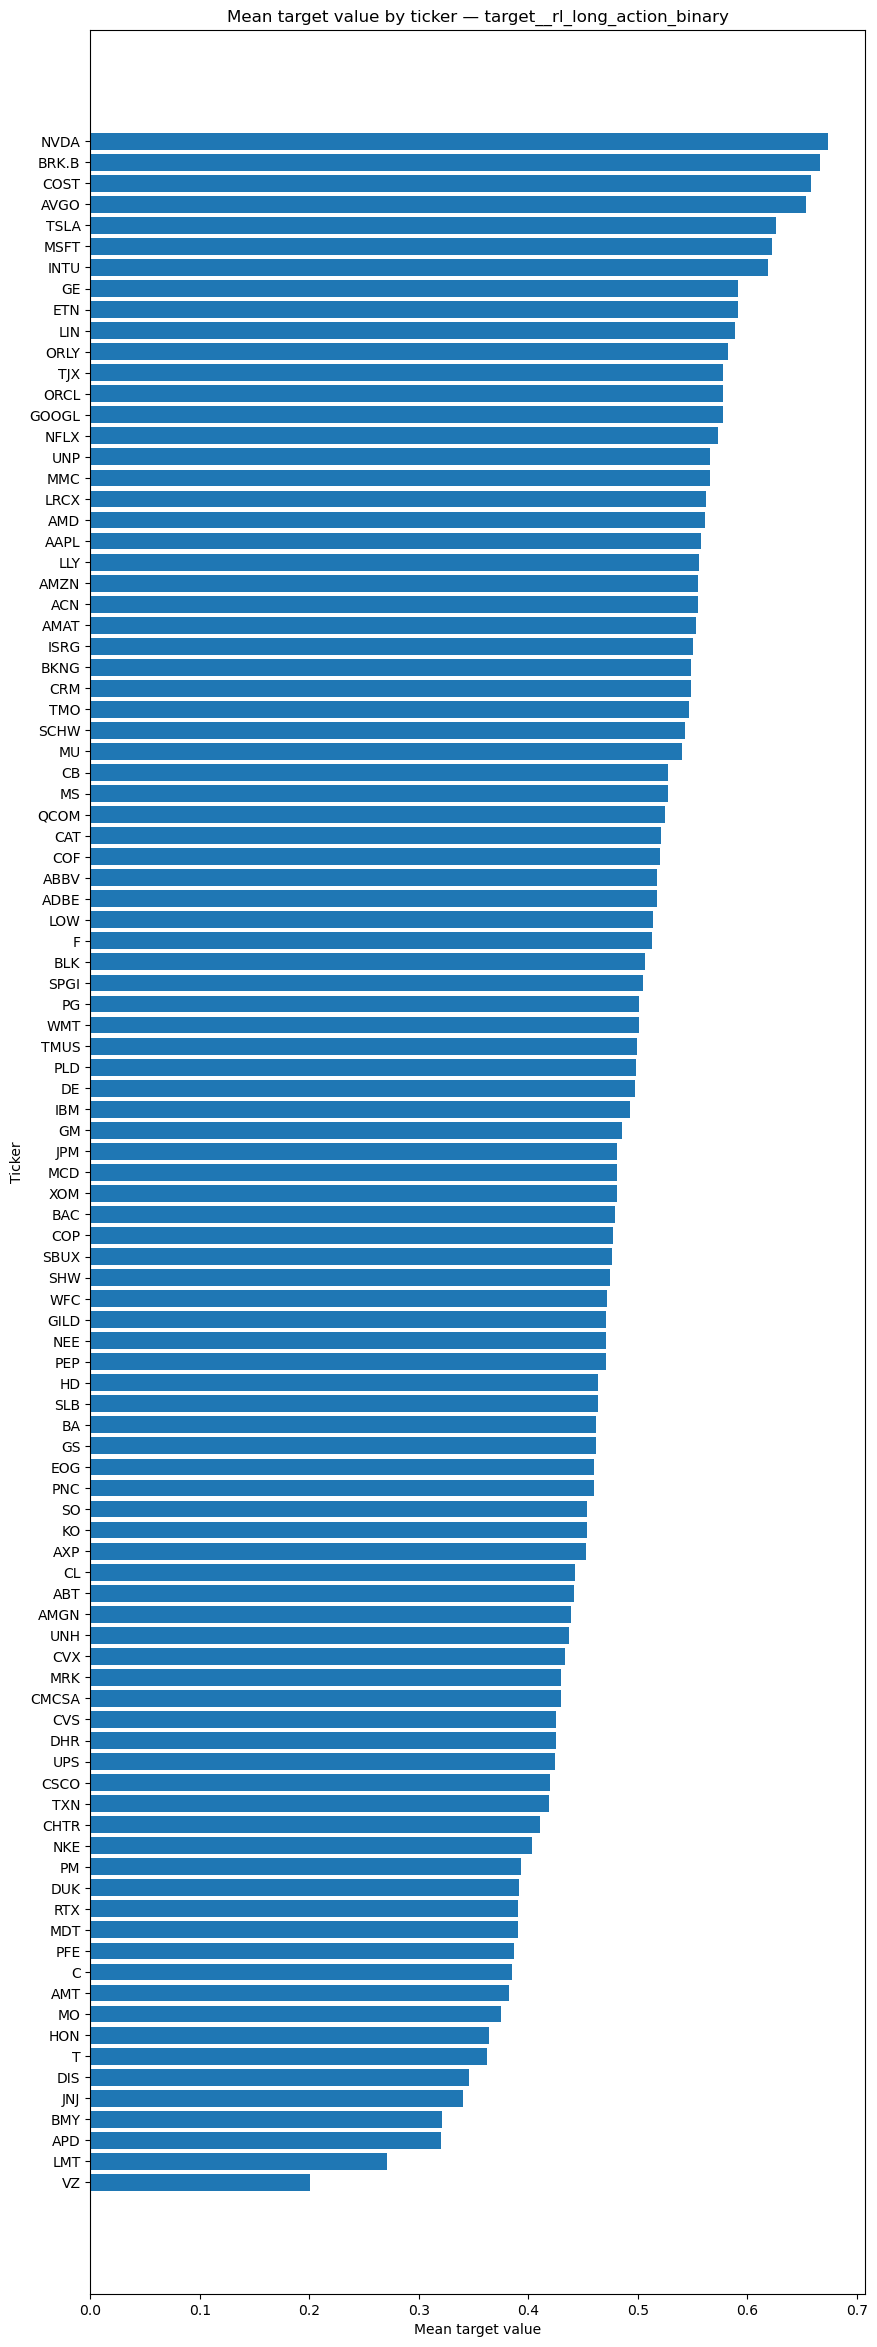

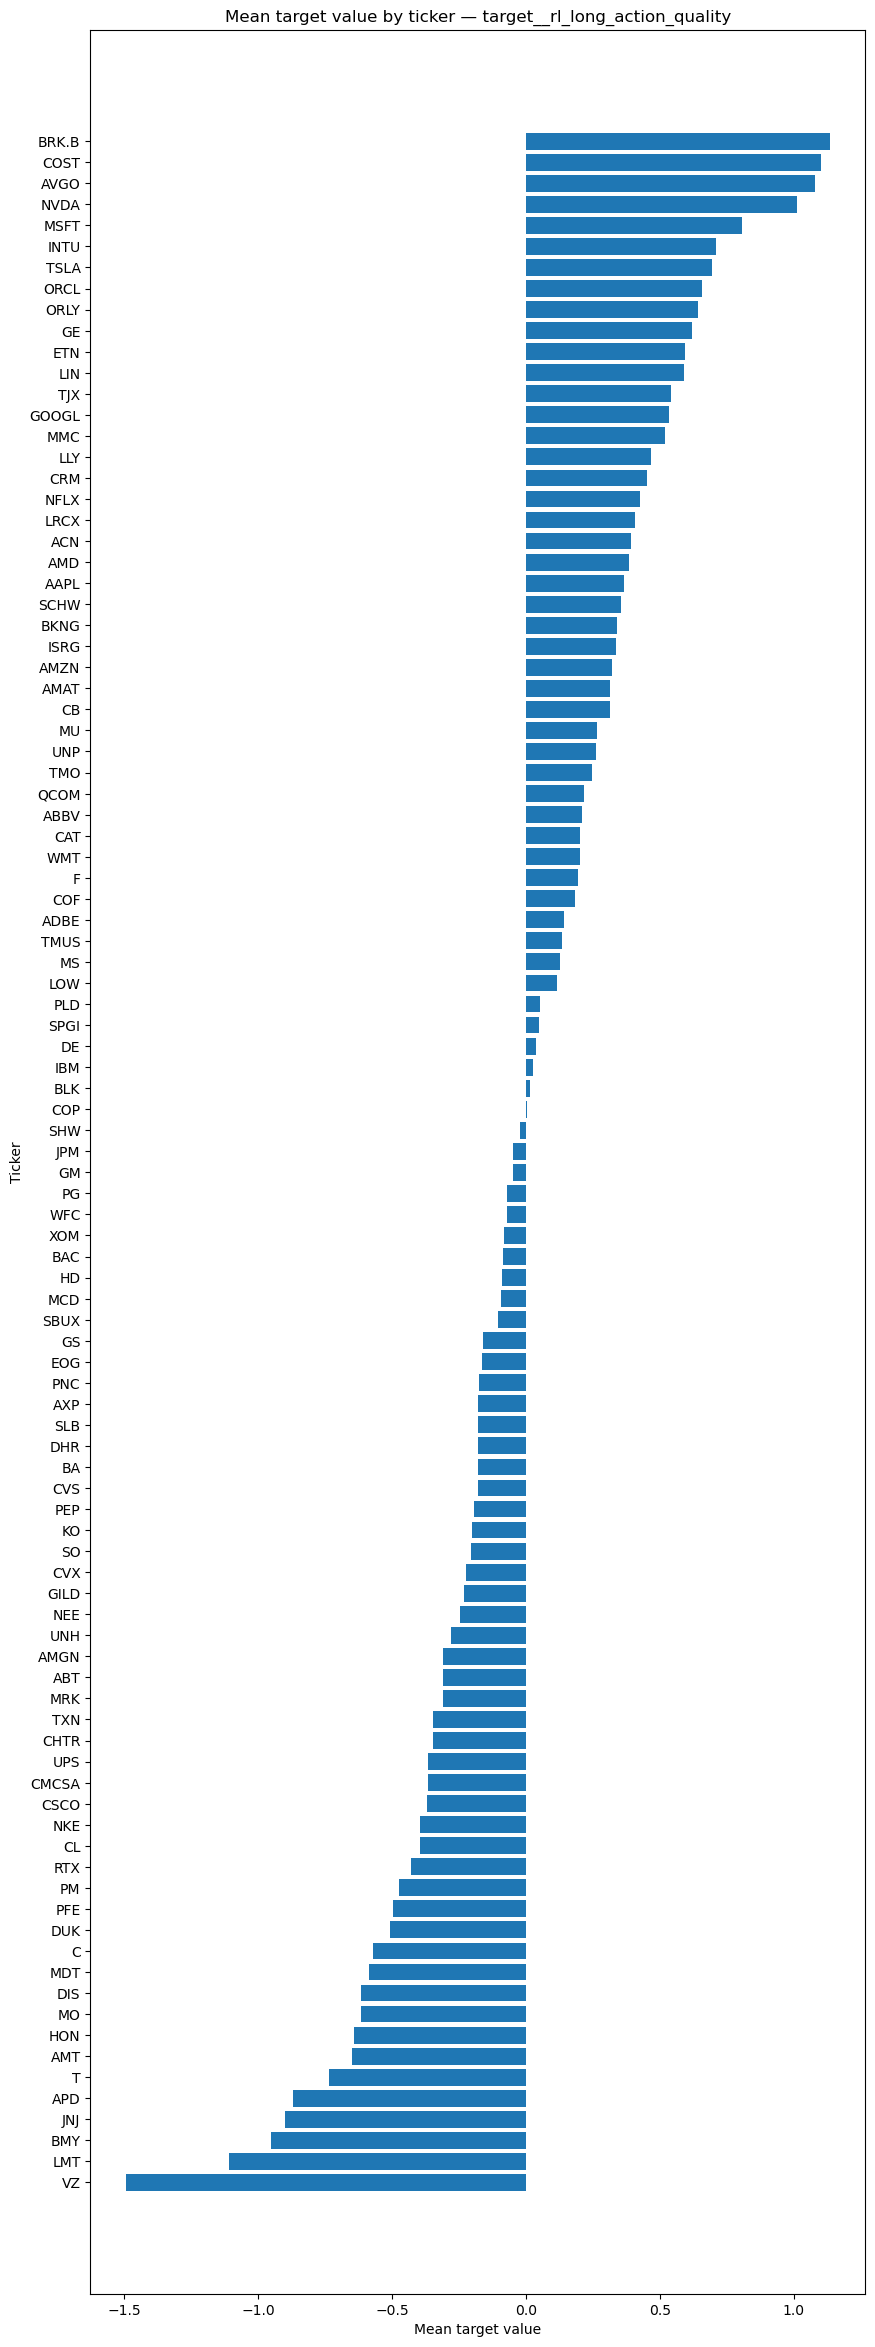

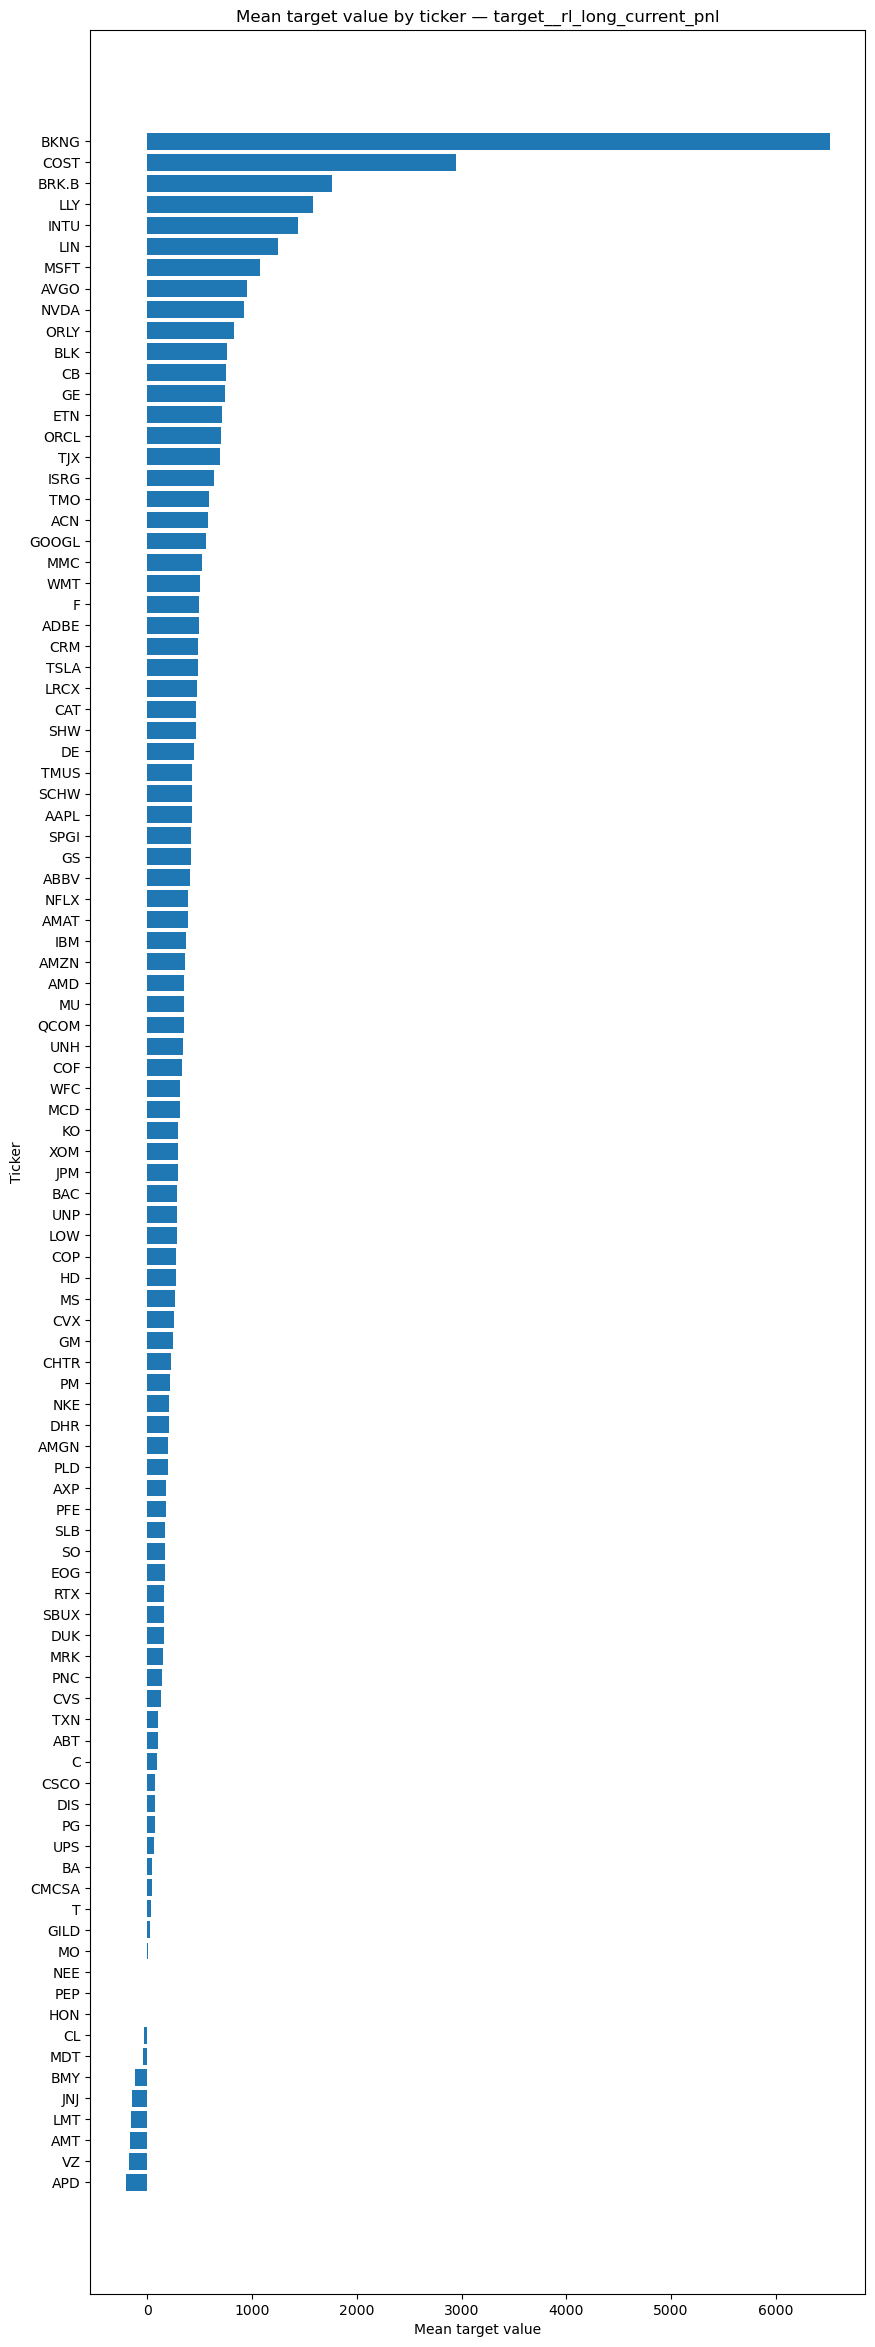

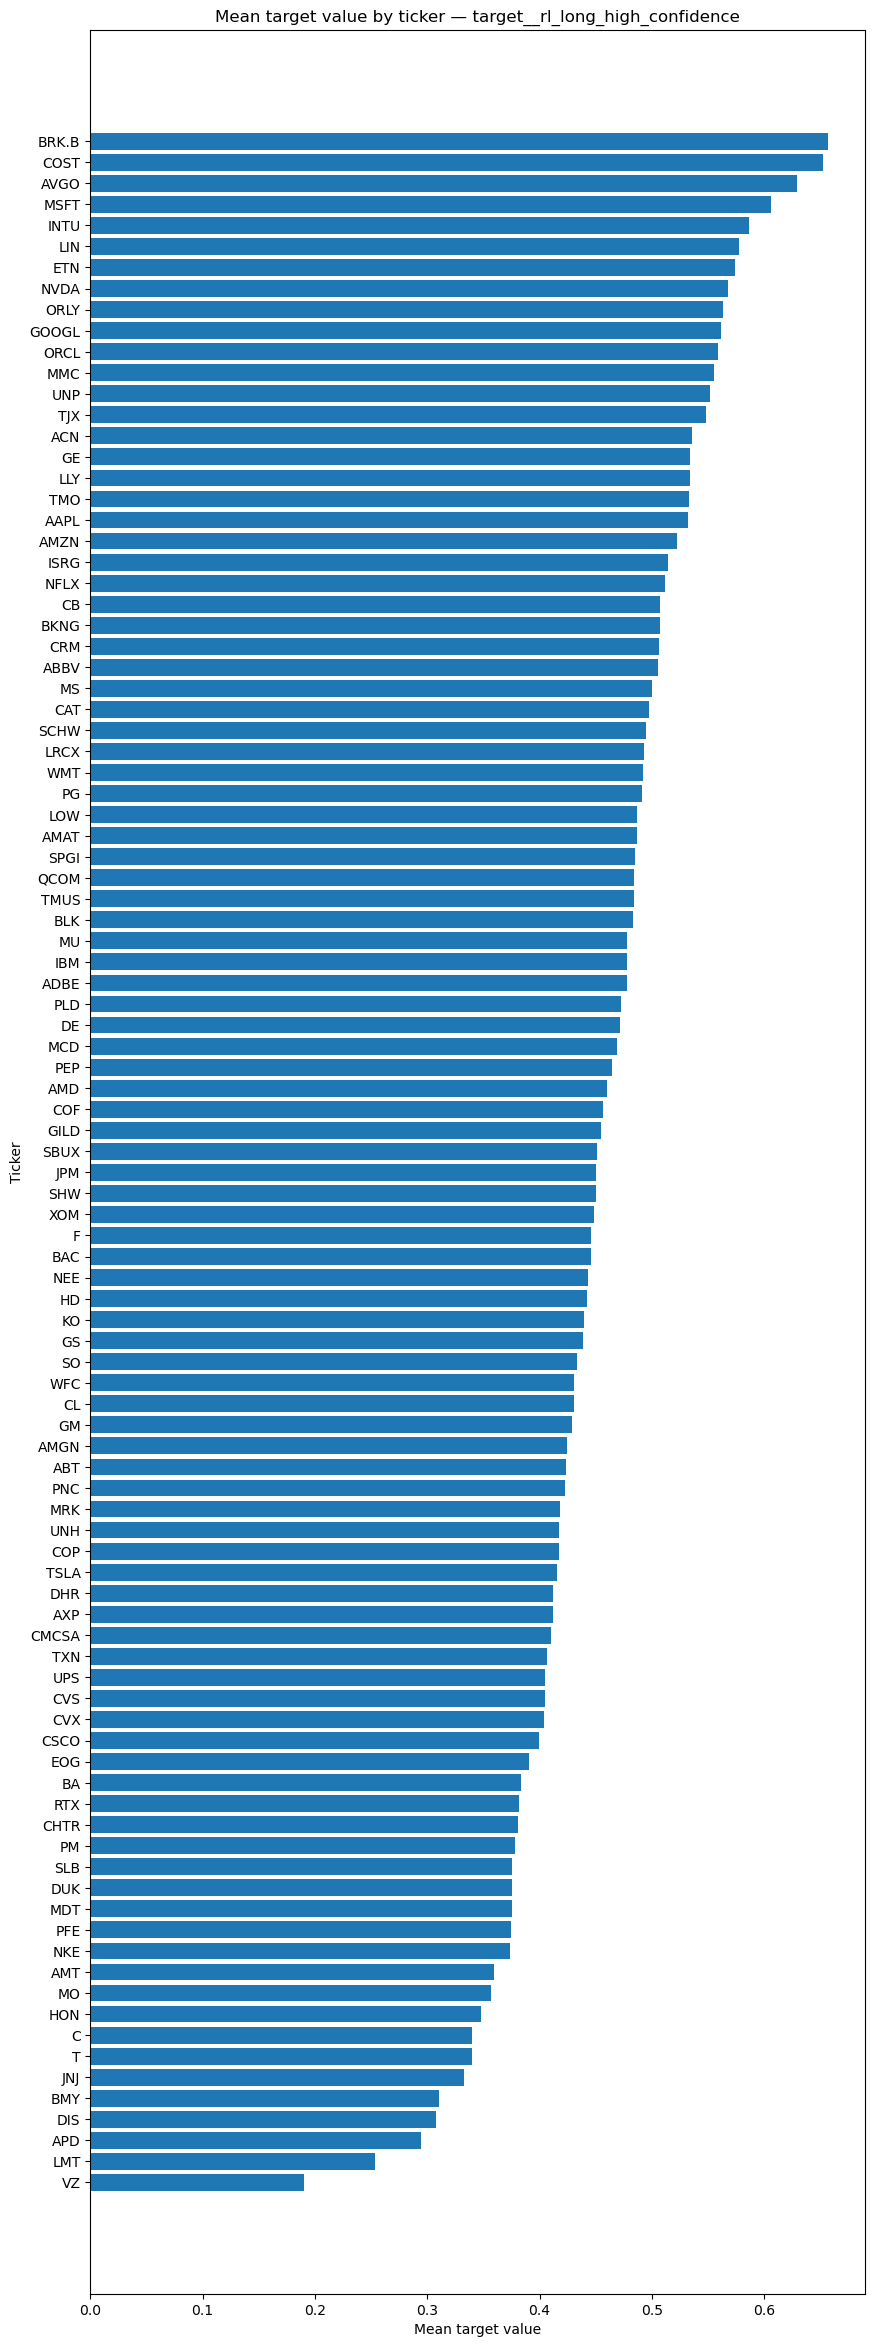

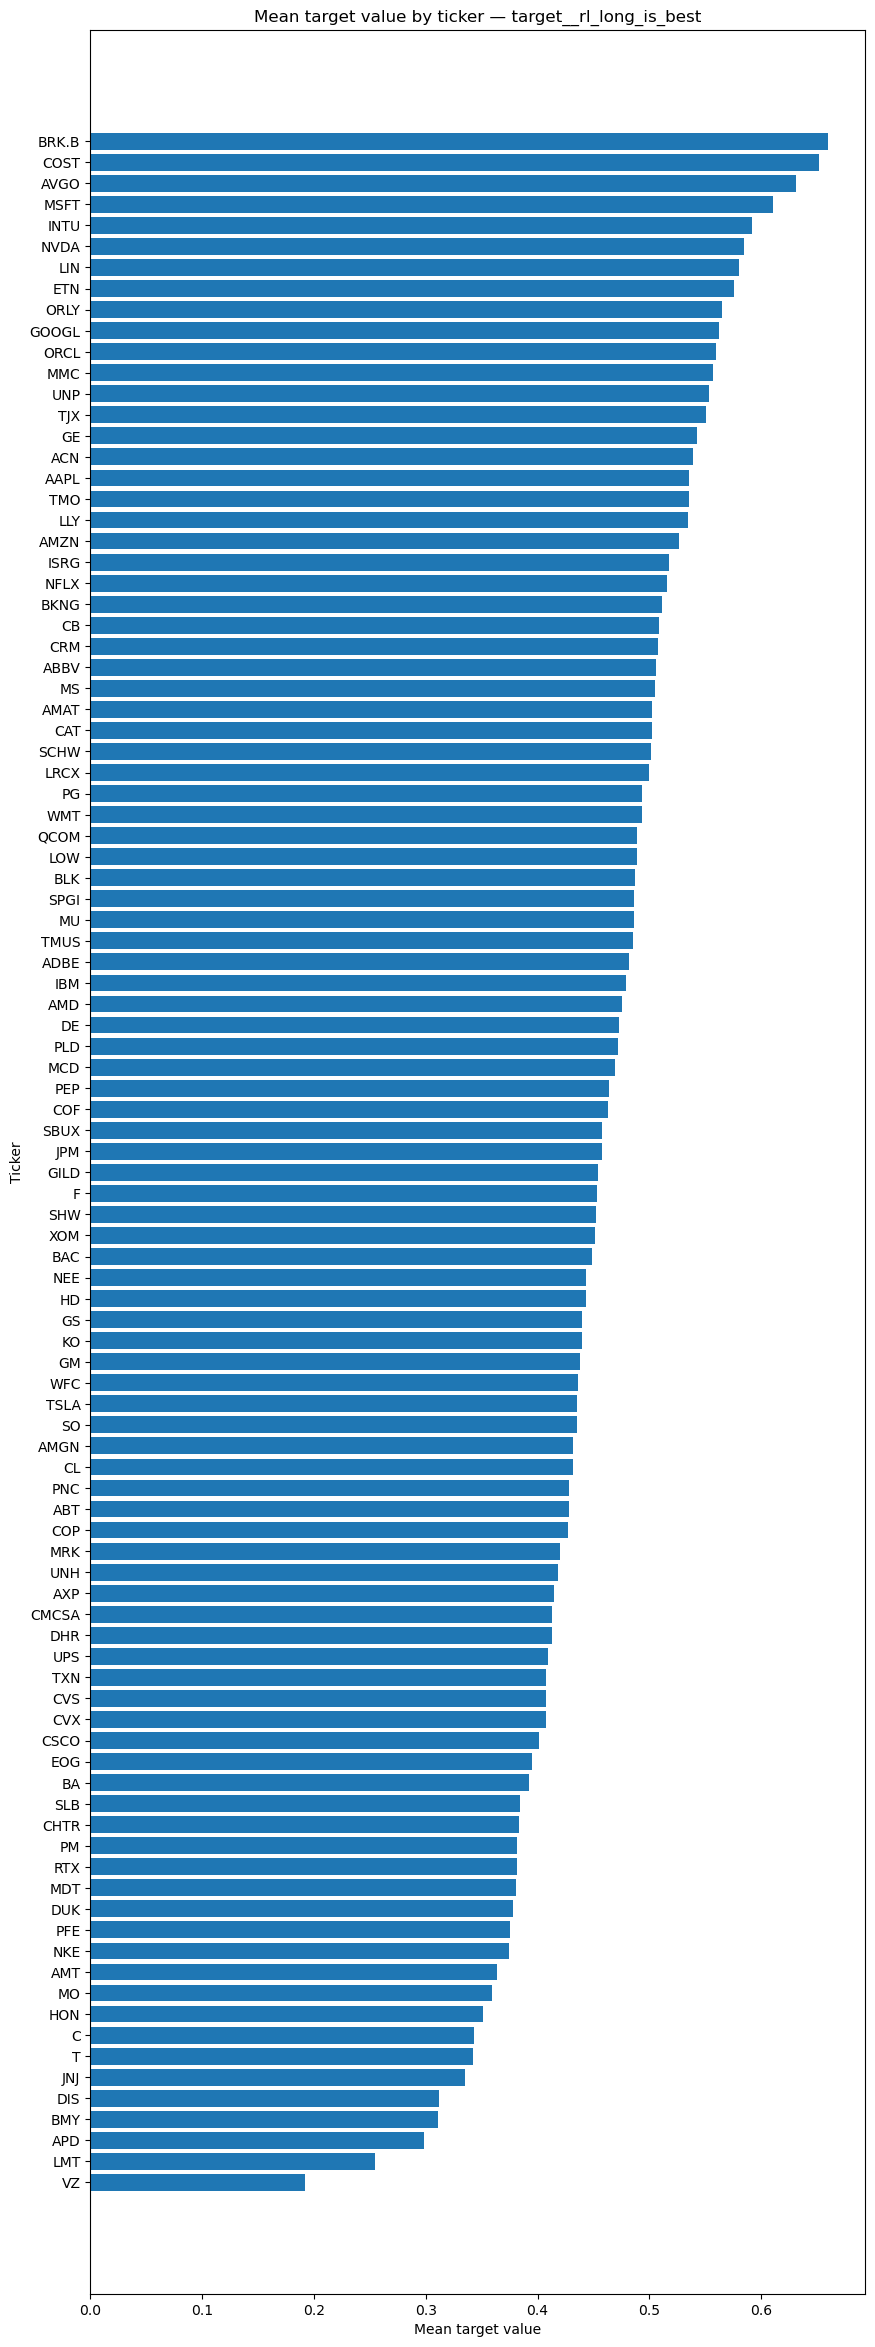

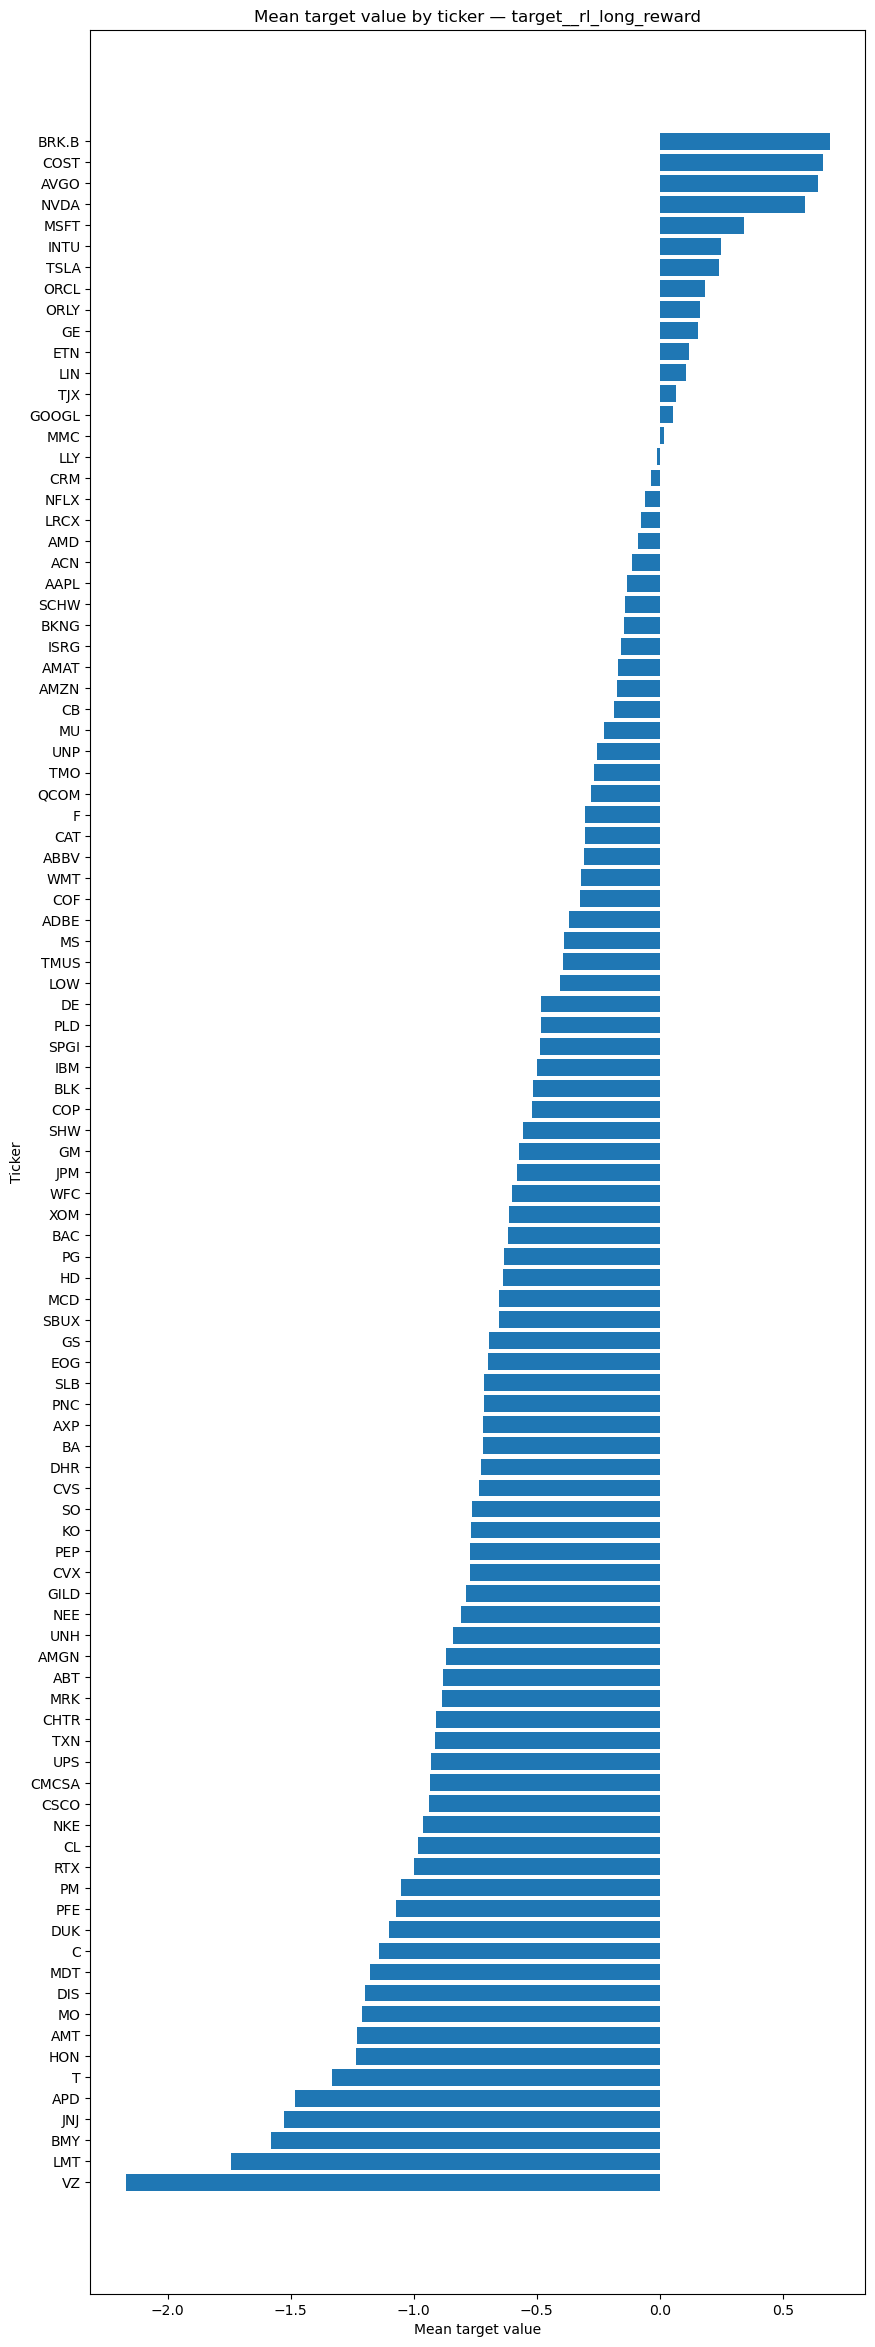

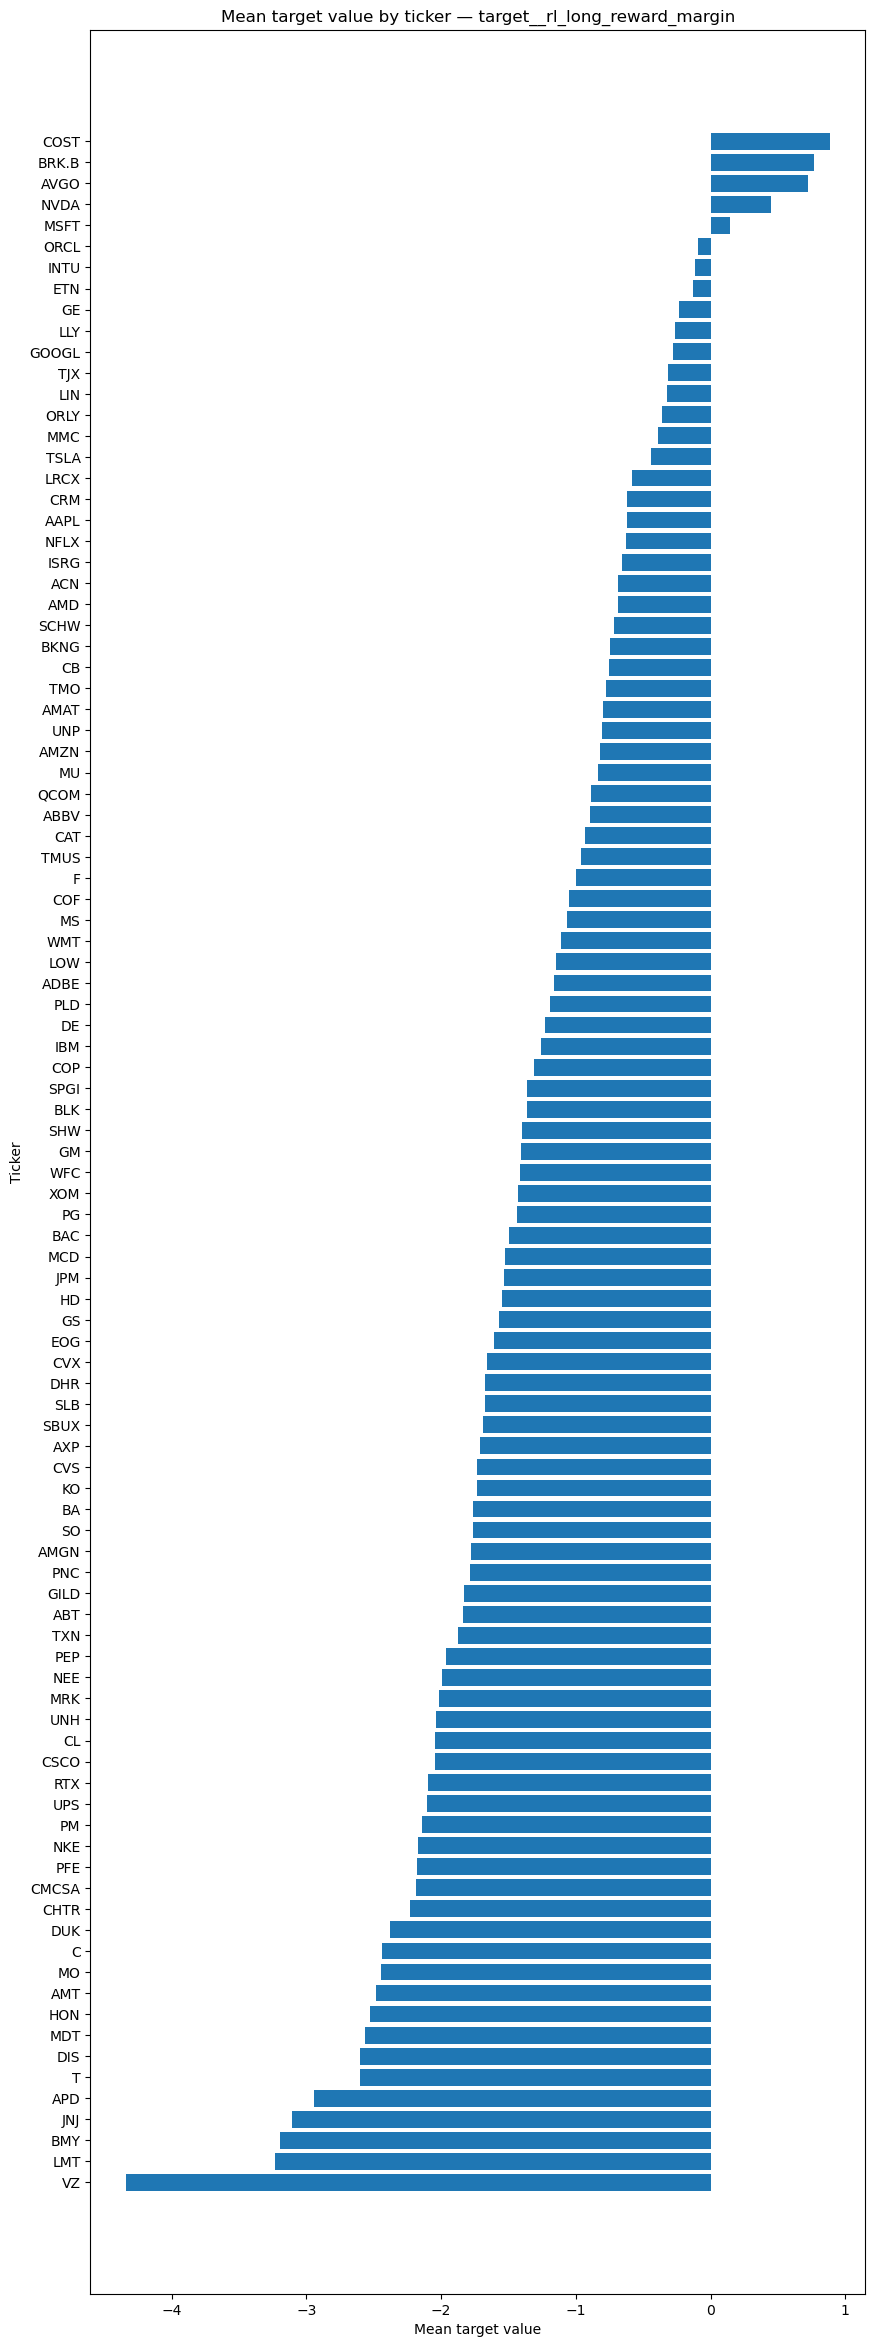

In [22]:
target_ticker_rows = []

for column in available_target_columns:
    temporary = df_train[[TICKER_COL, column]].copy()
    temporary[column] = pd.to_numeric(
        temporary[column],
        errors="coerce"
    )
    temporary = temporary.dropna(subset=[TICKER_COL, column])

    ticker_summary = (
        temporary.groupby(TICKER_COL)[column]
        .agg(
            n_obs="size",
            mean="mean",
            std="std",
            min="min",
            median="median",
            max="max"
        )
        .reset_index()
    )

    ticker_rates = (
        temporary.groupby(TICKER_COL)[column]
        .apply(
            lambda values: pd.Series({
                "zero_rate": (values == 0).mean(),
                "positive_rate": (values > 0).mean(),
                "negative_rate": (values < 0).mean()
            })
        )
        .unstack()
        .reset_index()
    )

    ticker_summary = ticker_summary.merge(
        ticker_rates,
        on=TICKER_COL,
        how="left"
    )
    ticker_summary.insert(0, "target", column)
    target_ticker_rows.append(ticker_summary)

target_by_ticker = (
    pd.concat(target_ticker_rows, ignore_index=True)
    if target_ticker_rows
    else pd.DataFrame()
)

export_table("target_summary_by_ticker", target_by_ticker)

for column in available_target_columns:
    plot_data = (
        target_by_ticker[
            target_by_ticker["target"] == column
        ]
        .sort_values("mean")
    )

    if plot_data.empty:
        continue

    plt.figure(figsize=(10, max(5, 0.3 * len(plot_data))))
    plt.barh(
        plot_data[TICKER_COL].astype(str),
        plot_data["mean"]
    )
    plt.title(f"Mean target value by ticker — {column}")
    plt.xlabel("Mean target value")
    plt.ylabel("Ticker")
    save_current_figure(f"target_mean_by_ticker_{column}")
    plt.show()

## 14. Feature–target rank correlations

In [23]:
feature_target_rows = []

correlation_features = final_feature_b_features.copy()

for target_column in available_target_columns:
    target_values = pd.to_numeric(
        df_train[target_column],
        errors="coerce"
    )

    for feature_column in correlation_features:
        feature_values = pd.to_numeric(
            df_train[feature_column],
            errors="coerce"
        )

        valid = feature_values.notna() & target_values.notna()

        if valid.sum() < 30:
            correlation = np.nan
        else:
            correlation = feature_values[valid].corr(
                target_values[valid],
                method="spearman"
            )

        feature_target_rows.append({
            "target": target_column,
            "feature": feature_column,
            "n_complete": int(valid.sum()),
            "spearman": correlation,
            "absolute_spearman": (
                abs(correlation)
                if pd.notna(correlation)
                else np.nan
            )
        })

feature_target_correlations = pd.DataFrame(feature_target_rows)

export_table(
    "feature_target_spearman_correlations",
    feature_target_correlations,
    display_table=False
)

top_feature_target_correlations = (
    feature_target_correlations
    .sort_values(
        ["target", "absolute_spearman"],
        ascending=[True, False]
    )
    .groupby("target", group_keys=False)
    .head(20)
)

export_table(
    "top_feature_target_spearman_correlations",
    top_feature_target_correlations
)

,target,feature,n_complete,spearman,absolute_spearman
268,target__pi_hindsight_entry_6bins,feature__volatility_trailing_1m,98419,0.188698,0.188698
2,target__pi_hindsight_entry_6bins,feature__avg_daily_turnover,98419,0.122631,0.122631
256,target__pi_hindsight_entry_6bins,feature__regime_vix_percentile_1y,98419,0.112936,0.112936
244,target__pi_hindsight_entry_6bins,feature__price_vs_52w_high,98419,-0.098657,0.098657
248,target__pi_hindsight_entry_6bins,feature__regime_cpi_yoy,98419,-0.096856,0.096856
...,...,...,...,...,...
3012,target__rl_long_reward_margin,feature__b_days_payables_outstanding_iqr,98419,-0.071119,0.071119
3064,target__rl_long_reward_margin,feature__b_quick_ratio_delta_to_p50,98419,0.070392,0.070392
3106,target__rl_long_reward_margin,feature__cash_to_debt,98419,0.070118,0.070118
3116,target__rl_long_reward_margin,feature__daily_enterprise_value_including_rest...,98419,-0.069158,0.069158


,target,feature,n_complete,spearman,absolute_spearman
268,target__pi_hindsight_entry_6bins,feature__volatility_trailing_1m,98419,0.188698,0.188698
2,target__pi_hindsight_entry_6bins,feature__avg_daily_turnover,98419,0.122631,0.122631
256,target__pi_hindsight_entry_6bins,feature__regime_vix_percentile_1y,98419,0.112936,0.112936
244,target__pi_hindsight_entry_6bins,feature__price_vs_52w_high,98419,-0.098657,0.098657
248,target__pi_hindsight_entry_6bins,feature__regime_cpi_yoy,98419,-0.096856,0.096856
...,...,...,...,...,...
3012,target__rl_long_reward_margin,feature__b_days_payables_outstanding_iqr,98419,-0.071119,0.071119
3064,target__rl_long_reward_margin,feature__b_quick_ratio_delta_to_p50,98419,0.070392,0.070392
3106,target__rl_long_reward_margin,feature__cash_to_debt,98419,0.070118,0.070118
3116,target__rl_long_reward_margin,feature__daily_enterprise_value_including_rest...,98419,-0.069158,0.069158


## 4. Final feature set for modelling (`FINAL_FEATURE_B`)

The sanity-checked final Project B features (constants dropped) become the single modelling feature set used by **every** model and target.

In [24]:
# Drop constant / all-missing columns; this is the ONE feature set used everywhere.
FINAL_FEATURE_B = [c for c in final_feature_b_available
                   if c in all_data.columns and all_data[c].nunique(dropna=True) > 1]
print('final_feature_b requested:', len(final_feature_b_available),
      '| usable after dropping constants:', len(FINAL_FEATURE_B))

final_feature_b requested: 270 | usable after dropping constants: 268


In [25]:
EXCLUDE_COLUMNS = {SPLIT_COL, YEAR_COL, DATE_COL, TICKER_COL, SIC2_COL}


def read_feature_file(feature_file):
    if feature_file is None:
        return []
    path = Path(feature_file)
    if not path.exists():
        print(f'Feature file not found: {path}. Falling back to automatic numeric features.')
        return []
    raw = [line.strip() for line in path.open('r', encoding='utf-8') if line.strip() and not line.strip().startswith('#')]
    return [col if col.startswith('feature__') else f'feature__{col}' for col in raw]


def get_numeric_feature_candidates(df):
    numeric_cols = df.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    out = []
    for col in numeric_cols:
        if col in EXCLUDE_COLUMNS:
            continue
        if col.startswith('label__') or col.startswith('target__') or col.startswith('attr__'):
            continue
        if col.startswith('feature__'):
            out.append(col)
    return sorted(set(out))


def select_features_by_keywords(all_features, include_keywords=None, exclude_keywords=None):
    include_keywords = include_keywords or []
    exclude_keywords = exclude_keywords or []
    out = []
    for col in all_features:
        c = col.lower()
        include_ok = True if not include_keywords else any(k.lower() in c for k in include_keywords)
        exclude_ok = not any(k.lower() in c for k in exclude_keywords)
        if include_ok and exclude_ok:
            out.append(col)
    return sorted(set(out))


def build_feature_sets(all_data, config=DATASET_CONFIG):
    auto_numeric = get_numeric_feature_candidates(all_data)
    project_b_raw = read_feature_file(config.get('project_b_feature_file'))
    project_b = [c for c in project_b_raw if c in all_data.columns]
    if len(project_b) == 0:
        project_b = auto_numeric.copy()

    feature_sets = {
        'final_feature_b': project_b,
        'combined_all_numeric_features': auto_numeric,
        'fundamentals_only': select_features_by_keywords(auto_numeric, ['fund', 'asset', 'liabil', 'equity', 'cash', 'debt', 'revenue', 'income', 'earn', 'profit', 'margin', 'eps', 'book', 'balance', 'report', 'quarter', 'ttm', 'filing']),
        'daily_valuation_only': select_features_by_keywords(auto_numeric, ['pe', 'pb', 'ps', 'ev', 'valuation', 'market_cap', 'price_to', 'yield', 'dividend', 'multiple']),
        'momentum_volatility_only': select_features_by_keywords(auto_numeric, ['return', 'ret', 'momentum', 'mom', 'vol', 'volatility', 'atr', 'rsi', 'macd', 'sma', 'ema', 'drawdown', 'trend', 'beta']),
        'macro_regime_only': select_features_by_keywords(auto_numeric, ['macro', 'regime', 'inflation', 'vix', 'yield_curve', 'rate', 'treasury', 'credit', 'index', 'sector', 'market']),
        'algorithmic_signals_only': select_features_by_keywords(auto_numeric, ['signal', 'alpha', 'score', 'rank', 'swarm', 'algo', 'model', 'entry', 'exit', 'confidence'], ['label', 'target']),
    }
    feature_sets = {k: v for k, v in feature_sets.items() if len(v) > 0}
    summary = pd.DataFrame([{'feature_set': k, 'n_features': len(v)} for k, v in feature_sets.items()])
    register_table('feature_set_summary', summary)
    return feature_sets

FEATURE_SET_CONFIGS = build_feature_sets(all_data, DATASET_CONFIG)

In [26]:
# Override: force the single 'final_feature_b' set for all experiments.
FEATURE_SET_CONFIGS = {'final_feature_b': FINAL_FEATURE_B}
register_table('feature_set_summary',
               pd.DataFrame([{'feature_set': 'final_feature_b', 'n_features': len(FINAL_FEATURE_B)}]))
FEATURE_SET_CONFIGS

{'final_feature_b': ['feature__accruals_to_assets',
  'feature__asset_turnover',
  'feature__avg_daily_turnover',
  'feature__b_asset_turnover_excess_over_p99',
  'feature__b_asset_turnover_industry_rank_score',
  'feature__b_asset_turnover_iqr',
  'feature__b_asset_turnover_is_above_p90',
  'feature__b_asset_turnover_is_below_p10',
  'feature__b_asset_turnover_shortfall_below_p1',
  'feature__b_assets_to_equity_excess_over_p99',
  'feature__b_assets_to_equity_iqr',
  'feature__b_assets_to_equity_is_above_p90',
  'feature__b_assets_to_equity_is_below_p10',
  'feature__b_assets_to_equity_shortfall_below_p1',
  'feature__b_cash_conversion_cycle_excess_over_p99',
  'feature__b_cash_conversion_cycle_iqr',
  'feature__b_cash_conversion_cycle_is_above_p90',
  'feature__b_cash_conversion_cycle_is_below_p10',
  'feature__b_cash_conversion_cycle_percentile_rank',
  'feature__b_cash_conversion_cycle_shortfall_below_p1',
  'feature__b_cfo_margin_excess_over_p99',
  'feature__b_cfo_margin_is_above

## 5. Shared modelling utilities and models

Preprocessing (scaling fit only inside each fold's training portion for linear models; none for trees), the model zoo (Dummy baseline + ElasticNet/Ridge/Lasso + RandomForest + **LightGBM**), and the prediction-frame builder.

*Applicable to:* regression targets (`rl_long_current_pnl`, `pi_hindsight_entry_long`) and classification targets (`rl_long_action_binary`, `pi_hindsight_entry_original`).

In [27]:
def make_numeric_preprocessor(scale=False):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        steps.append(('scaler', StandardScaler()))
    return Pipeline(steps)

def make_regression_models():
    models = {
        'DummyMean': DummyRegressor(strategy='mean'),
        'Ridge': make_pipeline(make_numeric_preprocessor(True), Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        'Lasso': make_pipeline(make_numeric_preprocessor(True), Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000)),
        'ElasticNet': make_pipeline(make_numeric_preprocessor(True), ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000)),
        'RandomForest': make_pipeline(make_numeric_preprocessor(False), RandomForestRegressor(n_estimators=300, min_samples_leaf=20, random_state=RANDOM_STATE, n_jobs=N_JOBS)),
        'HistGradientBoosting': make_pipeline(make_numeric_preprocessor(False), HistGradientBoostingRegressor(learning_rate=0.05, max_iter=300, l2_regularization=0.1, random_state=RANDOM_STATE)),
    }
    try:
        from lightgbm import LGBMRegressor
        models['LightGBM'] = make_pipeline(make_numeric_preprocessor(False), LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1))
    except Exception:
        pass
    return models


def make_binary_models():
    models = {
        'DummyMostFrequent': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
        'DummyStratified': DummyClassifier(strategy='stratified', random_state=RANDOM_STATE),
        'Logistic': make_pipeline(make_numeric_preprocessor(True), LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)),
        'RandomForest': make_pipeline(make_numeric_preprocessor(False), RandomForestClassifier(n_estimators=300, min_samples_leaf=20, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=N_JOBS)),
        'HistGradientBoosting': make_pipeline(make_numeric_preprocessor(False), HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, l2_regularization=0.1, random_state=RANDOM_STATE)),
    }
    try:
        from lightgbm import LGBMClassifier
        models['LightGBM'] = make_pipeline(make_numeric_preprocessor(False), LGBMClassifier(n_estimators=500, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1))
    except Exception:
        pass
    return models


def make_multiclass_models():
    models = {
        'DummyMostFrequent': DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
        'LogisticMultinomial': make_pipeline(make_numeric_preprocessor(True), LogisticRegression(class_weight='balanced', max_iter=3000, multi_class='auto', random_state=RANDOM_STATE)),
        'RandomForest': make_pipeline(make_numeric_preprocessor(False), RandomForestClassifier(n_estimators=300, min_samples_leaf=20, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=N_JOBS)),
        'HistGradientBoosting': make_pipeline(make_numeric_preprocessor(False), HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, l2_regularization=0.1, random_state=RANDOM_STATE)),
    }
    try:
        from lightgbm import LGBMClassifier
        models['LightGBM'] = make_pipeline(make_numeric_preprocessor(False), LGBMClassifier(n_estimators=500, learning_rate=0.03, num_leaves=31, subsample=0.8, colsample_bytree=0.8, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=-1))
    except Exception:
        pass
    return models


def get_models_for_task(task):
    if task == 'regression':
        return make_regression_models()
    if task == 'binary':
        return make_binary_models()
    if task == 'multiclass':
        return make_multiclass_models()
    raise ValueError(f'Unknown task: {task}')


def prepare_xy(df, feature_cols, target_col, task):
    cols = [c for c in feature_cols if c in df.columns] + [target_col]
    data = df[cols].copy().dropna(subset=[target_col])
    X = data[[c for c in feature_cols if c in data.columns]]
    y = data[target_col]
    if task == 'regression':
        y = pd.to_numeric(y, errors='coerce')
        valid = y.notna()
        X = X.loc[valid]
        y = y.loc[valid]
    else:
        valid = y.notna()
        X = X.loc[valid]
        y = y.loc[valid]
    return X, y


def is_rl_target(target_name):
    return str(target_name).startswith('rl_')


def filter_rows_for_target(df, target_name):
    """
    Apply target-specific row filtering.
    RL-derived targets use label__rl.trainable == 1 when that flag exists.
    Non-RL targets are left unchanged.
    """
    df = df.copy()
    if is_rl_target(target_name) and RL_TRAINABLE_COL in df.columns:
        return df[df[RL_TRAINABLE_COL] == 1].copy()
    return df


def safe_spearman(y_true, y_score):
    y_true = pd.Series(y_true)
    y_score = pd.Series(y_score)
    valid = y_true.notna() & y_score.notna()
    if valid.sum() < 3 or y_true.loc[valid].nunique() < 2 or y_score.loc[valid].nunique() < 2:
        return np.nan
    return y_true.loc[valid].corr(y_score.loc[valid], method='spearman')


def safe_pearson(y_true, y_score):
    y_true = pd.Series(y_true)
    y_score = pd.Series(y_score)
    valid = y_true.notna() & y_score.notna()
    if valid.sum() < 3 or y_true.loc[valid].nunique() < 2 or y_score.loc[valid].nunique() < 2:
        return np.nan
    return y_true.loc[valid].corr(y_score.loc[valid], method='pearson')


def get_positive_proba(model, X):
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X)
        classes = getattr(model, 'classes_', None)
        if classes is None and hasattr(model, 'named_steps'):
            classes = getattr(list(model.named_steps.values())[-1], 'classes_', None)
        if classes is not None:
            classes = list(classes)
            if 1 in classes:
                return proba[:, classes.index(1)]
            if True in classes:
                return proba[:, classes.index(True)]
        return proba[:, -1]
    if hasattr(model, 'decision_function'):
        score = model.decision_function(X)
        return 1 / (1 + np.exp(-score))
    return None


def build_prediction_frame(df, y_true, y_pred, score, target_name, task, feature_set_name, model_name, split_name):
    """
    Build a row-level prediction DataFrame.
    IndexReference is preserved because it is the official join key for downstream simulation.
    """
    meta_cols = [INDEX_COL, DATE_COL, YEAR_COL, TICKER_COL, SIC2_COL]
    meta = df.loc[y_true.index, [c for c in meta_cols if c in df.columns]].copy()
    out = meta.copy()
    out['target_name'] = target_name
    out['task'] = task
    out['feature_set'] = feature_set_name
    out['model'] = model_name
    out[SPLIT_COL] = split_name
    out[TRUE_COL] = np.asarray(y_true)
    out[PRED_COL] = np.asarray(y_pred)
    out[SCORE_COL] = np.asarray(score) if score is not None else np.asarray(y_pred)
    return out


def add_signal_interface(predictions_df, target_configs=TARGET_CONFIGS):
    """
    Convert raw model outputs into the common prediction interface:
    signal_score, direction, and confidence.

    signal_score is rank-normalised within each target-feature-model-split group so that
    outputs from different model types are comparable for downstream ranking.
    """
    if predictions_df is None or len(predictions_df) == 0:
        return predictions_df

    df = predictions_df.copy()
    group_cols = ['target_name', 'feature_set', 'model', SPLIT_COL]
    parts = []

    for _, g in df.groupby(group_cols, dropna=False):
        g = g.copy()
        target_name = g['target_name'].iloc[0]
        target_cfg = target_configs.get(target_name, {})
        direction_type = target_cfg.get('direction', 'higher_is_better')

        raw_score = pd.to_numeric(g[SCORE_COL], errors='coerce')
        rank_pct = raw_score.rank(method='average', pct=True)
        signal_score = 1 - rank_pct if direction_type == 'lower_is_better' else rank_pct
        signal_score = signal_score.clip(0, 1)

        g[SIGNAL_SCORE_COL] = signal_score
        g[CONFIDENCE_COL] = ((signal_score - 0.5).abs() * 2).clip(0.01, 1.0)

        # Default direction mapping: this notebook mainly produces long-side benchmark signals.
        g[DIRECTION_COL] = np.where(signal_score >= 0.5, 'long', 'no_trade')

        # Optional configurable mapping for action-style targets.
        if direction_type == 'action':
            action_map = {0: 'no_trade', 1: 'long', 2: 'short'}
            numeric_pred = pd.to_numeric(g[PRED_COL], errors='coerce')
            mapped = numeric_pred.map(action_map)
            g[DIRECTION_COL] = mapped.fillna(g[DIRECTION_COL])

        parts.append(g)

    return pd.concat(parts, ignore_index=True, sort=False)

## 6. Metric functions

Regression, binary and multiclass metric blocks.

*Applicable labels:* regression metrics for continuous targets; ROC-AUC / PR-AUC / balanced-accuracy / F1 / MCC / Brier for binary targets.

In [28]:
def regression_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float)
    valid = y_true.notna() & y_pred.notna()
    if valid.sum() == 0:
        return {}

    yt = y_true.loc[valid]
    yp = y_pred.loc[valid]
    errors = yp - yt
    abs_errors = errors.abs()
    denom = yt.abs().sum()

    directional_accuracy = np.nan
    if yt.nunique() > 1 and yp.nunique() > 1:
        directional_accuracy = (np.sign(yt) == np.sign(yp)).mean()

    return {
        'n': int(valid.sum()),
        'mae': mean_absolute_error(yt, yp),
        'mse': mean_squared_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'r2': r2_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'explained_variance': explained_variance_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'pearson': safe_pearson(yt, yp),
        'spearman': safe_spearman(yt, yp),
        'information_coefficient': safe_pearson(yt, yp),
        'rank_information_coefficient': safe_spearman(yt, yp),
        'directional_accuracy': directional_accuracy,
        'weighted_mape': abs_errors.sum() / denom if denom > 0 else np.nan,
        'error_p50': abs_errors.quantile(0.50),
        'error_p90': abs_errors.quantile(0.90),
        'error_p95': abs_errors.quantile(0.95),
        'error_p99': abs_errors.quantile(0.99),
        'mean_y_true': yt.mean(),
        'mean_y_pred': yp.mean(),
        'std_y_true': yt.std(),
        'std_y_pred': yp.std(),
    }


def binary_metrics(y_true, y_pred, y_score=None):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    valid = y_true.notna() & y_pred.notna()
    if valid.sum() == 0:
        return {}

    yt = y_true.loc[valid].astype(int)
    yp = y_pred.loc[valid].astype(int)

    try:
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    except Exception:
        tn = fp = fn = tp = np.nan

    out = {
        'n': int(valid.sum()),
        'accuracy': accuracy_score(yt, yp),
        'balanced_accuracy': balanced_accuracy_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0),
        'f1': f1_score(yt, yp, zero_division=0),
        'matthews_corrcoef': matthews_corrcoef(yt, yp) if yt.nunique() > 1 else np.nan,
        'cohen_kappa': cohen_kappa_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'positive_rate_true': yt.mean(),
        'positive_rate_pred': yp.mean(),
    }

    if y_score is not None:
        ys = pd.Series(y_score, index=yt.index).astype(float)
        out['mean_predicted_probability'] = ys.mean()
        if yt.nunique() > 1 and ys.nunique() > 1:
            ys_prob = np.clip(ys, 1e-6, 1 - 1e-6)
            out.update({
                'roc_auc': roc_auc_score(yt, ys),
                'pr_auc': average_precision_score(yt, ys),
                'brier_score': brier_score_loss(yt, np.clip(ys, 0, 1)),
                'log_loss': log_loss(yt, ys_prob),
                'spearman': safe_spearman(yt, ys),
            })

    return out


def multiclass_metrics(y_true, y_pred, y_proba=None):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred)
    valid = y_true.notna() & y_pred.notna()
    if valid.sum() == 0:
        return {}

    yt = y_true.loc[valid]
    yp = y_pred.loc[valid]
    out = {
        'n': int(valid.sum()),
        'accuracy': accuracy_score(yt, yp),
        'balanced_accuracy': balanced_accuracy_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        'weighted_f1': f1_score(yt, yp, average='weighted', zero_division=0),
        'n_classes_true': yt.nunique(),
        'n_classes_pred': yp.nunique(),
    }

    try:
        out['spearman_class_rank'] = safe_spearman(pd.to_numeric(yt), pd.to_numeric(yp))
    except Exception:
        out['spearman_class_rank'] = np.nan

    return out


def calibration_table(y_true, y_score, n_bins=10):
    df = pd.DataFrame({TRUE_COL: pd.Series(y_true).astype(float), SCORE_COL: pd.Series(y_score).astype(float)}).dropna()
    if len(df) == 0:
        return pd.DataFrame()
    df[SCORE_COL] = df[SCORE_COL].clip(0, 1)
    df['prob_bin'] = pd.cut(df[SCORE_COL], bins=np.linspace(0, 1, n_bins + 1), include_lowest=True)
    out = df.groupby('prob_bin', observed=False).agg(
        n=(TRUE_COL, 'size'),
        mean_predicted_probability=(SCORE_COL, 'mean'),
        true_positive_rate=(TRUE_COL, 'mean'),
    ).reset_index()
    out['calibration_error'] = out['mean_predicted_probability'] - out['true_positive_rate']
    return out


def daily_cross_sectional_spearman(pred_df, min_daily_rows=5):
    rows = []
    if DATE_COL not in pred_df.columns:
        return pd.DataFrame()
    for date, g in pred_df.groupby(DATE_COL):
        if len(g) < min_daily_rows:
            continue
        rows.append({
            DATE_COL: date,
            'n': len(g),
            'daily_spearman': safe_spearman(g[TRUE_COL], g[SCORE_COL]),
            'mean_true': pd.to_numeric(g[TRUE_COL], errors='coerce').mean(),
            'mean_score': pd.to_numeric(g[SCORE_COL], errors='coerce').mean(),
        })
    return pd.DataFrame(rows)


def topk_diagnostics(pred_df, top_pct=0.10, min_daily_rows=10):
    rows = []
    if DATE_COL not in pred_df.columns:
        return pd.DataFrame()
    for date, g in pred_df.groupby(DATE_COL):
        g = g.dropna(subset=[TRUE_COL, SCORE_COL]).copy()
        if len(g) < min_daily_rows:
            continue
        k = max(1, int(math.ceil(len(g) * top_pct)))
        top = g.nlargest(k, SCORE_COL)
        bottom = g.nsmallest(k, SCORE_COL)
        y = pd.to_numeric(g[TRUE_COL], errors='coerce')
        top_y = pd.to_numeric(top[TRUE_COL], errors='coerce')
        bottom_y = pd.to_numeric(bottom[TRUE_COL], errors='coerce')
        row = {
            DATE_COL: date,
            'n': len(g),
            'k': k,
            'top_pct': top_pct,
            'overall_mean_true': y.mean(),
            'top_mean_true': top_y.mean(),
            'bottom_mean_true': bottom_y.mean(),
            'top_minus_bottom_spread': top_y.mean() - bottom_y.mean(),
        }
        unique_values = pd.Series(g[TRUE_COL]).dropna().unique()
        if set(unique_values).issubset({0, 1, False, True}):
            base_rate = y.mean()
            precision_at_k = top_y.mean()
            row.update({
                'base_positive_rate': base_rate,
                'precision_at_k': precision_at_k,
                'bottom_positive_rate': bottom_y.mean(),
                'lift_at_k': precision_at_k / base_rate if base_rate and base_rate > 0 else np.nan,
            })
        rows.append(row)
    return pd.DataFrame(rows)


def within_ticker_ranking(pred_df, min_rows=20):
    if TICKER_COL not in pred_df.columns:
        return pd.DataFrame()
    rows = []
    for ticker, g in pred_df.groupby(TICKER_COL, dropna=False):
        if len(g) < min_rows:
            continue
        rows.append({
            'ticker': ticker,
            'n': len(g),
            'within_ticker_spearman': safe_spearman(g[TRUE_COL], g[SCORE_COL]),
            'mean_true': pd.to_numeric(g[TRUE_COL], errors='coerce').mean(),
            'mean_score': pd.to_numeric(g[SCORE_COL], errors='coerce').mean(),
        })
    return pd.DataFrame(rows)


def subgroup_prediction_metrics(pred_df, group_col, min_rows=30):
    if group_col not in pred_df.columns:
        return pd.DataFrame()
    rows = []
    for group_value, g in pred_df.groupby(group_col, dropna=False):
        if len(g) < min_rows:
            continue
        row = {
            'group_col': group_col,
            'group_value': group_value,
            'n': len(g),
            'mean_true': pd.to_numeric(g[TRUE_COL], errors='coerce').mean(),
            'mean_score': pd.to_numeric(g[SCORE_COL], errors='coerce').mean(),
            'spearman': safe_spearman(g[TRUE_COL], g[SCORE_COL]),
        }
        unique_values = pd.Series(g[TRUE_COL]).dropna().unique()
        try:
            if set(unique_values).issubset({0, 1, False, True}):
                row.update(binary_metrics(g[TRUE_COL], g[PRED_COL], g[SCORE_COL]))
            else:
                row.update(regression_metrics(g[TRUE_COL], g[SCORE_COL]))
        except Exception:
            pass
        rows.append(row)
    return pd.DataFrame(rows)

## 7. Dependence-robust inference layer (CIs + paired tests)

Ranking and classification metrics on daily panel data are **not** independent across observations, so naive standard errors are too small. This section adds:

* **Ranking (regression targets):** pooled / daily-cross-sectional / within-ticker Spearman with
  * **Newey-West** CI for the daily-cross-sectional series (cross-ticker same-day correlation is absorbed by collapsing to one number per day; NW handles day-to-day autocorrelation), and
  * **moving-block bootstrap over dates** for pooled and within-ticker (blocks keep within-ticker autocorrelation; keeping all tickers of a sampled date together keeps cross-ticker correlation).
* **Classification (binary targets):** ROC-AUC / PR-AUC / balanced-accuracy / F1 with **block-bootstrap-over-dates** CIs, at a threshold **tuned on the validation split**.
* **Paired model comparison:** Adaptive-Swarm-vs-benchmark (or any two models) differenced on the **same** resampled dates each iteration → CI + two-sided bootstrap p-value.

*Applicable labels:* Spearman family → continuous targets only (`rl_long_current_pnl`, `pi_hindsight_entry_long`); classification block → binary targets (`rl_long_action_binary`, `pi_hindsight_entry_original`).

In [29]:
# ============================================================================
# Dependence-robust inference: Spearman (block-bootstrap / Newey-West) +
# classification metrics with block-bootstrap CIs + paired model comparison.
# Uses only numpy / pandas / sklearn.metrics and the notebook column constants.
# ============================================================================

# ---- fast Spearman (average ranks; NaN on degenerate/binary, like the runner) ----
def _avg_rank(a):
    n = a.size
    order = np.argsort(a, kind='mergesort'); sa = a[order]
    ordinal = np.arange(1, n + 1, dtype=float)
    grp = np.cumsum(np.r_[True, sa[1:] != sa[:-1]]) - 1
    avg = np.bincount(grp, weights=ordinal) / np.bincount(grp)
    r = np.empty(n); r[order] = avg[grp]
    return r

def _rho(t, s, min_valid=3):
    m = np.isfinite(t) & np.isfinite(s)
    if m.sum() < min_valid:
        return np.nan
    t, s = t[m], s[m]
    if np.unique(t).size < 2 or np.unique(s).size < 2:
        return np.nan
    rt, rs = _avg_rank(t), _avg_rank(s)
    rt -= rt.mean(); rs -= rs.mean()
    d = np.sqrt((rt @ rt) * (rs @ rs))
    return float((rt @ rs) / d) if d > 0 else np.nan

def _grouped_rho(t, s, codes, min_rows):
    order = np.argsort(codes, kind='mergesort')
    c, ts, ss = codes[order], t[order], s[order]
    bnd = np.flatnonzero(np.r_[True, c[1:] != c[:-1], True])
    out = []
    for i in range(bnd.size - 1):
        a, b = bnd[i], bnd[i + 1]
        if b - a >= min_rows:
            r = _rho(ts[a:b], ss[a:b])
            if np.isfinite(r):
                out.append(r)
    return np.asarray(out, float)


class SpearmanInference:
    """Point estimates + dependence-robust CIs for pooled / daily-cross-sectional
    / within-ticker Spearman, plus paired model comparison."""
    def __init__(self, cols=(TICKER_COL, DATE_COL, SCORE_COL, TRUE_COL),
                 block=21, B=1000, agg='median', maxlags=None,
                 min_ticker_rows=20, min_daily_rows=5, alpha=0.05, seed=0):
        self.ticker, self.date, self.score, self.true = cols
        self.block, self.B, self.agg = block, B, agg
        self.maxlags, self.alpha, self.seed = maxlags, alpha, seed
        self.min_ticker_rows, self.min_daily_rows = min_ticker_rows, min_daily_rows

    def _agg(self, x):
        x = np.asarray(x, float); x = x[np.isfinite(x)]
        return np.nan if x.size == 0 else float(np.median(x) if self.agg == 'median' else np.mean(x))

    def _prep(self, d):
        d = d.dropna(subset=[self.date, self.score, self.true])
        s = pd.to_numeric(d[self.score], errors='coerce').to_numpy(float)
        t = pd.to_numeric(d[self.true], errors='coerce').to_numpy(float)
        tk = pd.factorize(d[self.ticker].to_numpy())[0]
        dc, du = pd.factorize(d[self.date].to_numpy(), sort=True)
        order = np.argsort(dc, kind='mergesort'); cc = dc[order]
        bnd = np.flatnonzero(np.r_[True, cc[1:] != cc[:-1], True])
        pos = [order[bnd[i]:bnd[i + 1]] for i in range(bnd.size - 1)]
        return dict(s=s, t=t, tk=tk, dc=dc, n=len(du), pos=pos)

    def _pooled(self, P, idx=None):
        return _rho(P['t'], P['s']) if idx is None else _rho(P['t'][idx], P['s'][idx])
    def _daily(self, P, idx=None):
        if idx is None:
            return _grouped_rho(P['t'], P['s'], P['dc'], self.min_daily_rows)
        return _grouped_rho(P['t'][idx], P['s'][idx], P['dc'][idx], self.min_daily_rows)
    def _within(self, P, idx=None):
        if idx is None:
            return self._agg(_grouped_rho(P['t'], P['s'], P['tk'], self.min_ticker_rows))
        return self._agg(_grouped_rho(P['t'][idx], P['s'][idx], P['tk'][idx], self.min_ticker_rows))

    def _nw(self, x):
        # Newey-West (Bartlett) long-run variance of the mean: S = g0 + 2*sum w_k*g_k
        x = np.asarray(x, float); x = x[np.isfinite(x)]; n = x.size
        if n < 3:
            return (np.nan, np.nan, np.nan, np.nan)
        L = self.maxlags if self.maxlags is not None else int(np.floor(4 * (n / 100.) ** (2 / 9)))
        L = max(1, min(L, n - 1)); e = x - x.mean(); S = (e @ e) / n
        for k in range(1, L + 1):
            S += 2. * (1. - k / (L + 1.)) * (e[k:] @ e[:-k]) / n
        se = float(np.sqrt(max(S / n, 0.))); m = float(x.mean()); z = 1.959963985
        return (m, se, m - z * se, m + z * se)

    def _sample(self, P, rng):
        L, n = self.block, P['n']
        starts = np.arange(0, max(1, n - L + 1))
        seq = np.concatenate([np.arange(c, min(c + L, n))
                              for c in rng.choice(starts, size=int(np.ceil(n / L)), replace=True)])
        return np.concatenate([P['pos'][c] for c in seq]), seq

    def _boot(self, P, stat):
        rng = np.random.default_rng(self.seed); out = np.empty(self.B)
        for b in range(self.B):
            idx, _ = self._sample(P, rng); out[b] = stat(P, idx)
        out = out[np.isfinite(out)]
        lo, hi = np.percentile(out, [100 * self.alpha / 2, 100 * (1 - self.alpha / 2)])
        return float(np.std(out, ddof=1)), float(lo), float(hi)

    def summary(self, d):
        P = self._prep(d); rows = []
        pt = self._pooled(P); se, lo, hi = self._boot(P, self._pooled)
        rows.append(('pooled_spearman', pt, se, lo, hi, f'block-bootstrap B={self.B}'))
        dr = self._daily(P); m, se, lo, hi = self._nw(dr)
        rows.append(('daily_cs_spearman', m, se, lo, hi, f'Newey-West, n_days={dr.size}'))
        wt = _grouped_rho(P['t'], P['s'], P['tk'], self.min_ticker_rows)
        pt = self._agg(wt); se, lo, hi = self._boot(P, self._within)
        rows.append((f'within_ticker_spearman_{self.agg}', pt, se, lo, hi, f'block-bootstrap, n_tickers={wt.size}'))
        rows.append(('within_ticker_positive_rate', float((wt > 0).mean()) if wt.size else np.nan,
                     np.nan, np.nan, np.nan, f'n_tickers={wt.size}'))
        return pd.DataFrame(rows, columns=['metric', 'point', 'se', 'ci_low', 'ci_high', 'method'])

    def compare(self, da, db, la='A', lb='B'):
        # paired difference (A-B) on identical resampled dates
        common = np.intersect1d(da[self.date].unique(), db[self.date].unique())
        a = da[da[self.date].isin(common)]; b = db[db[self.date].isin(common)]
        cats = pd.CategoricalDtype(np.sort(common), ordered=True)
        def prep(d):
            d = d.dropna(subset=[self.date, self.score, self.true])
            s = pd.to_numeric(d[self.score], errors='coerce').to_numpy(float)
            t = pd.to_numeric(d[self.true], errors='coerce').to_numpy(float)
            tk = pd.factorize(d[self.ticker].to_numpy())[0]
            dc = d[self.date].astype(cats).cat.codes.to_numpy(); n = len(cats.categories)
            order = np.argsort(dc, kind='mergesort'); cc = dc[order]
            bnd = np.flatnonzero(np.r_[True, cc[1:] != cc[:-1], True])
            pmap = {int(cc[bnd[i]]): order[bnd[i]:bnd[i + 1]] for i in range(bnd.size - 1)}
            return dict(s=s, t=t, tk=tk, dc=dc, n=n, pos=[pmap.get(i, np.empty(0, int)) for i in range(n)])
        Pa, Pb = prep(a), prep(b)
        defs = {'pooled_spearman': self._pooled,
                'daily_cs_spearman': lambda P, idx=None: self._agg(self._daily(P, idx)),
                f'within_ticker_spearman_{self.agg}': self._within}
        rng = np.random.default_rng(self.seed)
        draws = {k: [] for k in defs}
        for _ in range(self.B):
            _, seq = self._sample(Pa, rng)
            ia = np.concatenate([Pa['pos'][c] for c in seq])
            ib = np.concatenate([Pb['pos'][c] for c in seq])
            for k, fn in defs.items():
                draws[k].append(fn(Pa, ia) - fn(Pb, ib))
        rows = []
        for k, fn in defs.items():
            pt = fn(Pa) - fn(Pb); arr = np.array(draws[k], float); arr = arr[np.isfinite(arr)]
            lo, hi = np.percentile(arr, [100 * self.alpha / 2, 100 * (1 - self.alpha / 2)])
            p = 2 * min((arr <= 0).mean(), (arr >= 0).mean())
            rows.append((k, pt, float(lo), float(hi), float(min(1, p)), la if pt > 0 else lb))
        return pd.DataFrame(rows, columns=['metric', 'diff', 'ci_low', 'ci_high', 'p_value', 'favours'])


# ---- classification: validation-tuned threshold + block-bootstrap CIs -------
def tune_threshold(y_true, score, grid=None):
    """Pick the probability threshold that maximises balanced accuracy on the
    (validation) data. Returns 0.5 if it cannot be estimated."""
    y = pd.to_numeric(pd.Series(y_true), errors='coerce').to_numpy(float)
    p = pd.to_numeric(pd.Series(score), errors='coerce').to_numpy(float)
    m = np.isfinite(y) & np.isfinite(p)
    y, p = y[m], p[m]
    if y.size == 0 or np.unique(y).size < 2:
        return 0.5
    grid = grid if grid is not None else np.quantile(p, np.linspace(0.05, 0.95, 19))
    best_t, best_s = 0.5, -1
    for t in grid:
        s = balanced_accuracy_score(y, (p >= t).astype(int))
        if s > best_s:
            best_s, best_t = s, float(t)
    return best_t

def _clf_point(y, p, thr):
    """Threshold-free (AUC, PR-AUC) + threshold-based (balanced acc, F1) metrics."""
    yhat = (p >= thr).astype(int)
    out = {}
    try: out['roc_auc'] = roc_auc_score(y, p)
    except Exception: out['roc_auc'] = np.nan
    try: out['pr_auc'] = average_precision_score(y, p)
    except Exception: out['pr_auc'] = np.nan
    out['balanced_acc'] = balanced_accuracy_score(y, yhat)
    out['f1'] = f1_score(y, yhat, zero_division=0)
    return out

def _block_boot_clf(d, thr, block=21, B=1000, alpha=0.05, seed=0):
    """Block-bootstrap over dates for the four classification metrics."""
    d = d.dropna(subset=[DATE_COL, SCORE_COL, TRUE_COL])
    dates = np.sort(d[DATE_COL].unique()); n = len(dates)
    pos = {dt: np.where(d[DATE_COL].values == dt)[0] for dt in dates}
    yv = pd.to_numeric(d[TRUE_COL], errors='coerce').to_numpy(float)
    pv = pd.to_numeric(d[SCORE_COL], errors='coerce').to_numpy(float)
    rng = np.random.default_rng(seed)
    keys = ['roc_auc', 'pr_auc', 'balanced_acc', 'f1']
    draws = {k: [] for k in keys}
    starts = np.arange(0, max(1, n - block + 1))
    for _ in range(B):
        seq = np.concatenate([np.arange(c, min(c + block, n))
                              for c in rng.choice(starts, size=int(np.ceil(n / block)), replace=True)])
        idx = np.concatenate([pos[dates[c]] for c in seq])
        y, p = yv[idx], pv[idx]
        if np.unique(y[np.isfinite(y)]).size < 2:
            continue
        m = _clf_point(y, p, thr)
        for k in keys:
            draws[k].append(m[k])
    res = {}
    for k in keys:
        arr = np.array(draws[k], float); arr = arr[np.isfinite(arr)]
        if arr.size:
            res[k] = (float(np.std(arr, ddof=1)),
                      *[float(v) for v in np.percentile(arr, [100 * alpha / 2, 100 * (1 - alpha / 2)])])
        else:
            res[k] = (np.nan, np.nan, np.nan)
    return res


# ---- drivers over a predictions dataframe -----------------------------------
def run_ranking_inference(pred, targets, split='test', challenger=None, benchmark=None,
                          B=1000, block=21, agg='median', maxlags=None):
    """Point + robust CI per model, and paired challenger-vs-benchmark, for the
    Spearman family. Use for CONTINUOUS targets only."""
    inf = SpearmanInference(B=B, block=block, agg=agg, maxlags=maxlags)
    out = []
    for tgt in targets:
        d = pred[(pred['target_name'] == tgt) & (pred[SPLIT_COL] == split)]
        for model in sorted(d['model'].dropna().unique()):
            s = inf.summary(d[d['model'] == model])
            s.insert(0, 'model', model); s.insert(0, 'analysis', 'summary'); s.insert(0, 'target', tgt)
            out.append(s)
        if challenger and benchmark:
            da, db = d[d['model'] == challenger], d[d['model'] == benchmark]
            if len(da) and len(db):
                c = inf.compare(da, db, challenger, benchmark)
                c = c.rename(columns={'diff': 'point'})
                c.insert(0, 'model', f'{challenger}-{benchmark}')
                c.insert(0, 'analysis', 'paired'); c.insert(0, 'target', tgt)
                out.append(c)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def run_classification_inference(pred, targets, challenger=None, benchmark=None,
                                 B=1000, block=21):
    """Validation-tuned threshold, then test-set metrics with block-bootstrap CIs,
    per model; plus paired ROC-AUC difference. Use for BINARY targets only."""
    out = []
    for tgt in targets:
        dv_all = pred[(pred['target_name'] == tgt) & (pred[SPLIT_COL] == 'valid')]
        dt_all = pred[(pred['target_name'] == tgt) & (pred[SPLIT_COL] == 'test')]
        thr_by_model = {}
        for model in sorted(dt_all['model'].dropna().unique()):
            dv = dv_all[dv_all['model'] == model]; dt = dt_all[dt_all['model'] == model]
            if not len(dt):
                continue
            thr = tune_threshold(dv[TRUE_COL], dv[SCORE_COL]) if len(dv) else 0.5
            thr_by_model[model] = thr
            y = pd.to_numeric(dt[TRUE_COL], errors='coerce').to_numpy(float)
            p = pd.to_numeric(dt[SCORE_COL], errors='coerce').to_numpy(float)
            pt = _clf_point(y[np.isfinite(y)], p[np.isfinite(y)], thr)
            ci = _block_boot_clf(dt, thr, block=block, B=B)
            for metric in ['roc_auc', 'pr_auc', 'balanced_acc', 'f1']:
                se, lo, hi = ci[metric]
                out.append(dict(target=tgt, model=model, analysis='summary', metric=metric,
                                threshold=round(thr, 4), point=pt[metric], se=se,
                                ci_low=lo, ci_high=hi))
        # paired ROC-AUC (threshold-free) via block bootstrap over shared dates
        if challenger and benchmark and challenger in thr_by_model and benchmark in thr_by_model:
            da = dt_all[dt_all['model'] == challenger]; db = dt_all[dt_all['model'] == benchmark]
            common = np.intersect1d(da[DATE_COL].unique(), db[DATE_COL].unique())
            da, db = da[da[DATE_COL].isin(common)], db[db[DATE_COL].isin(common)]
            dates = np.sort(common); n = len(dates)
            pa = {dt: np.where(da[DATE_COL].values == dt)[0] for dt in dates}
            pb = {dt: np.where(db[DATE_COL].values == dt)[0] for dt in dates}
            ya = pd.to_numeric(da[TRUE_COL], errors='coerce').to_numpy(float)
            sa = pd.to_numeric(da[SCORE_COL], errors='coerce').to_numpy(float)
            yb = pd.to_numeric(db[TRUE_COL], errors='coerce').to_numpy(float)
            sb = pd.to_numeric(db[SCORE_COL], errors='coerce').to_numpy(float)
            rng = np.random.default_rng(0); starts = np.arange(0, max(1, n - block + 1)); diffs = []
            def _auc(y, s):
                m = np.isfinite(y) & np.isfinite(s)
                return roc_auc_score(y[m], s[m]) if np.unique(y[m]).size > 1 else np.nan
            for _ in range(B):
                seq = np.concatenate([np.arange(c, min(c + block, n))
                                      for c in rng.choice(starts, size=int(np.ceil(n / block)), replace=True)])
                ia = np.concatenate([pa[dates[c]] for c in seq]); ib = np.concatenate([pb[dates[c]] for c in seq])
                d = _auc(ya[ia], sa[ia]) - _auc(yb[ib], sb[ib])
                if np.isfinite(d):
                    diffs.append(d)
            arr = np.array(diffs, float)
            if arr.size:
                lo, hi = np.percentile(arr, [2.5, 97.5]); p = 2 * min((arr <= 0).mean(), (arr >= 0).mean())
                out.append(dict(target=tgt, model=f'{challenger}-{benchmark}', analysis='paired',
                                metric='roc_auc_diff', threshold=np.nan, point=float(arr.mean()),
                                se=float(arr.std(ddof=1)), ci_low=float(lo), ci_high=float(hi)))
    return pd.DataFrame(out)

## 8. Main experiment runner — fixed train / validation / test

Fits each model on the training split, evaluates on validation and test. Classification thresholds are tuned on validation in the inference layer (Section 7). Hyper-parameters are fixed at documented defaults.

*Applicable to:* all four selected targets.

In [30]:
EXPERIMENT_CONFIG = {
    'target_names': None,
    'feature_set_names': None,
    'model_names': None,
    'min_train_rows': 100,
    'min_valid_or_test_rows': 50,
    'save_row_level_predictions': True,
    'run_calibration': True,
    'run_daily_ranking': True,
    'run_topk': True,
    'run_within_ticker_ranking': True,
    'run_subgroup_diagnostics': True,
    'topk_percentages': [0.05, 0.10],
}


def should_run_name(name, selected_names):
    return selected_names is None or name in selected_names


def fit_predict_single_experiment(frames, target_name, target_cfg, feature_set_name, feature_cols, model_name, model, config=EXPERIMENT_CONFIG):
    target_col = target_cfg['column']
    task = target_cfg['task']

    train_df = filter_rows_for_target(frames['train'], target_name)
    valid_df = filter_rows_for_target(frames['valid'], target_name)
    test_df = filter_rows_for_target(frames['test'], target_name)

    X_train, y_train = prepare_xy(train_df, feature_cols, target_col, task)

    if len(y_train) < config['min_train_rows']:
        return [], [], {'status': 'skipped', 'reason': 'too_few_train_rows', 'n_train': len(y_train)}
    if task in ['binary', 'multiclass'] and y_train.nunique(dropna=True) < 2:
        return [], [], {'status': 'skipped', 'reason': 'single_class_train', 'n_train': len(y_train)}

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    metric_rows = []
    prediction_frames = []

    for split_name, eval_df in [('valid', valid_df), ('test', test_df)]:
        X_eval, y_eval = prepare_xy(eval_df, feature_cols, target_col, task)
        if len(y_eval) < config['min_valid_or_test_rows']:
            continue

        y_pred = fitted_model.predict(X_eval)

        if task == 'binary':
            y_score = get_positive_proba(fitted_model, X_eval)
            if y_score is None:
                y_score = y_pred
            metrics = binary_metrics(y_eval, y_pred, y_score)
        elif task == 'regression':
            y_score = y_pred
            metrics = regression_metrics(y_eval, y_pred)
        elif task == 'multiclass':
            y_score = y_pred
            metrics = multiclass_metrics(y_eval, y_pred)
        else:
            raise ValueError(f'Unknown task: {task}')

        row = {
            'dataset_name': DATASET_CONFIG.get('dataset_name', ''),
            'target_name': target_name,
            'target_column': target_col,
            'task': task,
            'feature_set': feature_set_name,
            'n_features': len(feature_cols),
            'model': model_name,
            'split': split_name,
            'n_train_after_target_filter': len(y_train),
            'n_eval_after_target_filter': len(y_eval),
        }
        row.update(metrics)
        metric_rows.append(row)

        prediction_frames.append(
            build_prediction_frame(
                eval_df,
                y_eval,
                y_pred,
                y_score,
                target_name,
                task,
                feature_set_name,
                model_name,
                split_name,
            )
        )

    return metric_rows, prediction_frames, {'status': 'completed', 'n_train': len(y_train)}


def run_integrated_experiments(frames, feature_sets, target_configs=TARGET_CONFIGS, config=EXPERIMENT_CONFIG):
    all_metric_rows = []
    all_prediction_frames = []
    skipped_rows = []

    all_tmp = pd.concat(frames.values(), ignore_index=True, sort=False)
    available_targets = available_target_configs(all_tmp, target_configs)

    for target_name, target_cfg in available_targets.items():
        if not should_run_name(target_name, config['target_names']):
            continue

        models = get_models_for_task(target_cfg['task'])

        for feature_set_name, feature_cols in feature_sets.items():
            if not should_run_name(feature_set_name, config['feature_set_names']):
                continue
            if len(feature_cols) == 0:
                continue

            for model_name, model in models.items():
                if not should_run_name(model_name, config['model_names']):
                    continue

                print(f'Running: target={target_name} | features={feature_set_name} | model={model_name}')

                try:
                    metric_rows, prediction_frames, status = fit_predict_single_experiment(
                        frames,
                        target_name,
                        target_cfg,
                        feature_set_name,
                        feature_cols,
                        model_name,
                        model,
                        config,
                    )
                    all_metric_rows.extend(metric_rows)
                    all_prediction_frames.extend(prediction_frames)

                    if status['status'] != 'completed':
                        skipped_rows.append({'target_name': target_name, 'feature_set': feature_set_name, 'model': model_name, **status})

                except Exception as e:
                    skipped_rows.append({'target_name': target_name, 'feature_set': feature_set_name, 'model': model_name, 'status': 'error', 'reason': str(e)})
                    print('  -> skipped/error:', e)

    metrics_df = pd.DataFrame(all_metric_rows)
    predictions_df = pd.concat(all_prediction_frames, ignore_index=True, sort=False) if all_prediction_frames else pd.DataFrame()

    if len(predictions_df) > 0:
        predictions_df = add_signal_interface(predictions_df, target_configs=target_configs)

    skipped_df = pd.DataFrame(skipped_rows)

    register_table('model_metric_summary', metrics_df)
    register_table('skipped_or_failed_experiments', skipped_df)

    if config['save_row_level_predictions'] and len(predictions_df) > 0:
        pred_path = PREDICTION_DIR / f'integrated_predictions_{RUN_TIMESTAMP}.parquet'
        predictions_df.to_parquet(pred_path, index=False)
        print('Prediction parquet exported:', pred_path)

    return metrics_df, predictions_df, skipped_df

#metrics_df, predictions_df, skipped_df = run_integrated_experiments(frames, FEATURE_SET_CONFIGS)

## 8.1 Simulator-compatible prediction export

In [31]:
# ============================================================
# Simulator-compatible prediction export
# ============================================================
# This section exports predictions in the structured format expected by
# downstream metric engines and trade simulation workflows.


def to_python_scalar(x):
    if pd.isna(x):
        return None
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, pd.Timestamp):
        return x.isoformat()
    return x


def get_timeframe_value(row):
    for col in ['attr__daily_timeframe', 'attr__timeframe', 'attr__report_timeframe']:
        if col in row and pd.notna(row[col]):
            return str(row[col])
    return 'd'


def build_prediction_result_record(row, include_actual=False):
    if INDEX_COL not in row or pd.isna(row[INDEX_COL]):
        raise ValueError(f'{INDEX_COL} is required for simulator-compatible prediction export.')

    signal_score = float(np.clip(row.get(SIGNAL_SCORE_COL, row.get(SCORE_COL, 0.0)), 0.0, 1.0))
    confidence = float(np.clip(row.get(CONFIDENCE_COL, 0.5), 0.0, 1.0))
    direction = str(row.get(DIRECTION_COL, 'long'))

    # Default long-side benchmark interface.
    trade_long = signal_score
    trade_short = 0.0
    trade_no_trade = 1.0 - max(trade_long, trade_short)

    if direction == 'short':
        trade_short = signal_score
        trade_long = 0.0
        trade_no_trade = 1.0 - max(trade_long, trade_short)

    long_payload = {'label': 'trade.long', 'prediction': trade_long, 'confidence': confidence}
    short_payload = {'label': 'trade.short', 'prediction': trade_short, 'confidence': confidence}
    no_trade_payload = {'label': 'trade.no_trade', 'prediction': trade_no_trade, 'confidence': confidence}

    if include_actual:
        actual = to_python_scalar(row.get(TRUE_COL))
        long_payload['actual_value'] = actual

    timestamp_value = row.get(DATE_COL)
    if isinstance(timestamp_value, pd.Timestamp):
        timestamp_value = timestamp_value.isoformat()
    else:
        timestamp_value = str(timestamp_value)

    return {
        'index': int(row[INDEX_COL]),
        'ticker': str(row[TICKER_COL]),
        'timestamp': timestamp_value,
        'timeframe': get_timeframe_value(row),
        'predictions': {
            'trade.long': long_payload,
            'trade.short': short_payload,
            'trade.no_trade': no_trade_payload,
            'signal.score': {'label': 'signal_score', 'prediction': signal_score, 'confidence': confidence},
        },
    }


def export_prediction_submission_json(
    predictions_df,
    metrics_df,
    experiment_id,
    split,
    target_name,
    feature_set,
    model_name,
    output_root=PREDICTION_DIR,
    split_file=None,
    model_type=None,
    include_actual=False,
    export_jsonl=False,
):
    """
    Export one structured prediction file for one target-feature-model-split combination.
    The JSON file follows the required top-level structure:
    metadata, prediction_results, and model_metrics.
    """
    if predictions_df is None or len(predictions_df) == 0:
        return None
    if INDEX_COL not in predictions_df.columns:
        raise ValueError(f'{INDEX_COL} is missing from predictions_df. Re-run experiments with the updated build_prediction_frame().')

    df = predictions_df[
        (predictions_df['target_name'] == target_name)
        & (predictions_df['feature_set'] == feature_set)
        & (predictions_df['model'] == model_name)
        & (predictions_df[SPLIT_COL] == split)
    ].copy()

    if len(df) == 0:
        return None

    sort_cols = [c for c in [DATE_COL, TICKER_COL, INDEX_COL] if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols)

    model_id = safe_table_name(f'{model_name}_{feature_set}_{target_name}')
    if model_type is None:
        model_type = model_name

    metadata = {
        'prediction_schema_version': '1.0',
        'experiment_id': experiment_id,
        'split': split,
        'model_id': model_id,
        'model_type': model_type,
        'created_at': pd.Timestamp.utcnow().isoformat(),
        'target_name': target_name,
        'feature_set': feature_set,
        'training_dataset': DATASET_CONFIG.get('dataset_name', ''),
        'notes': 'Generated by Integrated_Experiment_Runner. signal_score is rank-normalised within target-feature-model-split; confidence is a documented distance-from-neutral proxy.',
    }

    if split_file is not None:
        metadata['split_file'] = split_file

    model_metrics = {}
    if metrics_df is not None and len(metrics_df) > 0:
        m = metrics_df[
            (metrics_df['target_name'] == target_name)
            & (metrics_df['feature_set'] == feature_set)
            & (metrics_df['model'] == model_name)
            & (metrics_df[SPLIT_COL] == split)
        ]
        if len(m) > 0:
            model_metrics = {k: to_python_scalar(v) for k, v in m.iloc[0].to_dict().items()}

    prediction_results = [build_prediction_result_record(row, include_actual=include_actual) for _, row in df.iterrows()]

    payload = {
        'metadata': metadata,
        'prediction_results': prediction_results,
        'model_metrics': model_metrics,
    }

    out_dir = Path(output_root) / safe_table_name(experiment_id).lower()
    out_dir.mkdir(parents=True, exist_ok=True)

    json_path = out_dir / f'{model_id}_{split}_predictions.json'
    with json_path.open('w', encoding='utf-8') as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    output_paths = [json_path]

    if export_jsonl:
        jsonl_path = out_dir / f'{model_id}_{split}_predictions.jsonl'
        with jsonl_path.open('w', encoding='utf-8') as f:
            f.write(json.dumps({'section': 'metadata', 'metadata': metadata}, ensure_ascii=False) + '\n')
            for rec in prediction_results:
                f.write(json.dumps({'section': 'prediction_result', 'data': rec}, ensure_ascii=False) + '\n')
            f.write(json.dumps({'section': 'model_metrics', 'model_metrics': model_metrics}, ensure_ascii=False) + '\n')
        output_paths.append(jsonl_path)

    return output_paths


def export_all_prediction_submissions(
    predictions_df,
    metrics_df,
    experiment_id=None,
    output_root=PREDICTION_DIR,
    split='test',
    include_actual=False,
    export_jsonl=False,
):
    """
    Export simulator-compatible files for all target-feature-model combinations in one split.
    """
    if experiment_id is None:
        experiment_id = DATASET_CONFIG.get('experiment_id', DATASET_CONFIG.get('dataset_name', 'experiment'))

    paths = []
    if predictions_df is None or len(predictions_df) == 0:
        return paths

    group_cols = ['target_name', 'feature_set', 'model', SPLIT_COL]
    for (target_name, feature_set, model_name, split_name), _ in predictions_df.groupby(group_cols, dropna=False):
        if split_name != split:
            continue
        out = export_prediction_submission_json(
            predictions_df=predictions_df,
            metrics_df=metrics_df,
            experiment_id=experiment_id,
            split=split_name,
            target_name=target_name,
            feature_set=feature_set,
            model_name=model_name,
            output_root=output_root,
            include_actual=include_actual,
            export_jsonl=export_jsonl,
        )
        if out:
            paths.extend(out)

    submission_index = pd.DataFrame({'prediction_file': [str(p) for p in paths]})
    register_table('prediction_submission_files', submission_index)
    print(f'Exported {len(paths)} prediction submission files.')
    return paths

# Example after running experiments:
# prediction_submission_paths = export_all_prediction_submissions(
#     predictions_df=predictions_df,
#     metrics_df=metrics_df,
#     experiment_id=DATASET_CONFIG.get('dataset_name'),
#     split='test',
#     include_actual=False,
#     export_jsonl=True,
# )

## 9. Post-model diagnostics (ranking, Top-K, subgroups)

In [32]:
def run_prediction_diagnostics(predictions_df, config=EXPERIMENT_CONFIG):
    if predictions_df is None or len(predictions_df) == 0:
        print('No predictions available.')
        return {}

    diagnostic_tables = {}
    group_cols = ['target_name', 'task', 'feature_set', 'model', SPLIT_COL]

    if config['run_daily_ranking']:
        parts = []
        for keys, g in predictions_df.groupby(group_cols, dropna=False):
            one = daily_cross_sectional_spearman(g)
            if len(one) == 0:
                continue
            for col, value in zip(group_cols, keys):
                one[col] = value
            parts.append(one)
        daily_df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
        daily_summary = daily_df.groupby(group_cols, dropna=False).agg(
            n_days=('daily_spearman', 'count'),
            mean_daily_spearman=('daily_spearman', 'mean'),
            median_daily_spearman=('daily_spearman', 'median'),
            positive_spearman_day_rate=('daily_spearman', lambda x: (x > 0).mean()),
        ).reset_index() if len(daily_df) else pd.DataFrame()
        diagnostic_tables['daily_spearman_detail'] = register_table('daily_spearman_detail', daily_df)
        diagnostic_tables['daily_spearman_summary'] = register_table('daily_spearman_summary', daily_summary)

    if config['run_topk']:
        parts = []
        for top_pct in config['topk_percentages']:
            for keys, g in predictions_df.groupby(group_cols, dropna=False):
                one = topk_diagnostics(g, top_pct=top_pct)
                if len(one) == 0:
                    continue
                for col, value in zip(group_cols, keys):
                    one[col] = value
                parts.append(one)
        topk_df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
        if len(topk_df):
            agg = {
                'n_days': ('top_minus_bottom_spread', 'count'),
                'mean_top_true': ('top_mean_true', 'mean'),
                'mean_bottom_true': ('bottom_mean_true', 'mean'),
                'mean_top_minus_bottom_spread': ('top_minus_bottom_spread', 'mean'),
                'positive_spread_day_rate': ('top_minus_bottom_spread', lambda x: (x > 0).mean()),
            }
            if 'precision_at_k' in topk_df.columns:
                agg['mean_precision_at_k'] = ('precision_at_k', 'mean')
            if 'lift_at_k' in topk_df.columns:
                agg['mean_lift_at_k'] = ('lift_at_k', 'mean')
            topk_summary = topk_df.groupby(group_cols + ['top_pct'], dropna=False).agg(**agg).reset_index()
        else:
            topk_summary = pd.DataFrame()
        diagnostic_tables['topk_detail'] = register_table('topk_detail', topk_df)
        diagnostic_tables['topk_summary'] = register_table('topk_summary', topk_summary)

    if config['run_within_ticker_ranking']:
        parts = []
        for keys, g in predictions_df.groupby(group_cols, dropna=False):
            one = within_ticker_ranking(g)
            if len(one) == 0:
                continue
            for col, value in zip(group_cols, keys):
                one[col] = value
            parts.append(one)
        w_df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
        w_summary = w_df.groupby(group_cols, dropna=False).agg(
            n_tickers=('ticker', 'count'),
            mean_within_ticker_spearman=('within_ticker_spearman', 'mean'),
            median_within_ticker_spearman=('within_ticker_spearman', 'median'),
            positive_ticker_spearman_rate=('within_ticker_spearman', lambda x: (x > 0).mean()),
        ).reset_index() if len(w_df) else pd.DataFrame()
        diagnostic_tables['within_ticker_detail'] = register_table('within_ticker_detail', w_df)
        diagnostic_tables['within_ticker_summary'] = register_table('within_ticker_summary', w_summary)

    if config['run_subgroup_diagnostics']:
        # Sector-level diagnostics use SIC2 only. SIC code and SIC description are not used as extra group-analysis dimensions.
        for subgroup_col in [YEAR_COL, TICKER_COL, SIC2_COL]:
            if subgroup_col not in predictions_df.columns:
                continue
            parts = []
            for keys, g in predictions_df.groupby(group_cols, dropna=False):
                one = subgroup_prediction_metrics(g, subgroup_col)
                if len(one) == 0:
                    continue
                for col, value in zip(group_cols, keys):
                    one[col] = value
                parts.append(one)
            diagnostic_tables[f'subgroup_{subgroup_col}'] = register_table(
                f'subgroup_diagnostics_by_{subgroup_col}',
                pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame(),
            )

    if config['run_calibration']:
        parts = []
        binary_pred = predictions_df[predictions_df['task'] == 'binary'].copy()
        for keys, g in binary_pred.groupby(group_cols, dropna=False):
            one = calibration_table(g[TRUE_COL], g[SCORE_COL])
            if len(one) == 0:
                continue
            for col, value in zip(group_cols, keys):
                one[col] = value
            parts.append(one)
        diagnostic_tables['calibration'] = register_table(
            'binary_calibration_tables',
            pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame(),
        )

    return diagnostic_tables

# diagnostic_tables = run_prediction_diagnostics(predictions_df)

## 10. Best-model comparison tables

In [33]:
def build_best_model_tables(metrics_df):
    if metrics_df is None or len(metrics_df) == 0: return {}
    df = metrics_df.copy()
    def choose_main_metric(row):
        if row['task'] == 'regression': return row.get('spearman', np.nan)
        if row['task'] == 'binary': return row.get('pr_auc', row.get('roc_auc', np.nan))
        if row['task'] == 'multiclass': return row.get('macro_f1', np.nan)
        return np.nan
    df['main_metric'] = df.apply(choose_main_metric, axis=1)
    best_by_target = df.dropna(subset=['main_metric']).sort_values(['target_name', 'split', 'main_metric'], ascending=[True, True, False]).groupby(['target_name', 'split'], as_index=False).head(1).reset_index(drop=True)
    feature_family = df.dropna(subset=['main_metric']).groupby(['target_name', 'task', 'feature_set', 'split'], dropna=False).agg(best_main_metric=('main_metric', 'max'), mean_main_metric=('main_metric', 'mean'), n_models=('model', 'nunique')).reset_index().sort_values(['target_name', 'split', 'best_main_metric'], ascending=[True, True, False])
    return {'best_by_target': register_table('best_model_by_target', best_by_target), 'feature_family_comparison': register_table('feature_family_comparison', feature_family)}


def build_best_ranking_tables():
    tables = {}
    daily = EXPORTED_TABLES.get('daily_spearman_summary')
    if daily is not None and len(daily) > 0:
        best_daily = daily.dropna(subset=['mean_daily_spearman']).sort_values(['target_name', SPLIT_COL, 'mean_daily_spearman'], ascending=[True, True, False]).groupby(['target_name', SPLIT_COL], as_index=False).head(1).reset_index(drop=True)
        tables['best_daily_spearman'] = register_table('best_daily_spearman_models', best_daily)
    topk = EXPORTED_TABLES.get('topk_summary')
    if topk is not None and len(topk) > 0:
        score_col = 'mean_lift_at_k' if 'mean_lift_at_k' in topk.columns else 'mean_top_minus_bottom_spread'
        best_topk = topk.dropna(subset=[score_col]).sort_values(['target_name', SPLIT_COL, 'top_pct', score_col], ascending=[True, True, True, False]).groupby(['target_name', SPLIT_COL, 'top_pct'], as_index=False).head(1).reset_index(drop=True)
        tables['best_topk'] = register_table('best_topk_models', best_topk)
    return tables

# best_model_tables = build_best_model_tables(metrics_df)
# best_ranking_tables = build_best_ranking_tables()

## 11. Current-PnL temporal decile analysis

*Applicable label:* `rl_long_current_pnl` only.

In [34]:
def predicted_decile_outcome_table(pred_df, n_deciles=10, min_rows=30):
    if pred_df is None or len(pred_df) < min_rows: return pd.DataFrame()
    df = pred_df.dropna(subset=[TRUE_COL, SCORE_COL]).copy()
    if len(df) < min_rows: return pd.DataFrame()
    df['prediction_rank_pct'] = df[SCORE_COL].rank(method='first', pct=True)
    df['prediction_decile'] = np.ceil(df['prediction_rank_pct'] * n_deciles).clip(1, n_deciles).astype(int)
    return df.groupby('prediction_decile').agg(n=(TRUE_COL, 'size'), mean_true=(TRUE_COL, 'mean'), median_true=(TRUE_COL, 'median'), std_true=(TRUE_COL, 'std'), mean_score=(SCORE_COL, 'mean'), positive_true_rate=(TRUE_COL, lambda x: (pd.to_numeric(x, errors='coerce') > 0).mean()), negative_true_rate=(TRUE_COL, lambda x: (pd.to_numeric(x, errors='coerce') < 0).mean())).reset_index()


def temporal_decile_analysis(predictions_df, target_name='rl_long_current_pnl', n_deciles=10):
    if predictions_df is None or len(predictions_df) == 0: return pd.DataFrame(), pd.DataFrame()
    df = predictions_df[predictions_df['target_name'] == target_name].copy()
    if len(df) == 0: return pd.DataFrame(), pd.DataFrame()
    group_cols = ['target_name', 'feature_set', 'model', SPLIT_COL]
    detail_parts = []; year_parts = []
    for keys, g in df.groupby(group_cols, dropna=False):
        detail = predicted_decile_outcome_table(g, n_deciles=n_deciles)
        if len(detail):
            for col, value in zip(group_cols, keys): detail[col] = value
            detail_parts.append(detail)
        if YEAR_COL in g.columns:
            for year, gy in g.groupby(YEAR_COL, dropna=False):
                yd = predicted_decile_outcome_table(gy, n_deciles=n_deciles, min_rows=20)
                if len(yd):
                    for col, value in zip(group_cols, keys): yd[col] = value
                    yd[YEAR_COL] = year; year_parts.append(yd)
    detail_df = pd.concat(detail_parts, ignore_index=True, sort=False) if detail_parts else pd.DataFrame()
    year_df = pd.concat(year_parts, ignore_index=True, sort=False) if year_parts else pd.DataFrame()
    register_table('current_pnl_prediction_deciles', detail_df)
    register_table('current_pnl_prediction_deciles_by_year', year_df)
    return detail_df, year_df

# current_pnl_deciles, current_pnl_deciles_by_year = temporal_decile_analysis(predictions_df)

## 12. Yearly walk-forward — expanding & rolling (2-year start)

Expanding and rolling both begin from a **2-year** minimum training window and rotate yearly. With 2020–2026 data this yields test folds **2022–2026** (2026 partial). Also builds the leakage-safe within-ticker score percentile for normalised cross-sectional ranking.

In [35]:
# ============================================================
# Yearly walk-forward experiments
# ============================================================
# This section adds two yearly retraining designs:
# 1. Expanding window: train on all available years before the test year.
# 2. Rolling 3-year window: train only on the most recent three years before the test year.
#
# Both designs evaluate one out-of-sample year at a time. For each fitted model,
# the notebook also maps raw prediction scores into historical within-ticker
# percentiles using the training-window score distribution only. This avoids
# using future/test score distributions when creating ticker-normalised scores.

WALK_FORWARD_CONFIG = {
    'enabled': True,
    'schemes': ['expanding', 'rolling_2y'],
    'retrain_frequency': 'yearly',
    'rolling_window_years': 2,
    'min_train_years': 2,
    'start_test_year': None,   # Set to an integer, e.g. 2021, to restrict folds.
    'end_test_year': None,     # Set to an integer, e.g. 2026, to restrict folds.
    'save_row_level_predictions': True,
}

WITHIN_TICKER_PERCENTILE_SCORE_COL = 'within_ticker_score_percentile'
GLOBAL_PERCENTILE_FALLBACK_COL = 'global_train_score_percentile'


def get_year_values(df):
    """Return a sorted list of usable calendar years."""
    if YEAR_COL not in df.columns:
        if DATE_COL not in df.columns:
            raise ValueError(f'Cannot build walk-forward folds: missing both {YEAR_COL} and {DATE_COL}.')
        df = df.copy()
        df[YEAR_COL] = pd.to_datetime(df[DATE_COL], errors='coerce').dt.year
    years = pd.Series(df[YEAR_COL]).dropna().astype(int).sort_values().unique().tolist()
    return years


def build_yearly_walk_forward_folds(all_data, scheme='expanding', rolling_window_years=2, min_train_years=2, start_test_year=None, end_test_year=None):
    """
    Build yearly out-of-sample folds.

    Expanding: train_years = all years < test_year.
    Rolling:   train_years = the last `rolling_window_years` years before test_year.
    """
    years = get_year_values(all_data)
    folds = []

    for test_year in years:
        if start_test_year is not None and test_year < int(start_test_year):
            continue
        if end_test_year is not None and test_year > int(end_test_year):
            continue

        prior_years = [y for y in years if y < test_year]
        if scheme == 'expanding':
            train_years = prior_years
            window_label = 'expanding'
        elif scheme == 'rolling_2y':
            train_years = prior_years[-int(rolling_window_years):]
            window_label = f'rolling_{rolling_window_years}y'
        else:
            raise ValueError(f'Unknown walk-forward scheme: {scheme}')

        if len(train_years) < min_train_years:
            continue
        if test_year not in years:
            continue

        folds.append({
            'walkforward_scheme': scheme,
            'window_label': window_label,
            'retrain_frequency': 'yearly',
            'fold_id': f'{window_label}_test_{test_year}',
            'test_year': int(test_year),
            'train_start_year': int(min(train_years)),
            'train_end_year': int(max(train_years)),
            'n_train_years': int(len(train_years)),
            'train_years': train_years,
        })

    return folds


def historical_percentile_from_train_distribution(eval_scores, train_scores):
    """
    Map evaluation scores to percentiles using the training score distribution only.
    The output is the share of historical training scores less than or equal to
    the evaluation score. This is point-in-time safe for walk-forward evaluation.
    """
    train_scores = pd.to_numeric(pd.Series(train_scores), errors='coerce').dropna().to_numpy(dtype=float)
    eval_scores = pd.to_numeric(pd.Series(eval_scores), errors='coerce')

    if len(train_scores) == 0:
        return pd.Series(np.nan, index=eval_scores.index)

    train_scores = np.sort(train_scores)
    out = []
    for value in eval_scores:
        if pd.isna(value):
            out.append(np.nan)
        else:
            out.append(np.searchsorted(train_scores, float(value), side='right') / len(train_scores))
    return pd.Series(out, index=eval_scores.index, dtype=float)


def add_historical_within_ticker_percentiles(eval_pred_df, train_score_df, score_col=SCORE_COL):
    """
    Add ticker-normalised score percentiles to evaluation predictions.

    For each ticker, the percentile is computed against that ticker's training-window
    predicted score distribution. If a ticker has no usable training score history,
    the function falls back to the global training score distribution.
    """
    if eval_pred_df is None or len(eval_pred_df) == 0:
        return eval_pred_df

    out = eval_pred_df.copy()
    if TICKER_COL not in out.columns or TICKER_COL not in train_score_df.columns:
        out[WITHIN_TICKER_PERCENTILE_SCORE_COL] = historical_percentile_from_train_distribution(out[score_col], train_score_df[score_col]).values
        out[GLOBAL_PERCENTILE_FALLBACK_COL] = True
        return out

    global_pct = historical_percentile_from_train_distribution(out[score_col], train_score_df[score_col])
    out[WITHIN_TICKER_PERCENTILE_SCORE_COL] = np.nan
    out[GLOBAL_PERCENTILE_FALLBACK_COL] = False

    train_by_ticker = {
        ticker: g[score_col]
        for ticker, g in train_score_df.dropna(subset=[score_col]).groupby(TICKER_COL, dropna=False)
    }

    for ticker, idx in out.groupby(TICKER_COL, dropna=False).groups.items():
        idx = list(idx)
        if ticker in train_by_ticker and pd.Series(train_by_ticker[ticker]).dropna().shape[0] > 0:
            pct = historical_percentile_from_train_distribution(out.loc[idx, score_col], train_by_ticker[ticker])
            out.loc[idx, WITHIN_TICKER_PERCENTILE_SCORE_COL] = pct.values
        else:
            out.loc[idx, WITHIN_TICKER_PERCENTILE_SCORE_COL] = global_pct.loc[idx].values
            out.loc[idx, GLOBAL_PERCENTILE_FALLBACK_COL] = True

    return out


def score_model_for_task(fitted_model, X, task):
    """Return prediction labels and ranking scores for a fitted model."""
    y_pred = fitted_model.predict(X)
    if task == 'binary':
        y_score = get_positive_proba(fitted_model, X)
        if y_score is None:
            y_score = y_pred
    elif task == 'regression':
        y_score = y_pred
    elif task == 'multiclass':
        # Multiclass is kept as predicted class by default because there is no single
        # universally meaningful positive probability across action labels.
        y_score = y_pred
    else:
        raise ValueError(f'Unknown task: {task}')
    return y_pred, y_score


def metric_for_task(task, y_true, y_pred, y_score=None):
    if task == 'binary':
        return binary_metrics(y_true, y_pred, y_score)
    if task == 'regression':
        return regression_metrics(y_true, y_pred)
    if task == 'multiclass':
        return multiclass_metrics(y_true, y_pred)
    raise ValueError(f'Unknown task: {task}')


def fit_predict_single_walk_forward_fold(all_data, fold, target_name, target_cfg, feature_set_name, feature_cols, model_name, model, config=EXPERIMENT_CONFIG):
    """Fit one model on one walk-forward fold and evaluate one test year."""
    target_col = target_cfg['column']
    task = target_cfg['task']

    train_df = all_data[all_data[YEAR_COL].isin(fold['train_years'])].copy()
    eval_df = all_data[all_data[YEAR_COL] == fold['test_year']].copy()

    train_df = filter_rows_for_target(train_df, target_name)
    eval_df = filter_rows_for_target(eval_df, target_name)

    X_train, y_train = prepare_xy(train_df, feature_cols, target_col, task)
    if len(y_train) < config['min_train_rows']:
        return [], [], {'status': 'skipped', 'reason': 'too_few_train_rows', 'n_train': len(y_train)}
    if task in ['binary', 'multiclass'] and y_train.nunique(dropna=True) < 2:
        return [], [], {'status': 'skipped', 'reason': 'single_class_train', 'n_train': len(y_train)}

    X_eval, y_eval = prepare_xy(eval_df, feature_cols, target_col, task)
    if len(y_eval) < config['min_valid_or_test_rows']:
        return [], [], {'status': 'skipped', 'reason': 'too_few_eval_rows', 'n_eval': len(y_eval)}

    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_pred_eval, y_score_eval = score_model_for_task(fitted_model, X_eval, task)
    y_pred_train, y_score_train = score_model_for_task(fitted_model, X_train, task)

    metrics = metric_for_task(task, y_eval, y_pred_eval, y_score_eval)
    row = {
        'dataset_name': DATASET_CONFIG.get('dataset_name', ''),
        'target_name': target_name,
        'target_column': target_col,
        'task': task,
        'feature_set': feature_set_name,
        'n_features': len(feature_cols),
        'model': model_name,
        SPLIT_COL: 'walkforward_test',
        'walkforward_scheme': fold['walkforward_scheme'],
        'window_label': fold['window_label'],
        'retrain_frequency': fold['retrain_frequency'],
        'fold_id': fold['fold_id'],
        'test_year': fold['test_year'],
        'train_start_year': fold['train_start_year'],
        'train_end_year': fold['train_end_year'],
        'n_train_years': fold['n_train_years'],
        'n_train_after_target_filter': len(y_train),
        'n_eval_after_target_filter': len(y_eval),
    }
    row.update(metrics)

    eval_pred = build_prediction_frame(
        eval_df,
        y_eval,
        y_pred_eval,
        y_score_eval,
        target_name,
        task,
        feature_set_name,
        model_name,
        split_name='walkforward_test',
    )

    train_score_frame = build_prediction_frame(
        train_df,
        y_train,
        y_pred_train,
        y_score_train,
        target_name,
        task,
        feature_set_name,
        model_name,
        split_name='walkforward_train_history',
    )

    eval_pred = add_historical_within_ticker_percentiles(eval_pred, train_score_frame, score_col=SCORE_COL)

    for key in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'fold_id', 'test_year', 'train_start_year', 'train_end_year', 'n_train_years']:
        eval_pred[key] = fold[key]

    return [row], [eval_pred], {'status': 'completed', 'n_train': len(y_train), 'n_eval': len(y_eval)}


def run_walk_forward_experiments(frames, feature_sets, target_configs=TARGET_CONFIGS, config=EXPERIMENT_CONFIG, walk_config=WALK_FORWARD_CONFIG):
    """
    Run expanding-window and rolling-window yearly retraining experiments.
    The original static-split runner is left unchanged; this function produces a
    separate walk-forward metrics table and row-level prediction table.
    """
    all_metric_rows = []
    all_prediction_frames = []
    skipped_rows = []

    all_data = pd.concat(frames.values(), ignore_index=True, sort=False).copy()
    if DATE_COL in all_data.columns:
        all_data[DATE_COL] = pd.to_datetime(all_data[DATE_COL], errors='coerce')
    if YEAR_COL not in all_data.columns or all_data[YEAR_COL].isna().all():
        all_data[YEAR_COL] = all_data[DATE_COL].dt.year
    all_data[YEAR_COL] = pd.to_numeric(all_data[YEAR_COL], errors='coerce')

    available_targets = available_target_configs(all_data, target_configs)
    all_folds = []
    for scheme in walk_config.get('schemes', ['expanding']):
        folds = build_yearly_walk_forward_folds(
            all_data,
            scheme=scheme,
            rolling_window_years=walk_config.get('rolling_window_years', 2),
            min_train_years=walk_config.get('min_train_years', 2),
            start_test_year=walk_config.get('start_test_year'),
            end_test_year=walk_config.get('end_test_year'),
        )
        all_folds.extend(folds)

    fold_table = pd.DataFrame(all_folds)
    register_table('walk_forward_fold_definition', fold_table)
    print(f'Walk-forward folds: {len(all_folds)}')
    if len(fold_table):
        display(fold_table[['walkforward_scheme', 'fold_id', 'train_start_year', 'train_end_year', 'n_train_years', 'test_year']].head(20))

    for target_name, target_cfg in available_targets.items():
        if not should_run_name(target_name, config['target_names']):
            continue

        models = get_models_for_task(target_cfg['task'])
        for feature_set_name, feature_cols in feature_sets.items():
            if not should_run_name(feature_set_name, config['feature_set_names']):
                continue
            if len(feature_cols) == 0:
                continue

            for model_name, model in models.items():
                if not should_run_name(model_name, config['model_names']):
                    continue

                for fold in all_folds:
                    print(f"WF: scheme={fold['window_label']} | test_year={fold['test_year']} | target={target_name} | features={feature_set_name} | model={model_name}")
                    try:
                        metric_rows, prediction_frames, status = fit_predict_single_walk_forward_fold(
                            all_data,
                            fold,
                            target_name,
                            target_cfg,
                            feature_set_name,
                            feature_cols,
                            model_name,
                            model,
                            config,
                        )
                        all_metric_rows.extend(metric_rows)
                        all_prediction_frames.extend(prediction_frames)
                        if status['status'] != 'completed':
                            skipped_rows.append({
                                'target_name': target_name,
                                'feature_set': feature_set_name,
                                'model': model_name,
                                **{k: fold[k] for k in ['walkforward_scheme', 'fold_id', 'test_year', 'train_start_year', 'train_end_year', 'n_train_years']},
                                **status,
                            })
                    except Exception as e:
                        skipped_rows.append({
                            'target_name': target_name,
                            'feature_set': feature_set_name,
                            'model': model_name,
                            **{k: fold[k] for k in ['walkforward_scheme', 'fold_id', 'test_year', 'train_start_year', 'train_end_year', 'n_train_years']},
                            'status': 'error',
                            'reason': str(e),
                        })
                        print('  -> skipped/error:', e)

    metrics_df = pd.DataFrame(all_metric_rows)
    predictions_df = pd.concat(all_prediction_frames, ignore_index=True, sort=False) if all_prediction_frames else pd.DataFrame()
    if len(predictions_df) > 0:
        predictions_df = add_signal_interface(predictions_df, target_configs=target_configs)

    skipped_df = pd.DataFrame(skipped_rows)

    register_table('walk_forward_model_metric_summary', metrics_df)
    register_table('walk_forward_skipped_or_failed_experiments', skipped_df)

    if walk_config.get('save_row_level_predictions', True) and len(predictions_df) > 0:
        pred_path = PREDICTION_DIR / f'walk_forward_predictions_{RUN_TIMESTAMP}.parquet'
        predictions_df.to_parquet(pred_path, index=False)
        print('Walk-forward prediction parquet exported:', pred_path)

    return metrics_df, predictions_df, skipped_df


def daily_cross_sectional_spearman_for_score(pred_df, score_col, output_col='daily_spearman', min_daily_rows=5):
    """Daily cross-sectional Spearman using a selected ranking score column."""
    rows = []
    if DATE_COL not in pred_df.columns or score_col not in pred_df.columns:
        return pd.DataFrame()
    for date, g in pred_df.groupby(DATE_COL):
        g = g.dropna(subset=[TRUE_COL, score_col]).copy()
        if len(g) < min_daily_rows:
            continue
        rows.append({
            DATE_COL: date,
            'n': len(g),
            output_col: safe_spearman(g[TRUE_COL], g[score_col]),
            'mean_true': pd.to_numeric(g[TRUE_COL], errors='coerce').mean(),
            f'mean_{score_col}': pd.to_numeric(g[score_col], errors='coerce').mean(),
            'global_percentile_fallback_rate': g[GLOBAL_PERCENTILE_FALLBACK_COL].mean() if GLOBAL_PERCENTILE_FALLBACK_COL in g.columns else np.nan,
        })
    return pd.DataFrame(rows)


def run_within_ticker_percentile_diagnostics(predictions_df, min_daily_rows=5):
    """
    Evaluate whether ticker-normalised prediction percentiles improve daily
    cross-sectional ranking. The score used here is:
    within_ticker_score_percentile = today's score percentile relative to that
    ticker's training-window score distribution.
    """
    if predictions_df is None or len(predictions_df) == 0 or WITHIN_TICKER_PERCENTILE_SCORE_COL not in predictions_df.columns:
        print('No within-ticker percentile score available for diagnostics.')
        return {}

    diagnostic_tables = {}
    base_group_cols = ['target_name', 'task', 'feature_set', 'model', SPLIT_COL]
    extra_group_cols = [c for c in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'fold_id', 'test_year'] if c in predictions_df.columns]
    group_cols = base_group_cols + extra_group_cols

    parts = []
    for keys, g in predictions_df.groupby(group_cols, dropna=False):
        one = daily_cross_sectional_spearman_for_score(
            g,
            score_col=WITHIN_TICKER_PERCENTILE_SCORE_COL,
            output_col='daily_spearman_within_ticker_percentile',
            min_daily_rows=min_daily_rows,
        )
        if len(one) == 0:
            continue
        for col, value in zip(group_cols, keys):
            one[col] = value
        parts.append(one)

    detail = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
    if len(detail):
        summary_cols = base_group_cols + [c for c in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'test_year'] if c in detail.columns]
        summary = detail.groupby(summary_cols, dropna=False).agg(
            n_days=('daily_spearman_within_ticker_percentile', 'count'),
            mean_daily_spearman_within_ticker_percentile=('daily_spearman_within_ticker_percentile', 'mean'),
            median_daily_spearman_within_ticker_percentile=('daily_spearman_within_ticker_percentile', 'median'),
            positive_spearman_day_rate=('daily_spearman_within_ticker_percentile', lambda x: (x > 0).mean()),
            mean_global_percentile_fallback_rate=('global_percentile_fallback_rate', 'mean'),
        ).reset_index()
    else:
        summary = pd.DataFrame()

    diagnostic_tables['daily_spearman_within_ticker_percentile_detail'] = register_table('daily_spearman_within_ticker_percentile_detail', detail)
    diagnostic_tables['daily_spearman_within_ticker_percentile_summary'] = register_table('daily_spearman_within_ticker_percentile_summary', summary)
    return diagnostic_tables

In [36]:

# ============================================================
# Walk-forward fix patch: preserve scheme/year grouping and metrics
# ============================================================
# Why this patch is needed:
# 1) The original diagnostic grouping used only target/task/feature/model/split.
#    In walk-forward output, split is always "walkforward_test", so expanding
#    and rolling folds were aggregated together.
# 2) The original metric helpers converted y_true and y_pred separately to
#    pandas Series. When y_true kept original row indices but predictions used
#    RangeIndex, pandas aligned by index and could leave no matched rows.
#    These replacement helpers evaluate positionally and therefore preserve
#    the intended y/pred pairing.


def _as_positional_series(x, dtype=None):
    s = pd.Series(np.asarray(x))
    if dtype is not None:
        s = s.astype(dtype)
    return s


def safe_spearman(y_true, y_score):
    y_true = _as_positional_series(y_true)
    y_score = _as_positional_series(y_score)
    valid = y_true.notna() & y_score.notna()
    if valid.sum() < 3 or y_true.loc[valid].nunique() < 2 or y_score.loc[valid].nunique() < 2:
        return np.nan
    return y_true.loc[valid].corr(y_score.loc[valid], method='spearman')


def safe_pearson(y_true, y_score):
    y_true = _as_positional_series(y_true)
    y_score = _as_positional_series(y_score)
    valid = y_true.notna() & y_score.notna()
    if valid.sum() < 3 or y_true.loc[valid].nunique() < 2 or y_score.loc[valid].nunique() < 2:
        return np.nan
    return y_true.loc[valid].corr(y_score.loc[valid], method='pearson')


def regression_metrics(y_true, y_pred):
    y_true = _as_positional_series(y_true, float)
    y_pred = _as_positional_series(y_pred, float)
    valid = y_true.notna() & y_pred.notna()
    if valid.sum() == 0:
        return {}

    yt = y_true.loc[valid]
    yp = y_pred.loc[valid]
    errors = yp - yt
    abs_errors = errors.abs()
    denom = yt.abs().sum()

    directional_accuracy = np.nan
    if yt.nunique() > 1 and yp.nunique() > 1:
        directional_accuracy = (np.sign(yt) == np.sign(yp)).mean()

    return {
        'n': int(valid.sum()),
        'mae': mean_absolute_error(yt, yp),
        'mse': mean_squared_error(yt, yp),
        'rmse': np.sqrt(mean_squared_error(yt, yp)),
        'r2': r2_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'explained_variance': explained_variance_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'pearson': safe_pearson(yt, yp),
        'spearman': safe_spearman(yt, yp),
        'information_coefficient': safe_pearson(yt, yp),
        'rank_information_coefficient': safe_spearman(yt, yp),
        'directional_accuracy': directional_accuracy,
        'weighted_mape': abs_errors.sum() / denom if denom > 0 else np.nan,
        'error_p50': abs_errors.quantile(0.50),
        'error_p90': abs_errors.quantile(0.90),
        'error_p95': abs_errors.quantile(0.95),
        'error_p99': abs_errors.quantile(0.99),
        'mean_y_true': yt.mean(),
        'mean_y_pred': yp.mean(),
        'std_y_true': yt.std(),
        'std_y_pred': yp.std(),
    }


def binary_metrics(y_true, y_pred, y_score=None):
    y_true = _as_positional_series(y_true)
    y_pred = _as_positional_series(y_pred)
    valid = y_true.notna() & y_pred.notna()
    if y_score is not None:
        y_score = _as_positional_series(y_score, float)
        valid = valid & y_score.notna()

    if valid.sum() == 0:
        return {}

    yt = y_true.loc[valid].astype(int)
    yp = y_pred.loc[valid].astype(int)

    try:
        tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    except Exception:
        tn = fp = fn = tp = np.nan

    out = {
        'n': int(valid.sum()),
        'accuracy': accuracy_score(yt, yp),
        'balanced_accuracy': balanced_accuracy_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'precision': precision_score(yt, yp, zero_division=0),
        'recall': recall_score(yt, yp, zero_division=0),
        'f1': f1_score(yt, yp, zero_division=0),
        'matthews_corrcoef': matthews_corrcoef(yt, yp) if yt.nunique() > 1 else np.nan,
        'cohen_kappa': cohen_kappa_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
        'positive_rate_true': yt.mean(),
        'positive_rate_pred': yp.mean(),
    }

    if y_score is not None:
        ys = y_score.loc[valid].astype(float)
        out['mean_predicted_probability'] = ys.mean()
        if yt.nunique() > 1 and ys.nunique() > 1:
            ys_prob = np.clip(ys, 1e-6, 1 - 1e-6)
            out.update({
                'roc_auc': roc_auc_score(yt, ys),
                'pr_auc': average_precision_score(yt, ys),
                'brier_score': brier_score_loss(yt, np.clip(ys, 0, 1)),
                'log_loss': log_loss(yt, ys_prob),
                'spearman': safe_spearman(yt, ys),
            })

    return out


def multiclass_metrics(y_true, y_pred, y_proba=None):
    y_true = _as_positional_series(y_true)
    y_pred = _as_positional_series(y_pred)
    valid = y_true.notna() & y_pred.notna()
    if valid.sum() == 0:
        return {}

    yt = y_true.loc[valid]
    yp = y_pred.loc[valid]
    out = {
        'n': int(valid.sum()),
        'accuracy': accuracy_score(yt, yp),
        'balanced_accuracy': balanced_accuracy_score(yt, yp) if yt.nunique() > 1 else np.nan,
        'macro_f1': f1_score(yt, yp, average='macro', zero_division=0),
        'weighted_f1': f1_score(yt, yp, average='weighted', zero_division=0),
        'n_classes_true': yt.nunique(),
        'n_classes_pred': yp.nunique(),
    }

    try:
        out['spearman_class_rank'] = safe_spearman(pd.to_numeric(yt), pd.to_numeric(yp))
    except Exception:
        out['spearman_class_rank'] = np.nan

    return out


def add_signal_interface(predictions_df, target_configs=TARGET_CONFIGS):
    """
    Convert raw model outputs into signal_score, direction, and confidence.
    For walk-forward predictions, rank-normalise within each scheme/fold/model group
    rather than across expanding and rolling outputs together.
    """
    if predictions_df is None or len(predictions_df) == 0:
        return predictions_df

    df = predictions_df.copy()
    base_cols = ['target_name', 'feature_set', 'model', SPLIT_COL]
    extra_cols = [c for c in ['walkforward_scheme', 'window_label', 'fold_id', 'test_year'] if c in df.columns]
    group_cols = base_cols + extra_cols
    parts = []

    for _, g in df.groupby(group_cols, dropna=False):
        g = g.copy()
        target_name = g['target_name'].iloc[0]
        target_cfg = target_configs.get(target_name, {})
        direction_type = target_cfg.get('direction', 'higher_is_better')

        raw_score = pd.to_numeric(g[SCORE_COL], errors='coerce')
        rank_pct = raw_score.rank(method='average', pct=True)
        signal_score = 1 - rank_pct if direction_type == 'lower_is_better' else rank_pct
        signal_score = signal_score.clip(0, 1)

        g[SIGNAL_SCORE_COL] = signal_score
        g[CONFIDENCE_COL] = ((signal_score - 0.5).abs() * 2).clip(0.01, 1.0)
        g[DIRECTION_COL] = np.where(signal_score >= 0.5, 'long', 'no_trade')

        if direction_type == 'action':
            action_map = {0: 'no_trade', 1: 'long', 2: 'short'}
            numeric_pred = pd.to_numeric(g[PRED_COL], errors='coerce')
            mapped = numeric_pred.map(action_map)
            g[DIRECTION_COL] = mapped.fillna(g[DIRECTION_COL])

        parts.append(g)

    return pd.concat(parts, ignore_index=True, sort=False)


def get_prediction_group_cols(predictions_df, include_fold=False):
    base_cols = ['target_name', 'task', 'feature_set', 'model', SPLIT_COL]
    wf_cols = [c for c in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'test_year'] if c in predictions_df.columns]
    if include_fold:
        wf_cols += [c for c in ['fold_id', 'train_start_year', 'train_end_year', 'n_train_years'] if c in predictions_df.columns]
    return base_cols + wf_cols


def run_prediction_diagnostics(predictions_df, config=EXPERIMENT_CONFIG):
    if predictions_df is None or len(predictions_df) == 0:
        print('No predictions available.')
        return {}

    diagnostic_tables = {}
    group_cols = get_prediction_group_cols(predictions_df, include_fold=False)

    if config['run_daily_ranking']:
        parts = []
        for keys, g in predictions_df.groupby(group_cols, dropna=False):
            one = daily_cross_sectional_spearman(g)
            if len(one) == 0:
                continue
            for col, value in zip(group_cols, keys):
                one[col] = value
            parts.append(one)
        daily_df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
        daily_summary = daily_df.groupby(group_cols, dropna=False).agg(
            n_days=('daily_spearman', 'count'),
            mean_daily_spearman=('daily_spearman', 'mean'),
            median_daily_spearman=('daily_spearman', 'median'),
            positive_spearman_day_rate=('daily_spearman', lambda x: (x > 0).mean()),
        ).reset_index() if len(daily_df) else pd.DataFrame()
        diagnostic_tables['daily_spearman_detail'] = register_table('daily_spearman_detail', daily_df)
        diagnostic_tables['daily_spearman_summary'] = register_table('daily_spearman_summary', daily_summary)

    if config['run_topk']:
        parts = []
        for top_pct in config['topk_percentages']:
            for keys, g in predictions_df.groupby(group_cols, dropna=False):
                one = topk_diagnostics(g, top_pct=top_pct)
                if len(one) == 0:
                    continue
                for col, value in zip(group_cols, keys):
                    one[col] = value
                parts.append(one)
        topk_df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
        if len(topk_df):
            agg = {
                'n_days': ('top_minus_bottom_spread', 'count'),
                'mean_top_true': ('top_mean_true', 'mean'),
                'mean_bottom_true': ('bottom_mean_true', 'mean'),
                'mean_top_minus_bottom_spread': ('top_minus_bottom_spread', 'mean'),
                'positive_spread_day_rate': ('top_minus_bottom_spread', lambda x: (x > 0).mean()),
            }
            if 'precision_at_k' in topk_df.columns:
                agg['mean_precision_at_k'] = ('precision_at_k', 'mean')
            if 'lift_at_k' in topk_df.columns:
                agg['mean_lift_at_k'] = ('lift_at_k', 'mean')
            topk_summary = topk_df.groupby(group_cols + ['top_pct'], dropna=False).agg(**agg).reset_index()
        else:
            topk_summary = pd.DataFrame()
        diagnostic_tables['topk_detail'] = register_table('topk_detail', topk_df)
        diagnostic_tables['topk_summary'] = register_table('topk_summary', topk_summary)

    if config['run_within_ticker_ranking']:
        parts = []
        for keys, g in predictions_df.groupby(group_cols, dropna=False):
            one = within_ticker_ranking(g)
            if len(one) == 0:
                continue
            for col, value in zip(group_cols, keys):
                one[col] = value
            parts.append(one)
        w_df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
        w_summary = w_df.groupby(group_cols, dropna=False).agg(
            n_tickers=('ticker', 'count'),
            mean_within_ticker_spearman=('within_ticker_spearman', 'mean'),
            median_within_ticker_spearman=('within_ticker_spearman', 'median'),
            positive_ticker_spearman_rate=('within_ticker_spearman', lambda x: (x > 0).mean()),
        ).reset_index() if len(w_df) else pd.DataFrame()
        diagnostic_tables['within_ticker_detail'] = register_table('within_ticker_detail', w_df)
        diagnostic_tables['within_ticker_summary'] = register_table('within_ticker_summary', w_summary)

    if config['run_subgroup_diagnostics']:
        for subgroup_col in [YEAR_COL, TICKER_COL, SIC2_COL]:
            if subgroup_col not in predictions_df.columns:
                continue
            parts = []
            for keys, g in predictions_df.groupby(group_cols, dropna=False):
                one = subgroup_prediction_metrics(g, subgroup_col)
                if len(one) == 0:
                    continue
                for col, value in zip(group_cols, keys):
                    one[col] = value
                parts.append(one)
            diagnostic_tables[f'subgroup_{subgroup_col}'] = register_table(
                f'subgroup_diagnostics_by_{subgroup_col}',
                pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame(),
            )

    if config['run_calibration']:
        parts = []
        binary_pred = predictions_df[predictions_df['task'] == 'binary'].copy()
        for keys, g in binary_pred.groupby(group_cols, dropna=False):
            one = calibration_table(g[TRUE_COL], g[SCORE_COL])
            if len(one) == 0:
                continue
            for col, value in zip(group_cols, keys):
                one[col] = value
            parts.append(one)
        diagnostic_tables['calibration'] = register_table(
            'binary_calibration_tables',
            pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame(),
        )

    return diagnostic_tables


def build_best_model_tables(metrics_df):
    if metrics_df is None or len(metrics_df) == 0:
        return {}
    df = metrics_df.copy()

    def choose_main_metric(row):
        if row['task'] == 'regression':
            return row.get('spearman', np.nan)
        if row['task'] == 'binary':
            return row.get('pr_auc', row.get('roc_auc', np.nan))
        if row['task'] == 'multiclass':
            return row.get('macro_f1', np.nan)
        return np.nan

    df['main_metric'] = df.apply(choose_main_metric, axis=1)

    grouping_context = [c for c in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'test_year'] if c in df.columns]
    best_group_cols = ['target_name', SPLIT_COL] + grouping_context
    best_by_target = (
        df.dropna(subset=['main_metric'])
        .sort_values(best_group_cols + ['main_metric'], ascending=[True] * len(best_group_cols) + [False])
        .groupby(best_group_cols, as_index=False)
        .head(1)
        .reset_index(drop=True)
    ) if len(df.dropna(subset=['main_metric'])) else pd.DataFrame()

    feature_family_group_cols = ['target_name', 'task', 'feature_set', SPLIT_COL] + grouping_context
    feature_family = (
        df.dropna(subset=['main_metric'])
        .groupby(feature_family_group_cols, dropna=False)
        .agg(best_main_metric=('main_metric', 'max'), mean_main_metric=('main_metric', 'mean'), n_models=('model', 'nunique'))
        .reset_index()
        .sort_values(feature_family_group_cols + ['best_main_metric'], ascending=[True] * len(feature_family_group_cols) + [False])
    ) if len(df.dropna(subset=['main_metric'])) else pd.DataFrame()

    return {
        'best_by_target': register_table('best_model_by_target', best_by_target),
        'feature_family_comparison': register_table('feature_family_comparison', feature_family),
    }


def build_best_ranking_tables():
    tables = {}

    daily = EXPORTED_TABLES.get('daily_spearman_summary')
    if daily is not None and len(daily) > 0:
        context_cols = [c for c in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'test_year'] if c in daily.columns]
        group_cols = ['target_name', SPLIT_COL] + context_cols
        best_daily = (
            daily.dropna(subset=['mean_daily_spearman'])
            .sort_values(group_cols + ['mean_daily_spearman'], ascending=[True] * len(group_cols) + [False])
            .groupby(group_cols, as_index=False)
            .head(1)
            .reset_index(drop=True)
        )
        tables['best_daily_spearman'] = register_table('best_daily_spearman_models', best_daily)

    topk = EXPORTED_TABLES.get('topk_summary')
    if topk is not None and len(topk) > 0:
        score_col = 'mean_lift_at_k' if 'mean_lift_at_k' in topk.columns else 'mean_top_minus_bottom_spread'
        context_cols = [c for c in ['walkforward_scheme', 'window_label', 'retrain_frequency', 'test_year'] if c in topk.columns]
        group_cols = ['target_name', SPLIT_COL, 'top_pct'] + context_cols
        best_topk = (
            topk.dropna(subset=[score_col])
            .sort_values(group_cols + [score_col], ascending=[True] * len(group_cols) + [False])
            .groupby(group_cols, as_index=False)
            .head(1)
            .reset_index(drop=True)
        )
        tables['best_topk'] = register_table('best_topk_models', best_topk)

    return tables

## 13. Run the inference layer on the results

Feeds the experiment predictions into Section 7 to produce point estimates, robust CIs and paired model comparisons for the ranking metrics (continuous targets) and the classification metrics (binary targets). Edit `BENCHMARK_MODEL` / `CHALLENGER_MODEL` to compare any two models (e.g. LightGBM vs a linear baseline; substitute Adaptive Swarm predictions when available).

In [37]:
# --- Configure which predictions to analyse ---
# Expects a predictions dataframe with columns:
#   target_name, model, split, <TICKER_COL>, <DATE_COL>, <TRUE_COL>, <SCORE_COL>
# Point `PRED_SOURCE` at whichever predictions frame your run produced
# (e.g. the fixed train/val/test predictions or the walk-forward predictions).
PRED_SOURCE = None
for _cand in ['walk_forward_predictions', 'all_predictions', 'predictions_df', 'experiment_predictions']:
    if _cand in globals() and isinstance(globals()[_cand], pd.DataFrame) and len(globals()[_cand]):
        PRED_SOURCE = globals()[_cand]
        print('Using predictions frame:', _cand, PRED_SOURCE.shape)
        break

CONTINUOUS_TARGETS = ['rl_long_current_pnl', 'pi_hindsight_entry_long']
BINARY_TARGETS = ['rl_long_action_binary', 'pi_hindsight_entry_original']
CHALLENGER_MODEL = 'LightGBM'      # e.g. later: 'AdaptiveSwarm'
BENCHMARK_MODEL = 'ElasticNet'

if PRED_SOURCE is not None:
    ranking_inf = run_ranking_inference(
        PRED_SOURCE, targets=CONTINUOUS_TARGETS, split='test',
        challenger=CHALLENGER_MODEL, benchmark=BENCHMARK_MODEL)
    register_table('ranking_inference', ranking_inf); display(ranking_inf)

    clf_inf = run_classification_inference(
        PRED_SOURCE, targets=BINARY_TARGETS,
        challenger=CHALLENGER_MODEL, benchmark=BENCHMARK_MODEL)
    register_table('classification_inference', clf_inf); display(clf_inf)
else:
    print('No predictions frame found in globals(); run the experiments first.')

No predictions frame found in globals(); run the experiments first.


## 14. One-click execution

Selects the four targets, the single `final_feature_b` set, and the LightGBM + baselines model list, then runs the fixed and walk-forward experiments.

In [39]:
# Recommended walk-forward run:
# Keep this focused first. Add secondary targets or more feature sets only after confirming the pipeline runs.
EXPERIMENT_CONFIG['target_names'] = ['rl_long_current_pnl', 'rl_long_action_binary', 'pi_hindsight_entry_original', 'pi_hindsight_entry_long']
EXPERIMENT_CONFIG['feature_set_names'] = ['final_feature_b']
EXPERIMENT_CONFIG['model_names'] = ['DummyMean','DummyMostFrequent','Ridge', 'Lasso','' 'ElasticNet', 'Logistic','RandomForest', 'LightGBM']

# Yearly retraining designs requested for the final experiment.
WALK_FORWARD_CONFIG['enabled'] = True
WALK_FORWARD_CONFIG['schemes'] = ['expanding', 'rolling_2y']
WALK_FORWARD_CONFIG['rolling_window_years'] = 2
WALK_FORWARD_CONFIG['min_train_years'] = 2
WALK_FORWARD_CONFIG['retrain_frequency'] = 'yearly'

# Optional: restrict walk-forward test years if the full run is too large.
# WALK_FORWARD_CONFIG['start_test_year'] = 2021
# WALK_FORWARD_CONFIG['end_test_year'] = 2026

frames, all_data = load_dataset_from_config(DATASET_CONFIG)
frames, all_data = apply_target_construction(frames)
label_eda_tables = run_all_label_eda(all_data)
FEATURE_SET_CONFIGS = build_feature_sets(all_data, DATASET_CONFIG)

# Main requested experiment: expanding yearly + rolling 3-year yearly walk-forward.
metrics_df, predictions_df, skipped_df = run_walk_forward_experiments(
    frames,
    FEATURE_SET_CONFIGS,
    target_configs=TARGET_CONFIGS,
    config=EXPERIMENT_CONFIG,
    walk_config=WALK_FORWARD_CONFIG,
)

# Standard diagnostics: overall metrics, raw daily cross-sectional Spearman, Top-K,
# within-ticker ranking, subgroup diagnostics, and calibration.
diagnostic_tables = run_prediction_diagnostics(predictions_df)

# Additional requested diagnostic:
# convert each prediction score to a historical within-ticker percentile and then
# evaluate daily cross-sectional Spearman using that percentile score.
percentile_diagnostic_tables = run_within_ticker_percentile_diagnostics(predictions_df)
diagnostic_tables.update(percentile_diagnostic_tables)

best_model_tables = build_best_model_tables(metrics_df)
best_ranking_tables = build_best_ranking_tables()

# Current-PnL deciles are only meaningful if rl_long_current_pnl is included in EXPERIMENT_CONFIG['target_names'].
current_pnl_deciles, current_pnl_deciles_by_year = temporal_decile_analysis(predictions_df)

#grouped_metrics, grouped_predictions = run_grouped_model_experiments(frames, FEATURE_SET_CONFIGS)

# Simulator-compatible export is designed around named static splits such as split='test'.
# Walk-forward row-level predictions are still exported as parquet by run_walk_forward_experiments.
prediction_submission_paths = []

Flattened JSONL shape: (98419, 747)
train: (98419, 749)
Flattened JSONL shape: (24469, 747)
valid: (24469, 749)
Flattened JSONL shape: (32142, 747)
test: (32142, 749)
Walk-forward folds: 10


,walkforward_scheme,fold_id,train_start_year,train_end_year,n_train_years,test_year
0,expanding,expanding_test_2022,2020,2021,2,2022
1,expanding,expanding_test_2023,2020,2022,3,2023
2,expanding,expanding_test_2024,2020,2023,4,2024
3,expanding,expanding_test_2025,2020,2024,5,2025
4,expanding,expanding_test_2026,2020,2025,6,2026
5,rolling_2y,rolling_2y_test_2022,2020,2021,2,2022
6,rolling_2y,rolling_2y_test_2023,2021,2022,2,2023
7,rolling_2y,rolling_2y_test_2024,2022,2023,2,2024
8,rolling_2y,rolling_2y_test_2025,2023,2024,2,2025
9,rolling_2y,rolling_2y_test_2026,2024,2025,2,2026


WF: scheme=expanding | test_year=2022 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=expanding | test_year=2023 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=expanding | test_year=2024 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=expanding | test_year=2025 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=expanding | test_year=2026 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=rolling_2y | test_year=2022 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=rolling_2y | test_year=2023 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=rolling_2y | test_year=2024 | target=pi_hindsight_entry_long | features=final_feature_b | model=DummyMean
WF: scheme=rolling_2y | test_year=2025 | target=pi_hindsight_entry_lo

KeyboardInterrupt: 

In [ ]:
final_workbook_path = export_registered_tables()
final_workbook_path

## 15. Checklist

In [ ]:
def build_notebook_checklist():
    rows = [
        ('1. Imports and global settings', 'Defined imports, random seed, canonical column names, output directories, IndexReference, and common signal-interface columns.', 'Keeps variables consistent across the whole notebook and preserves the downstream simulator join key.'),
        ('2. Dataset configuration', 'Dataset paths and dataset-level differences are controlled from DATASET_CONFIG.', 'Allows Universe/time horizon/pre-post changes without rewriting modelling code.'),
        ('3. Data loading', 'Created loaders for parquet/csv/json/jsonl/jsonl.zip and standardised train/valid/test frames.', 'Supports the project model-ready JSONL format while preserving IndexReference.'),
        ('4. Export manager', 'Created register_table and export_registered_tables with Excel-safe datetime handling and empty-workbook protection.', 'Ensures all EDA, metrics, diagnostics, and comparison tables can be exported reliably.'),
        ('5. Label construction', 'Added derived target columns for pi_hindsight, RL long-side labels, reward margin, and high-confidence long targets.', 'Makes label definitions explicit and reusable.'),
        ('6. Label EDA', 'Created overall, split, year, ticker, and SIC2 label EDA tables.', 'Checks sparsity, split stability, time variation, and ticker/sector heterogeneity.'),
        ('7. Feature sets', 'Created Project B, all-numeric, fundamentals, valuation, momentum/volatility, macro, and algorithmic feature sets.', 'Allows fair feature-family ablation and comparison.'),
        ('8. Modelling utilities', 'Created shared preparation/prediction functions, target-specific RL trainable filtering, and signal_score/direction/confidence conversion.', 'Reuses common code while preparing outputs for downstream trade simulation.'),
        ('9. Metrics', 'Created regression, binary, multiclass, calibration, daily ranking, Top-K, within-ticker, and subgroup metrics.', 'Adds MSE, explained variance, directional accuracy, WMAPE, MCC, Cohen kappa, log loss, and confusion-matrix cells.'),
        ('10. Main runner', 'Created integrated loop over targets, feature sets, and models with IndexReference-preserving predictions.', 'Runs most experiments from one consistent framework and exports row-level prediction parquet.'),
        ('11. Prediction submission export', 'Added official structured JSON export and optional JSONL export with trade.long, trade.short, and trade.no_trade heads.', 'Produces downstream simulator-compatible prediction files.'),
        ('12. Post-model diagnostics', 'Created daily Spearman, Top-K, within-ticker, by-year, by-ticker, by-SIC2, and calibration diagnostics.', 'Uses SIC2 as the only sector grouping dimension.'),
        ('13. Best-model tables', 'Created best-model, feature-family, best-ranking, and best-Top-K comparison tables.', 'Supports concise dissertation interpretation.'),
        ('14. Current PnL temporal deciles', 'Created current PnL prediction-decile analysis overall and by year.', 'Connects model scores to realised trading outcome quality.'),
        ('15. Optional grouped models', 'Added optional ticker/SIC2 grouped-model framework.', 'Tests whether separate group models are better than one global panel model without adding extra SIC-code group analysis.'),
        ('16. One-click execution', 'Provided a full execution block for the integrated workflow.', 'Makes the notebook easier to rerun and audit.'),
    ]
    checklist = pd.DataFrame(rows, columns=['section', 'task_completed', 'why_it_matters'])
    register_table('notebook_task_checklist', checklist)
    return checklist

notebook_task_checklist = build_notebook_checklist()
notebook_task_checklist